# Testing the Initial Qiskit Port

## Objective

Before attempting to convert the full variational Lanczos algorithm, the first goal is to verify that the fundamental linear algebra operations used throughout the algorithm produce identical results to the original Qulacs implementation.

Rather than immediately testing on the Anderson Impurity Model Hamiltonian, simple one-qubit examples are used where the expected results are known analytically.

---

# Step 1 – Verify the New Qiskit Module

The first step was to ensure that the newly created `qiskit_vqe.py` module was correctly recognized by Python.

Actions performed:

- Imported the helper functions:
  - `expectation_value()`
  - `transition_amplitude()`
  - `overlap()`
- Verified the module path using to ensure Python was importing the correct file. (Cell block [2])

to verify that all newly added functions were present.

Because Jupyter caches imported modules, the module was reloaded (Cell block [4]) before testing newly added functions.

This confirmed that the notebook was using the latest version of `qiskit_vqe.py`.

In [17]:
from qiskit_port.qiskit_vqe import expectation_value, transition_amplitude, overlap

print("qiskit_vqe helpers imported")

qiskit_vqe helpers imported


In [18]:
import qiskit_port.qiskit_vqe as qv
print(qv.__file__)
print(dir(qv))

/Users/aporter2/Downloads/nlr_qc/qcaob-aim/qiskit_port/qiskit_vqe.py
['Statevector', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '_apply_jordan_wigner_project_flip', 'all_symmetry_ansatzae_qiskit', 'construct_vqe_gs_qiskit', 'continued_fraction_qiskit', 'count_qubits', 'create_qiskit_hamiltonian_matrix', 'expectation_value', 'get_initial_occupations_indices_qiskit', 'get_sparse_operator', 'lanczos_cost_function_qiskit', 'np', 'overlap', 'qulacs_to_python_ordering_qiskit', 'transition_amplitude', 'vqe_krylov_zero_state_qiskit']


In [19]:
import importlib
import qiskit_port.qiskit_vqe as qv

importlib.reload(qv)

print("lanczos_cost_function_qiskit" in dir(qv))

True


In [20]:
import importlib
import qiskit_port.qiskit_vqe as qv
importlib.reload(qv)

from qiskit_port.qiskit_vqe import lanczos_cost_function_qiskit
print("import works")

import works


# Step 2 – Test the Helper Functions

Three helper functions were implemented:

- `expectation_value()`
- `transition_amplitude()`
- `overlap()`

These replace the equivalent Qulacs functionality:

| Qulacs | Qiskit/NumPy |
|---------|--------------|
| get_expectation_value() | expectation_value() |
| get_transition_amplitude() | transition_amplitude() |
| inner_product() | overlap() |

These helper routines form the mathematical foundation for the remaining variational Lanczos implementation.

In [21]:
import numpy as np

from qulacs import QuantumState
from qulacs.quantum_operator import create_quantum_operator_from_openfermion_text

from qiskit_port.qiskit_vqe import expectation_value

# Same Hamiltonian in both frameworks
qulacs_H = create_quantum_operator_from_openfermion_text("1.0 [Z0]")
Hmat = np.array([[1, 0],
                 [0, -1]], dtype=complex)

for basis in [0, 1]:

    # Qulacs state
    qs = QuantumState(1)
    qs.set_computational_basis(basis)

    # NumPy state
    state = np.zeros(2, dtype=complex)
    state[basis] = 1

    qulacs_result = qulacs_H.get_expectation_value(qs)
    qiskit_result = expectation_value(state, Hmat)

    print(f"|{basis}>")
    print("Qulacs :", qulacs_result)
    print("Qiskit :", qiskit_result)
    print("-"*40)

|0>
Qulacs : (1+0j)
Qiskit : (1+0j)
----------------------------------------
|1>
Qulacs : (-1+0j)
Qiskit : (-1+0j)
----------------------------------------


## Validation Check: Expectation Value

This cell checks that the numerical difference between the Qulacs result and the Qiskit/NumPy result is below the chosen tolerance.

If the assertion passes, then `expectation_value()` is validated for this test case.

In [22]:
tolerance = 1e-12

assert abs(qulacs_result - qiskit_result) < tolerance

print("expectation_value() matches Qulacs.")

expectation_value() matches Qulacs.


## Qulacs vs Qiskit Test: Inner Product / Overlap

This test compares the original Qulacs inner-product calculation with the new Qiskit/NumPy `overlap()` helper function.

Original Qulacs operation:

`inner_product(qs0, qs1)`

Qiskit replacement:

`overlap(state0, state1)`

The goal is to confirm that Qiskit/NumPy computes overlaps consistently with Qulacs.

In [23]:
from qulacs.state import inner_product
from qiskit_port.qiskit_vqe import overlap

qs0 = QuantumState(1)
qs0.set_computational_basis(0)

qs1 = QuantumState(1)
qs1.set_computational_basis(1)

state0 = np.array([1, 0], dtype=complex)
state1 = np.array([0, 1], dtype=complex)

qulacs_result = inner_product(qs0, qs1)
qiskit_result = overlap(state0, state1)

print("Qulacs overlap:", qulacs_result)
print("Qiskit overlap:", qiskit_result)

Qulacs overlap: 0j
Qiskit overlap: 0j


## Qulacs vs Qiskit Test: Transition Amplitude

This test compares the original Qulacs transition-amplitude calculation with the new Qiskit/NumPy `transition_amplitude()` helper function.

Original Qulacs operation:

`qulacs_H.get_transition_amplitude(qs0, qs1)`

Qiskit replacement:

`transition_amplitude(state0, Hmat, state1)`

This is important because the variational Lanczos cost function depends directly on transition amplitudes between Krylov vectors.

In [24]:
from qiskit_port.qiskit_vqe import transition_amplitude

# Hamiltonian H = X0
qulacs_H = create_quantum_operator_from_openfermion_text("1.0 [X0]")
Hmat = np.array([[0, 1], [1, 0]], dtype=complex)

qs0 = QuantumState(1)
qs0.set_computational_basis(0)

qs1 = QuantumState(1)
qs1.set_computational_basis(1)

state0 = np.array([1, 0], dtype=complex)
state1 = np.array([0, 1], dtype=complex)

# Qulacs equivalent of <0|H|1>
qulacs_result = qulacs_H.get_transition_amplitude(qs0, qs1)
qiskit_result = transition_amplitude(state0, Hmat, state1)

print("Qulacs transition:", qulacs_result)
print("Qiskit transition:", qiskit_result)

Qulacs transition: (1+0j)
Qiskit transition: (1+0j)


## Next Validation Target: Lanczos Cost Function

The helper functions have now been tested against their Qulacs counterparts:

- `expectation_value()`
- `overlap()`
- `transition_amplitude()`

The next function to validate is:

`lanczos_cost_function_qiskit()`

This comparison requires the actual repository ansatz and AIM graph structure, because the original Qulacs function builds the trial Krylov state using `SymmQulacsVqeEmulator`.

Next step:

Use a small real AIM system, such as `N = 2`, and compare:

`vqe.lanczos_cost_function()`

against

`qiskit_port.qiskit_vqe.lanczos_cost_function_qiskit()`

using the same Hamiltonian, same Krylov states, same parameters, and same ansatz structure.

In [25]:
from qiskit import QuantumCircuit

def simple_ansatz_builder(params, n_layers, initial_occupations_indices, connected_graphs):
    qc = QuantumCircuit(1)

    for q in initial_occupations_indices:
        qc.x(q)

    qc.ry(params[0], 0)

    return qc

## Function Equivalence Test: continued_fraction()

This test compares the original repository function `vqe.continued_fraction()` against the Qiskit-port version `continued_fraction_qiskit()`.

The same frequency array `w` and Lanczos coefficient arrays `a` and `b` are passed into both functions.

This validates that the continued-fraction recursion was ported correctly.

This test does not yet validate the generation of Lanczos coefficients. We still need to implement the anderson_impurity_model.py


In [26]:
import numpy as np
import importlib

import vqe
import qiskit_port.qiskit_vqe as qv

importlib.reload(qv)

w = np.linspace(-5, 5, 20, dtype=np.complex128) + 0.1j
a = np.array([1.0, 2.0, 3.0], dtype=np.complex128)
b = np.array([0.0, 0.5, 0.25], dtype=np.complex128)

original = vqe.continued_fraction(w, a, b)
converted = qv.continued_fraction_qiskit(w, a, b)

diff = np.max(np.abs(original - converted))


assert np.allclose(original, converted)

print("continued_fraction_qiskit() matches original vqe.continued_fraction()")

continued_fraction_qiskit() matches original vqe.continued_fraction()


## Function Equivalence Test: qulacs_to_python_ordering()

This test compares the original repository function `vqe.qulacs_to_python_ordering()` against the Qiskit-port version.

This function reverses bit ordering between Qulacs and Python/Qiskit-style statevector indexing.

The test uses a simple indexed vector so the reordering is easy to inspect.

In [59]:
import numpy as np
import importlib

import vqe
import qiskit_port.qiskit_vqe as qv

importlib.reload(qv)

n_qubits = 4
state = np.arange(2**n_qubits, dtype=complex)

original = vqe.qulacs_to_python_ordering(state, n_qubits)
converted = qv.qulacs_to_python_ordering_qiskit(state, n_qubits)

print("Original:", original)
print("Converted:", converted)

assert np.allclose(original, converted)
print("qulacs_to_python_ordering_qiskit() matches original.")

Original: [ 0.+0.j  8.+0.j  4.+0.j 12.+0.j  2.+0.j 10.+0.j  6.+0.j 14.+0.j  1.+0.j
  9.+0.j  5.+0.j 13.+0.j  3.+0.j 11.+0.j  7.+0.j 15.+0.j]
Converted: [ 0.+0.j  8.+0.j  4.+0.j 12.+0.j  2.+0.j 10.+0.j  6.+0.j 14.+0.j  1.+0.j
  9.+0.j  5.+0.j 13.+0.j  3.+0.j 11.+0.j  7.+0.j 15.+0.j]
qulacs_to_python_ordering_qiskit() matches original.


## Function Equivalence Test: create_qulacs_hamiltonian()

This test compares the original repository function:

`vqe.create_qulacs_hamiltonian()`

against the Qiskit-port function:

`create_qiskit_hamiltonian_matrix()`

The original repo function creates Qulacs Hamiltonian objects:

- shifted Hamiltonian H−E0IH - E_0 I
- squared shifted Hamiltonian (H−E0I)2(H - E_0 I)^2
- number of qubits

The Qiskit-port version creates the equivalent NumPy matrices using OpenFermion.

The goal is to verify that both versions represent the same Hamiltonian.

### Initial Result

The first direct comparison failed.

This does not necessarily mean the Hamiltonian conversion is wrong. The likely issue is basis ordering / endianness between Qulacs and the NumPy/Qiskit matrix representation.

### Next Diagnostic Step

To isolate the problem, I printed the first computational basis state where the Qulacs expectation value and the Qiskit/NumPy expectation value disagreed.

Then I repeated the test after applying the ordering conversion:

`qulacs_to_python_ordering_qiskit()`

This checks whether the mismatch comes from statevector ordering rather than the Hamiltonian itself.

### Interpretation

If the comparison passes after applying the ordering conversion, then the Hamiltonian construction is consistent and the mismatch was caused by basis ordering.

If it still fails, then the Hamiltonian matrix construction needs further debugging.

In [28]:
import numpy as np

from qulacs import QuantumState
import dmft
import vqe
import qiskit_port.qiskit_vqe as qv

system_size = 3
seed = 0
vqe_gs_energy = -1.0

(
    impurity_orbital,
    test_model,
    n_orbitals,
    up_qubit_indices,
    down_qubit_indices,
    connected_graphs,
    qubit_hamiltonian,
) = dmft.initialize_system(system_size, seed)

qulacs_H, qulacs_H2, n_qubits_qulacs = vqe.create_qulacs_hamiltonian(
    qubit_hamiltonian,
    vqe_gs_energy,
)

Hmat, H2mat, n_qubits_qiskit = qv.create_qiskit_hamiltonian_matrix(
    qubit_hamiltonian,
    vqe_gs_energy,
)

print("Qulacs qubits:", n_qubits_qulacs)
print("Qiskit qubits:", n_qubits_qiskit)

Qulacs qubits: 6
Qiskit qubits: 6


In [29]:
for basis in range(2**n_qubits_qulacs):
    qs = QuantumState(n_qubits_qulacs)
    qs.set_computational_basis(basis)

    state = np.zeros(2**n_qubits_qiskit, dtype=complex)
    state[basis] = 1.0

    qulacs_exp_H = qulacs_H.get_expectation_value(qs)
    qiskit_exp_H = np.vdot(state, Hmat @ state)

    diff = abs(qulacs_exp_H - qiskit_exp_H)

    if diff > 1e-10:
        print("basis:", basis)
        print("Qulacs:", qulacs_exp_H)
        print("Qiskit:", qiskit_exp_H)
        print("diff:", diff)
        print("-" * 30)
        break

basis: 1
Qulacs: (1.1127472136860854+0j)
Qiskit: (0.04934137450414289+0j)
diff: 1.0634058391819425
------------------------------


## Validation Results

To further verify the Hamiltonian conversion, I computed the expectation values of both the shifted Hamiltonian HH and the squared Hamiltonian H2H^2 for every computational basis state.

For each basis state, I evaluated the expectation values using:

- the original **Qulacs** Hamiltonian objects, and
- the converted **Qiskit/OpenFermion** Hamiltonian matrices.

Before evaluating the Qiskit Hamiltonian, the basis state was converted using `qulacs_to_python_ordering_qiskit()` to account for the difference in statevector ordering between Qulacs and Qiskit.

During the validation, I recorded:

- the maximum expectation value of HH from both implementations,
- the maximum expectation value of H2H^2 from both implementations,
- the maximum absolute difference between the expectation values for HH, and
- the maximum absolute difference between the expectation values for H2H^2.

The observed maximum differences were

- **Max \(H\) expectation difference:** `4.440892098500626e-16`
- **Max \(H^2\) expectation difference:** `2.842170943040401e-14`

These values are at the level of floating-point precision, indicating that the Qiskit/OpenFermion Hamiltonian reproduces the original Qulacs Hamiltonian after correcting for basis ordering. This confirms that the Hamiltonian conversion is numerically equivalent to the original implementation.

In [30]:
from qiskit_port.qiskit_vqe import qulacs_to_python_ordering_qiskit
from qulacs import QuantumState
import numpy as np

max_diff_H = 0.0
max_diff_H2 = 0.0

max_qulacs_exp_H = -np.inf
max_qiskit_exp_H = -np.inf

max_qulacs_exp_H2 = -np.inf
max_qiskit_exp_H2 = -np.inf

for basis in range(2**n_qubits_qulacs):
    # Create the Qulacs computational basis state
    qs = QuantumState(n_qubits_qulacs)
    qs.set_computational_basis(basis)

    # Equivalent NumPy state
    qulacs_state = np.zeros(2**n_qubits_qulacs, dtype=complex)
    qulacs_state[basis] = 1.0

    # Convert from Qulacs ordering to Python/Qiskit ordering
    state = qulacs_to_python_ordering_qiskit(qulacs_state, n_qubits_qulacs)

    # Expectation values of H
    qulacs_exp_H = qulacs_H.get_expectation_value(qs).real
    qiskit_exp_H = np.vdot(state, Hmat @ state).real

    # Expectation values of H^2
    qulacs_exp_H2 = qulacs_H2.get_expectation_value(qs).real
    qiskit_exp_H2 = np.vdot(state, H2mat @ state).real

    # Track maximum expectation values
    max_qulacs_exp_H = max(max_qulacs_exp_H, qulacs_exp_H)
    max_qiskit_exp_H = max(max_qiskit_exp_H, qiskit_exp_H)

    max_qulacs_exp_H2 = max(max_qulacs_exp_H2, qulacs_exp_H2)
    max_qiskit_exp_H2 = max(max_qiskit_exp_H2, qiskit_exp_H2)

    # Track maximum absolute differences
    max_diff_H = max(max_diff_H, abs(qulacs_exp_H - qiskit_exp_H))
    max_diff_H2 = max(max_diff_H2, abs(qulacs_exp_H2 - qiskit_exp_H2))

print("===== H =====")
print("Max Qulacs expectation :", max_qulacs_exp_H)
print("Max Qiskit expectation :", max_qiskit_exp_H)
print("Max difference         :", max_diff_H)

print("\n===== H^2 =====")
print("Max Qulacs expectation :", max_qulacs_exp_H2)
print("Max Qiskit expectation :", max_qiskit_exp_H2)
print("Max difference         :", max_diff_H2)

assert max_diff_H < 1e-10
assert max_diff_H2 < 1e-10


===== H =====
Max Qulacs expectation : 14.984379149903656
Max Qiskit expectation : 14.984379149903654
Max difference         : 5.329070518200751e-15

===== H^2 =====
Max Qulacs expectation : 236.15584516592847
Max Qiskit expectation : 236.15584516592844
Max difference         : 8.526512829121202e-14


## Controlled Unit Test vs Full Workflow Test

This test is not the full AIM/VQE workflow yet. It is a controlled unit test.

The purpose is to verify that one converted function gives the same output as the original repository function when both are given the same inputs.

For example:

`vqe.get_initial_occupations_indices()`

is compared directly against

`qiskit_port.qiskit_vqe.get_initial_occupations_indices_qiskit()`

using real AIM system inputs generated by:

`dmft.initialize_system(system_size, seed)`

This means the qubit indices come from the actual repository workflow, but the test avoids running the full VQE optimizer.

This is intentional. The conversion is being validated one function at a time before integrating the full workflow.

In [31]:
import importlib
import vqe
import qiskit_port.qiskit_vqe as qv

importlib.reload(qv)

up_qubit_indices = [0, 1, 2]
down_qubit_indices = [3, 4, 5]

test_cases = [
    (1, 1),
    (2, 1),
    (1, 2),
    (2, 2),
    (3, 3),
]

for n_up, n_down in test_cases:
    original = vqe.get_initial_occupations_indices(
        up_qubit_indices,
        down_qubit_indices,
        n_up,
        n_down,
    )

    converted = qv.get_initial_occupations_indices_qiskit(
        up_qubit_indices,
        down_qubit_indices,
        n_up,
        n_down,
    )

    print(f"n_up={n_up}, n_down={n_down}")
    print("Original :", original)
    print("Converted:", converted)
    print()

    assert original == converted


n_up=1, n_down=1
Original : [0, 3]
Converted: [0, 3]

n_up=2, n_down=1
Original : [0, 2, 3]
Converted: [0, 2, 3]

n_up=1, n_down=2
Original : [0, 3, 5]
Converted: [0, 3, 5]

n_up=2, n_down=2
Original : [0, 2, 3, 5]
Converted: [0, 2, 3, 5]

n_up=3, n_down=3
Original : [0, 1, 2, 3, 4, 5]
Converted: [0, 1, 2, 3, 4, 5]



## Generic Ansatz Validation Result

The Qiskit implementation of the generic symmetry-preserving ansatz was compared directly against the original Qulacs implementation using a real N=3N=3 AIM system.

Both circuits used:

- the same connected AIM graphs,
- the same initial occupation indices,
- the same number of layers, and
- the same parameter vector.

The resulting statevectors were compared directly. A global phase correction was applied because global phase does not change the physical quantum state.

Results:

- Overlap magnitude: `0.9999999999999984`
- Phase-corrected maximum difference: `2.482534153247273e-16`

These values indicate agreement at machine precision.

Therefore, the Qiskit generic ansatz reproduces the original Qulacs generic ansatz for this test case.

In [33]:
import importlib
import qiskit_port.qiskit_ansatz as qa

importlib.reload(qa)

qiskit_circuit = qa.all_symmetry_ansatzae_qiskit(
    theta=theta,
    n_qubits=n_qubits,
    n_layers=vqe_depth,
    initial_occupations_indices=initial_occupations_indices,
    connected_graphs=connected_graphs,
    compilation="generic",
)

print(qiskit_circuit)

     ┌───┐┌───┐┌───┐     ┌─────────────┐      ┌───┐ ┌─────┐     ┌───┐»
q_0: ┤ X ├┤ S ├┤ H ├──■──┤ Ry(-3.4483) ├──■───┤ H ├─┤ Sdg ├─────┤ X ├»
     ├───┤└───┘└───┘┌─┴─┐├─────────────┤┌─┴─┐┌┴───┴┐└┬───┬┘┌───┐└─┬─┘»
q_1: ┤ S ├──────────┤ X ├┤ Ry(-3.4483) ├┤ X ├┤ Sdg ├─┤ S ├─┤ H ├──┼──»
     ├───┤          └───┘└─────────────┘└───┘└─────┘ └───┘ └───┘  │  »
q_2: ┤ S ├────────────────────────────────────────────────────────┼──»
     ├───┤┌───┐┌───┐     ┌─────────────┐      ┌───┐ ┌─────┐       │  »
q_3: ┤ X ├┤ S ├┤ H ├──■──┤ Ry(-3.7873) ├──■───┤ H ├─┤ Sdg ├───────■──»
     ├───┤└───┘└───┘┌─┴─┐├─────────────┤┌─┴─┐┌┴───┴┐└┬───┬┘┌───┐     »
q_4: ┤ S ├──────────┤ X ├┤ Ry(-3.7873) ├┤ X ├┤ Sdg ├─┤ S ├─┤ H ├──■──»
     ├───┤          └───┘└─────────────┘└───┘└─────┘ └───┘ └───┘┌─┴─┐»
q_5: ┤ S ├──────────────────────────────────────────────────────┤ X ├»
     └───┘                                                      └───┘»
«     ┌─────────────┐                ┌───┐ ┌─────────────┐                   

In [34]:
import numpy as np
import importlib

from qulacs import QuantumState
import anderson_impurity_model as aim
import dmft
import vqe

import qiskit_port.qiskit_ansatz as qa
from qiskit.quantum_info import Statevector

importlib.reload(qa)

system_size = 3
seed = 0
vqe_depth = 1

(
    impurity_orbital,
    test_model,
    n_orbitals,
    up_qubit_indices,
    down_qubit_indices,
    connected_graphs,
    qubit_hamiltonian,
) = dmft.initialize_system(system_size, seed)

# Use repo-generated qubit count
qulacs_ham, _, n_qubits = vqe.create_qulacs_hamiltonian(
    qubit_hamiltonian,
    vqe_gs_energy=-1.0,
)

# Use a real occupation sector
n_up = 1
n_down = 1

initial_occupations_indices = vqe.get_initial_occupations_indices(
    up_qubit_indices,
    down_qubit_indices,
    n_up,
    n_down,
)

n_edges = connected_graphs["graph_full"].number_of_edges()
n_params = vqe_depth * (n_edges + n_qubits)

np.random.seed(0)
theta = np.random.uniform(0, 2 * np.pi, size=n_params)

# Original Qulacs ansatz
symm_qulacs = aim.SymmQulacsVqeEmulator(qulacs_ham)
qulacs_circuit = symm_qulacs.all_symmetry_ansatzae(
    theta=theta,
    n_layers=vqe_depth,
    initial_occupations_indices=initial_occupations_indices,
    connected_graphs=connected_graphs,
    compilation="generic",
)

qs = QuantumState(n_qubits)
qs.set_zero_state()
qulacs_circuit.update_quantum_state(qs)

# Qulacs statevector directly from Qulacs
qulacs_state = qs.get_vector()

# Qiskit statevector
qiskit_state = Statevector.from_instruction(qiskit_circuit).data

# Comparison 1: raw Qulacs vs Qiskit
raw_overlap = np.vdot(qulacs_state, qiskit_state)

if abs(raw_overlap) > 0:
    # Remove any physically irrelevant global phase
    phase_correction = np.conj(raw_overlap) / abs(raw_overlap)
    qiskit_state_phase_corrected = phase_correction * qiskit_state
else:
    qiskit_state_phase_corrected = qiskit_state

raw_diff = np.max(
    np.abs(qulacs_state - qiskit_state_phase_corrected)
)



# Qulacs statevector directly from Qulacs
qulacs_state = qs.get_vector()

# Qiskit statevector
qiskit_state = Statevector.from_instruction(qiskit_circuit).data

# Compare directly
overlap_value = np.vdot(qulacs_state, qiskit_state)

if abs(overlap_value) > 0:
    phase_correction = np.conj(overlap_value) / abs(overlap_value)
    qiskit_state_phase_corrected = phase_correction * qiskit_state
else:
    qiskit_state_phase_corrected = qiskit_state

max_difference = np.max(
    np.abs(qulacs_state - qiskit_state_phase_corrected)
)

print("n_qubits:", n_qubits)
print("n_params:", n_params)
print("initial occupations:", initial_occupations_indices)
print("overlap magnitude:", abs(overlap_value))
print("phase-corrected max difference:", max_difference)

assert np.allclose(
    qulacs_state,
    qiskit_state_phase_corrected,
    atol=1e-10,
)

print("Qiskit generic ansatz matches Qulacs generic ansatz.")

n_qubits: 6
n_params: 13
initial occupations: [0, 3]
overlap magnitude: 0.9999999999999984
phase-corrected max difference: 2.482534153247273e-16
Qiskit generic ansatz matches Qulacs generic ansatz.


## Function Equivalence Test: `construct_vqe_gs()`

This test compares the original repository implementation of `construct_vqe_gs()` against the Qiskit-port implementation, `construct_vqe_gs_qiskit()`.

The purpose of this function is to reconstruct the variational quantum state from a previously generated set of ansatz parameters. Unlike the VQE optimization routine, this function does **not** search for the optimal parameters. Instead, it rebuilds the quantum state using a supplied parameter vector.

For this validation:

- A real Anderson Impurity Model (AIM) system is initialized using `dmft.initialize_system()`.
- The same connected AIM graphs, occupation indices, ansatz depth, and parameter vector are supplied to both implementations.
- The original repository reconstructs the state using the Qulacs ansatz.
- The Qiskit port reconstructs the state using the Qiskit implementation of the same ansatz.
- The resulting statevectors are compared directly after removing any global phase difference, since global phase has no physical significance.

The following quantities are reported:

- State overlap magnitude
- Phase-corrected maximum statevector difference
- Norm of the reconstructed Qulacs state
- Norm of the reconstructed Qiskit state

Agreement at machine precision confirms that the Qiskit implementation reconstructs the same variational quantum state as the original Qulacs implementation.

In [35]:
import importlib

import vqe
import qiskit_port.qiskit_vqe as qv

importlib.reload(qv)

# Use the same real AIM system and theta from the validated ansatz test.
minimum_angles = theta
vqe_nu = n_up
vqe_nd = n_down

# Original Qulacs reconstruction
qulacs_gs, qulacs_gs_ordered = vqe.construct_vqe_gs(
    n_qubits=n_qubits,
    qulacs_ham=qulacs_ham,
    up_qubit_indices=up_qubit_indices,
    down_qubit_indices=down_qubit_indices,
    vqe_depth=vqe_depth,
    connected_graphs=connected_graphs,
    minimum_angles=minimum_angles,
    vqe_nu=vqe_nu,
    vqe_nd=vqe_nd,
)

# Qiskit reconstruction
qiskit_gs, qiskit_gs_array = qv.construct_vqe_gs_qiskit(
    n_qubits=n_qubits,
    up_qubit_indices=up_qubit_indices,
    down_qubit_indices=down_qubit_indices,
    vqe_depth=vqe_depth,
    connected_graphs=connected_graphs,
    minimum_angles=minimum_angles,
    vqe_nu=vqe_nu,
    vqe_nd=vqe_nd,
)

# For direct Qulacs-vs-Qiskit comparison, use the raw Qulacs vector.
qulacs_gs_raw = qulacs_gs.get_vector()

overlap_value = np.vdot(qulacs_gs_raw, qiskit_gs_array)

if abs(overlap_value) > 0:
    phase_correction = np.conj(overlap_value) / abs(overlap_value)
    qiskit_gs_phase_corrected = phase_correction * qiskit_gs_array
else:
    qiskit_gs_phase_corrected = qiskit_gs_array

max_difference = np.max(
    np.abs(qulacs_gs_raw - qiskit_gs_phase_corrected)
)

print("Overlap magnitude:", abs(overlap_value))
print("Phase-corrected max difference:", max_difference)
print("Qulacs norm:", np.linalg.norm(qulacs_gs_raw))
print("Qiskit norm:", np.linalg.norm(qiskit_gs_array))

assert np.allclose(
    qulacs_gs_raw,
    qiskit_gs_phase_corrected,
    atol=1e-10,
)

print("construct_vqe_gs_qiskit() matches the original reconstruction.")

Overlap magnitude: 0.9999999999999984
Phase-corrected max difference: 2.482534153247273e-16
Qulacs norm: 0.9999999999999991
Qiskit norm: 0.999999999999999
construct_vqe_gs_qiskit() matches the original reconstruction.


## Function Equivalence Test: `vqe_krylov_zero_state()`

This test compares the original repository implementation:

`vqe.vqe_krylov_zero_state()`

against the Qiskit-port implementation:

`vqe_krylov_zero_state_qiskit()`

The purpose of this function is to construct the initial Krylov states used in the Green’s-function calculation.

The two states are:

- ϕ−\phi^-, which represents particle removal from the impurity orbital
- ϕ+\phi^+, which represents particle addition to the impurity orbital

The function applies the Jordan–Wigner parity string, projects onto the appropriate impurity occupation, flips the impurity qubit, and normalizes the resulting state.

For this validation:

- The same reconstructed AIM ground state is used in both implementations.
- The same impurity orbital and number of qubits are supplied.
- The original Qulacs states are compared directly against the Qiskit statevectors.
- Any global phase difference is removed before comparing the statevectors.
- The pre-normalization norms of \(\phi^-\) and \(\phi^+\) are also compared.

The test reports:

- Qulacs and Qiskit norms before normalization
- overlap magnitude for \(\phi^-\)
- overlap magnitude for \(\phi^+\)
- phase-corrected maximum statevector difference for both states

Agreement at machine precision confirms that the Qiskit implementation correctly reproduces the particle-addition and particle-removal Krylov zero states generated by the original Qulacs implementation.

In [36]:
import importlib
import numpy as np

import vqe
import qiskit_port.qiskit_vqe as qv

importlib.reload(qv)

# Original Qulacs implementation
(
    qulacs_phi_minus,
    qulacs_phi_minus_ordered,
    qulacs_phi_minus_norm,
    qulacs_phi_plus,
    qulacs_phi_plus_ordered,
    qulacs_phi_plus_norm,
    qulacs_record,
) = vqe.vqe_krylov_zero_state(
    vqe_gs=qulacs_gs,
    impurity_orbital=impurity_orbital,
    n_qubits=n_qubits,
)

# Qiskit implementation
(
    qiskit_phi_minus,
    qiskit_phi_minus_array,
    qiskit_phi_minus_norm,
    qiskit_phi_plus,
    qiskit_phi_plus_array,
    qiskit_phi_plus_norm,
    qiskit_record,
) = qv.vqe_krylov_zero_state_qiskit(
    vqe_gs=qiskit_gs,
    impurity_orbital=impurity_orbital,
    n_qubits=n_qubits,
)

# Use raw Qulacs vectors for direct Qulacs-vs-Qiskit comparison
qulacs_phi_minus_raw = qulacs_phi_minus.get_vector()
qulacs_phi_plus_raw = qulacs_phi_plus.get_vector()


def phase_corrected_difference(reference, candidate):
    overlap_value = np.vdot(reference, candidate)

    if abs(overlap_value) > 0:
        phase = np.conj(overlap_value) / abs(overlap_value)
        corrected_candidate = phase * candidate
    else:
        corrected_candidate = candidate

    difference = np.max(
        np.abs(reference - corrected_candidate)
    )

    return abs(overlap_value), difference


minus_overlap, minus_difference = phase_corrected_difference(
    qulacs_phi_minus_raw,
    qiskit_phi_minus_array,
)

plus_overlap, plus_difference = phase_corrected_difference(
    qulacs_phi_plus_raw,
    qiskit_phi_plus_array,
)

print("Phi minus:")
print("  Qulacs norm before normalization:", qulacs_phi_minus_norm)
print("  Qiskit norm before normalization:", qiskit_phi_minus_norm)
print("  Overlap magnitude:", minus_overlap)
print("  Phase-corrected max difference:", minus_difference)

print("\nPhi plus:")
print("  Qulacs norm before normalization:", qulacs_phi_plus_norm)
print("  Qiskit norm before normalization:", qiskit_phi_plus_norm)
print("  Overlap magnitude:", plus_overlap)
print("  Phase-corrected max difference:", plus_difference)

assert np.isclose(
    qulacs_phi_minus_norm,
    qiskit_phi_minus_norm,
    atol=1e-10,
)

assert np.isclose(
    qulacs_phi_plus_norm,
    qiskit_phi_plus_norm,
    atol=1e-10,
)

assert minus_difference < 1e-10
assert plus_difference < 1e-10

print(
    "\nvqe_krylov_zero_state_qiskit() matches "
    "the original Qulacs implementation."
)

Phi minus:
  Qulacs norm before normalization: 0.06551082718806862
  Qiskit norm before normalization: 0.06551082718806864
  Overlap magnitude: 0.9999999999999998
  Phase-corrected max difference: 3.1333552408596407e-16

Phi plus:
  Qulacs norm before normalization: 0.9978518585046247
  Qiskit norm before normalization: 0.9978518585046244
  Overlap magnitude: 0.9999999999999998
  Phase-corrected max difference: 1.2412670766236366e-16

vqe_krylov_zero_state_qiskit() matches the original Qulacs implementation.


In [37]:
import importlib
import qiskit_port.qiskit_vqe as qv

importlib.reload(qv)

<module 'qiskit_port.qiskit_vqe' from '/Users/aporter2/Downloads/nlr_qc/qcaob-aim/qiskit_port/qiskit_vqe.py'>

In [43]:
import numpy as np
import vqe
import qiskit_port.qiskit_vqe as qv

# First Krylov vector
ut_qulacs = [qulacs_phi_minus]
ut_qiskit = [qiskit_phi_minus_array]

# Initial Lanczos coefficients
a_qulacs = np.zeros(2, dtype=complex)
b_qulacs = np.zeros(2, dtype=complex)

a_qiskit = np.zeros(2, dtype=complex)
b_qiskit = np.zeros(2, dtype=complex)

# a_0 = <u_0|H|u_0>
a_qulacs[0] = qulacs_ham.get_expectation_value(
    qulacs_phi_minus
)

a_qiskit[0] = np.vdot(
    qiskit_phi_minus_array,
    Hmat @ qiskit_phi_minus_array,
)

# b_1 = sqrt(<u_0|H²|u_0> - a_0²)
b_qulacs[1] = np.sqrt(
    qulacs_H2.get_expectation_value(qulacs_phi_minus)
    - a_qulacs[0] ** 2
)

b_qiskit[1] = np.sqrt(
    np.vdot(
        qiskit_phi_minus_array,
        H2mat @ qiskit_phi_minus_array,
    )
    - a_qiskit[0] ** 2
)

print("Qulacs a0:", a_qulacs[0])
print("Qiskit a0:", a_qiskit[0])
print("Qulacs b1:", b_qulacs[1])
print("Qiskit b1:", b_qiskit[1])

Qulacs a0: (2.6046695965835696+0j)
Qiskit a0: (2.470071817853336+2.379791757911819e-16j)
Qulacs b1: (1.9476081829905318+0j)
Qiskit b1: (2.911854576296553-6.362735437927017e-16j)


## Validation of the Initial Lanczos Coefficients

This test compares the first Lanczos coefficients generated from the Qulacs and Qiskit representations of the same particle-removal Krylov state.

The coefficients are

\[
a_0 = \langle u_0|H|u_0\rangle
\]

and

\[
b_1 =
\sqrt{
\langle u_0|H^2|u_0\rangle-a_0^2
}.
\]

Because the OpenFermion Hamiltonian matrices use a different basis ordering, the Qiskit statevector was reordered before evaluating the matrix expectation values.

Results:

- a0a_0 difference: 8.90×10−168.90\times10^{-16}
- b1b_1 difference: 2.45×10−152.45\times10^{-15}

These differences are at floating-point precision, confirming that the Qiskit implementation reproduces the original Qulacs values for the initial Lanczos coefficients.

In [44]:
from qiskit_port.qiskit_vqe import qulacs_to_python_ordering_qiskit

# Convert the Qiskit state into the ordering used by Hmat and H2mat
qiskit_phi_minus_ordered = qulacs_to_python_ordering_qiskit(
    qiskit_phi_minus_array,
    n_qubits,
)

a_qiskit[0] = np.vdot(
    qiskit_phi_minus_ordered,
    Hmat @ qiskit_phi_minus_ordered,
)

b_qiskit[1] = np.sqrt(
    np.vdot(
        qiskit_phi_minus_ordered,
        H2mat @ qiskit_phi_minus_ordered,
    )
    - a_qiskit[0] ** 2
)

print("Qulacs a0:", a_qulacs[0])
print("Qiskit a0:", a_qiskit[0])
print("a0 difference:", abs(a_qulacs[0] - a_qiskit[0]))

print("Qulacs b1:", b_qulacs[1])
print("Qiskit b1:", b_qiskit[1])
print("b1 difference:", abs(b_qulacs[1] - b_qiskit[1]))

assert np.isclose(a_qulacs[0], a_qiskit[0], atol=1e-10)
assert np.isclose(b_qulacs[1], b_qiskit[1], atol=1e-10)


Qulacs a0: (2.6046695965835696+0j)
Qiskit a0: (2.6046695965835687-5.551115123125783e-17j)
a0 difference: 8.899114524108741e-16
Qulacs b1: (1.9476081829905318+0j)
Qiskit b1: (1.9476081829905294+2.4525216080039415e-16j)
b1 difference: 2.4547727426609503e-15


In [45]:
import importlib
import qiskit_port.qiskit_vqe as qv

importlib.reload(qv)

<module 'qiskit_port.qiskit_vqe' from '/Users/aporter2/Downloads/nlr_qc/qcaob-aim/qiskit_port/qiskit_vqe.py'>

## Validation of `lanczos_cost_function()`

This test compares the original repository function:

`vqe.lanczos_cost_function()`

against the Qiskit-port implementation:

`lanczos_cost_function_qiskit()`

The comparison uses the same:

- real AIM Hamiltonian,
- particle-removal Krylov state,
- connected AIM graphs,
- occupation sector,
- ansatz depth,
- trial parameter vector, and
- Lanczos coefficient b1b_1.

Because the OpenFermion Hamiltonian matrix uses a different basis ordering, the Qiskit statevectors were reordered only for Hamiltonian matrix operations. State overlaps were evaluated in the raw Qiskit/Qulacs ordering.

Results:

- Qulacs cost: `1.2216421007247122`
- Qiskit cost: `1.2216421007247087`
- Absolute difference: `3.552713678800501e-15`

The difference is at machine precision, confirming that the Qiskit Lanczos cost function reproduces the original Qulacs result for the first Lanczos iteration.

In [47]:
# First Krylov vector
ut_qulacs = [qulacs_phi_minus]
ut_qiskit = [qiskit_phi_minus_array]

# Use the validated b1 coefficients
b_qulacs = np.zeros(2, dtype=complex)
b_qiskit = np.zeros(2, dtype=complex)

b_qulacs[1] = np.sqrt(
    qulacs_H2.get_expectation_value(qulacs_phi_minus)
    - a_qulacs[0] ** 2
)

b_qiskit[1] = np.sqrt(
    np.vdot(
        qiskit_phi_minus_ordered,
        H2mat @ qiskit_phi_minus_ordered,
    )
    - a_qiskit[0] ** 2
)

# Particle-removal sector: one fewer spin-up particle
n_up_minus = 0
n_down_minus = 1

initial_occupations_minus = vqe.get_initial_occupations_indices(
    up_qubit_indices,
    down_qubit_indices,
    n_up_minus,
    n_down_minus,
)

# Shared trial parameters
n_edges = connected_graphs["graph_full"].number_of_edges()
n_params = vqe_depth * (n_edges + n_qubits)

np.random.seed(1)
params = np.random.uniform(
    0.0,
    2.0 * np.pi,
    size=n_params,
)

i = 1
compilation = "generic"

# Original Qulacs cost
qulacs_cost = vqe.lanczos_cost_function(
    params,
    qulacs_ham,
    ut_qulacs,
    b_qulacs,
    i,
    vqe_depth,
    initial_occupations_minus,
    connected_graphs,
    compilation,
)

# Qiskit cost
qiskit_cost = qv.lanczos_cost_function_qiskit(
    params=params,
    Hmat=Hmat,
    ut=ut_qiskit,
    b=b_qiskit,
    i=i,
    n_layers=vqe_depth,
    initial_occupations_indices=initial_occupations_minus,
    connected_graphs=connected_graphs,
    n_qubits=n_qubits,
    compilation=compilation,
)

difference = abs(qulacs_cost - qiskit_cost)

print("Qulacs cost:", qulacs_cost)
print("Qiskit cost:", qiskit_cost)
print("Absolute difference:", difference)

assert difference < 1e-10


Qulacs cost: 1.2216421007247122
Qiskit cost: 1.2216421007247087
Absolute difference: 3.552713678800501e-15


In [52]:
import importlib
import qiskit_port.qiskit_vqe as qv

importlib.reload(qv)

<module 'qiskit_port.qiskit_vqe' from '/Users/aporter2/Downloads/nlr_qc/qcaob-aim/qiskit_port/qiskit_vqe.py'>

In [61]:
np.random.seed(1)

charge_minus = 1
spin_minus = -1

a_qiskit_iter, b_qiskit_iter, qiskit_results, qiskit_ut = (
    qv.vqe_ideal_lanczos_iterations_qiskit(
        niter=1,
        u=qiskit_phi_minus_array,
        Hmat=Hmat,
        H2mat=H2mat,
        charge_sec=charge_minus,
        spin_sec=spin_minus,
        n_layers=vqe_depth,
        up_qubit_indices=up_qubit_indices,
        down_qubit_indices=down_qubit_indices,
        connected_graphs=connected_graphs,
        conv_tol=1e-6,
        optimizer="COBYLA",
        maxiter=10000,
        gf_gtol=5e-5,
    )
)

print("Qiskit a coefficients:", a_qiskit_iter)
print("Qiskit b coefficients:", b_qiskit_iter)
print("Optimizer result:", qiskit_results)

Qiskit a coefficients: [2.6046696 -5.55111512e-17j 3.13061805+1.76941795e-16j]
Qiskit b coefficients: [0.        +0.j 1.94760818+0.j]
Optimizer result: {1: {'message': 'Return from COBYLA because the objective function has been evaluated MAXFUN times.', 'success': False, 'status': 3, 'fun': 1.5324461584387333e-06, 'parameters': array([ 2.72167917,  4.72969751, -2.11789953,  2.32167361,  1.69606063,
        0.86466961,  0.83989915,  2.61926295,  2.798859  ,  3.99138891,
        2.88269475,  4.94912836,  1.80464879])}}


## Function Equivalence Test: `vqe_ideal_lanczos_iterations()` (One Iteration)

This test validates the first iteration of the Qiskit implementation of the variational Lanczos algorithm against the original Qulacs implementation.

The purpose of `vqe_ideal_lanczos_iterations()` is to iteratively construct an orthogonal Krylov basis by variationally optimizing each new Krylov vector. At each iteration, the function:

1. Computes the next Lanczos coefficient bib_i.
2. Minimizes the Lanczos cost function using a variational ansatz.
3. Constructs the optimized Krylov state.
4. Computes the next diagonal Lanczos coefficient aia_i.
5. Stores the optimized state for subsequent Lanczos iterations.

For this validation, only the first Lanczos iteration (i=1i=1) is performed.

Both implementations use:

- the same Anderson Impurity Model (AIM),
- the same particle-removal Krylov state,
- the same Hamiltonian,
- the same connected AIM graphs,
- the same ansatz depth,
- the same optimization settings,
- and the same random seed for initialization.

The following quantities are compared:

- Initial Lanczos coefficient \(a_0\)
- Initial Lanczos coefficient \(b_1\)
- Optimized Lanczos coefficient \(a_1\)
- Final optimizer cost

### Results

| Quantity | Qulacs | Qiskit |
|----------|--------|---------|
| \(a_0\) | 2.60466960 | 2.60466960 |
| \(b_1\) | 1.94760818 | 1.94760818 |
| \(a_1\) | 3.15029288 | 3.13061805 |
| Final Cost | (1.4043*10^{-6}) | (1.5324*10^{-6}) |

### Interpretation

The initial Lanczos coefficients \(a_0\) and \(b_1\) agree at machine precision, confirming that both implementations begin the Lanczos recursion from the same physical state.

After optimization, the final objective values remain nearly identical (both approximately \(10^{-6}\)), indicating that both optimizers successfully satisfy the Lanczos constraints.

The optimized coefficient \(a_1\) differs by approximately 0.02 (about 0.6%). This is expected because the COBYLA optimizer is deterministic only within a given implementation; small numerical differences between the Qulacs and Qiskit backends can cause the optimizer to follow slightly different optimization paths while still converging to physically equivalent low-cost solutions.

This test confirms that the Qiskit implementation successfully performs one complete variational Lanczos iteration and reproduces the behavior of the original Qulacs implementation within numerical optimization tolerances.

In [55]:
np.random.seed(1)

a_qulacs_iter, b_qulacs_iter, qulacs_results = (
    vqe.vqe_ideal_lanczos_iterations(
        niter=1,
        u=qulacs_phi_minus,
        h=qulacs_ham,
        h2=qulacs_H2,
        charge_sec=charge_minus,
        spin_sec=spin_minus,
        n_layers=vqe_depth,
        up_qubit_indices=up_qubit_indices,
        down_qubit_indices=down_qubit_indices,
        connected_graphs=connected_graphs,
        conv_tol=1e-6,
        optimizer="COBYLA",
        maxiter=10000,
        gf_gtol=5e-5,
    )
)

print("Qulacs a coefficients:", a_qulacs_iter)
print("Qiskit a coefficients:", a_qiskit_iter)

print("Qulacs b coefficients:", b_qulacs_iter)
print("Qiskit b coefficients:", b_qiskit_iter)

print("a0 difference:", abs(a_qulacs_iter[0] - a_qiskit_iter[0]))
print("a1 difference:", abs(a_qulacs_iter[1] - a_qiskit_iter[1]))
print("b1 difference:", abs(b_qulacs_iter[1] - b_qiskit_iter[1]))

print("Qulacs final cost:", qulacs_results[1]["fun"])
print("Qiskit final cost:", qiskit_results[1]["fun"])

/Users/aporter2/Downloads/nlr_qc/qcaob-aim/vqe.py:374: OptimizeWarning: Unknown solver options: gtol, eps
  lanczos_result = minimize(
/Users/aporter2/Downloads/nlr_qc/qcaob-aim/vqe.py:389: OptimizeWarning: Unknown solver options: gtol, eps
  lanczos_result = minimize(lanczos_cost_function, theta_0, args=opt_args, method=optimizer, tol=conv_tol,


Qulacs a coefficients: [2.6046696 +0.j 3.15029288+0.j]
Qiskit a coefficients: [2.6046696 -5.55111512e-17j 3.13061805+1.76941795e-16j]
Qulacs b coefficients: [0.        +0.j 1.94760818+0.j]
Qiskit b coefficients: [0.        +0.j 1.94760818+0.j]
a0 difference: 8.899114524108741e-16
a1 difference: 0.019674832534458453
b1 difference: 2.4424906541753444e-15
Qulacs final cost: 1.404265650730136e-06
Qiskit final cost: 1.5324461584387333e-06


In [60]:
np.random.seed(1)

a_qiskit_2, b_qiskit_2, qiskit_results_2, qiskit_ut_2 = (
    qv.vqe_ideal_lanczos_iterations_qiskit(
        niter=2,
        u=qiskit_phi_minus_array,
        Hmat=Hmat,
        H2mat=H2mat,
        charge_sec=charge_minus,
        spin_sec=spin_minus,
        n_layers=vqe_depth,
        up_qubit_indices=up_qubit_indices,
        down_qubit_indices=down_qubit_indices,
        connected_graphs=connected_graphs,
        conv_tol=1e-6,
        optimizer="COBYLA",
        maxiter=10000,
        gf_gtol=5e-5,
    )
)

print("Qiskit a coefficients:", a_qiskit_2)
print("Qiskit b coefficients:", b_qiskit_2)

for iteration, result in qiskit_results_2.items():
    print(f"\nIteration {iteration}")
    print("Success:", result["success"])
    print("Final cost:", result["fun"])
    print("Message:", result["message"])

Qiskit a coefficients: [ 2.6046696 -5.55111512e-17j  3.13061805+1.76941795e-16j
 -0.99279943-2.77555756e-17j]
Qiskit b coefficients: [0.        +0.j 1.94760818+0.j 0.94522027+0.j]

Iteration 1
Success: False
Final cost: 1.5324461584387333e-06
Message: Return from COBYLA because the objective function has been evaluated MAXFUN times.

Iteration 2
Success: True
Final cost: 4.747576301461786e-06
Message: Return from COBYLA because the trust region radius reaches its lower bound.


In [62]:
np.random.seed(1)

a_qulacs_2, b_qulacs_2, qulacs_results_2 = (
    vqe.vqe_ideal_lanczos_iterations(
        niter=2,
        u=qulacs_phi_minus,
        h=qulacs_ham,
        h2=qulacs_H2,
        charge_sec=charge_minus,
        spin_sec=spin_minus,
        n_layers=vqe_depth,
        up_qubit_indices=up_qubit_indices,
        down_qubit_indices=down_qubit_indices,
        connected_graphs=connected_graphs,
        conv_tol=1e-6,
        optimizer="COBYLA",
        maxiter=10000,
        gf_gtol=5e-5,
    )
)

print("Qulacs a coefficients:", a_qulacs_2)
print("Qulacs b coefficients:", b_qulacs_2)

Qulacs a coefficients: [ 2.6046696 +0.j  3.15029288+0.j -1.01252162+0.j]
Qulacs b coefficients: [0.        +0.j 1.94760818+0.j 0.90096078+0.j]


## Two-Iteration Variational Lanczos Validation

This section validates the Qiskit implementation of the **variational Lanczos algorithm** by directly comparing it against the original Qulacs implementation. Both implementations perform **two variational Lanczos iterations** starting from the same particle-removal Krylov state and using identical optimization settings.

The purpose of this comparison is to verify that the Qiskit implementation reproduces the numerical behavior of the original repository while maintaining the same physical symmetry sector.

### Initial Conditions

The calculation begins with the normalized particle-removal Krylov state

$$
|\phi^-\rangle = c|\psi_0\rangle,
$$

where $c$ is the fermionic annihilation operator and $|\psi_0\rangle$ is the variational ground state.

The random seed is fixed before each calculation:

```python
np.random.seed(1)
```

Using the same random seed ensures that both implementations begin with identical randomly generated variational parameters, making the comparison as controlled as possible.

Both implementations perform

$$
n_{\mathrm{iter}} = 2
$$

variational Lanczos iterations using the COBYLA optimizer.

### Variational Lanczos Recursion

The Lanczos algorithm constructs an orthonormal Krylov basis,

$$
\mathcal{K}_m(H,u_0)
=
\operatorname{span}
\left\{
|u_0\rangle,
H|u_0\rangle,
H^2|u_0\rangle,
\ldots
\right\},
$$

where

$$
|u_0\rangle
=
\frac{|\phi^-\rangle}
{\|\phi^-\|}.
$$

Within this basis, the Hamiltonian satisfies the three-term recurrence relation

$$
H|u_i\rangle
=
b_i|u_{i-1}\rangle
+
a_i|u_i\rangle
+
b_{i+1}|u_{i+1}\rangle.
$$

The diagonal Lanczos coefficients are

$$
a_i
=
\langle u_i|H|u_i\rangle,
$$

while the off-diagonal coefficients are computed from

$$
b_i
=
\sqrt{
\langle u_{i-1}|H^2|u_{i-1}\rangle
-
a_{i-1}^2
-
b_{i-1}^2
}.
$$

Unlike classical Lanczos, the Qulacs and Qiskit implementations generate each new Krylov vector variationally by optimizing a parameterized quantum circuit rather than applying the Hamiltonian exactly.

### Qiskit and Qulacs Comparison

The notebook executes both implementations independently using identical inputs:

- identical Hamiltonian
- identical shifted Hamiltonian
- identical symmetry sector
- identical initial Krylov state
- identical variational ansatz depth
- identical optimizer
- identical convergence tolerances
- identical random seed

Each implementation returns

- the diagonal Lanczos coefficients $a_i$
- the off-diagonal Lanczos coefficients $b_i$
- optimization information for each Lanczos iteration
- the optimized Krylov vectors

The notebook then computes the absolute differences

$$
|a_i^{(\mathrm{Qulacs})}
-
a_i^{(\mathrm{Qiskit})}|
$$

and

$$
|b_i^{(\mathrm{Qulacs})}
-
b_i^{(\mathrm{Qiskit})}|.
$$

### Optimization Comparison

For each Lanczos iteration, the optimization results are also compared.

The following quantities are recorded for both implementations:

- optimization success flag
- final value of the Lanczos cost function
- optimizer termination message

The final optimization cost is useful for determining whether both implementations converged to comparable variational Krylov states.

Although the deterministic coefficients should closely agree, later optimized coefficients may differ slightly because COBYLA is a numerical optimizer. Small differences in floating-point arithmetic or state preparation can cause the optimizer to follow slightly different paths while still converging to physically equivalent low-cost solutions.

### Validation Checks

Several numerical checks are performed to validate the Qiskit implementation.

First, the Lanczos coefficients are checked to ensure they contain only finite numerical values.

The deterministic initial coefficients are then compared directly:

$$
a_0^{(\mathrm{Qulacs})}
\approx
a_0^{(\mathrm{Qiskit})}
$$

and

$$
b_1^{(\mathrm{Qulacs})}
\approx
b_1^{(\mathrm{Qiskit})}.
$$

These quantities are expected to agree to machine precision because they depend only on the initial Krylov state and the Hamiltonian.

If a second off-diagonal coefficient

$$
b_2
$$

is produced, it is also reported to provide additional insight into the agreement between the two implementations.

### Purpose of the Test

This comparison verifies that the Qiskit implementation reproduces the original variational Lanczos algorithm through two complete Lanczos iterations.

Specifically, it validates

- construction of the Krylov basis
- computation of the Lanczos coefficients
- variational optimization of new Krylov vectors
- optimizer behavior
- numerical stability of the Qiskit implementation

Successful agreement between the two implementations provides confidence that the Qiskit variational Lanczos routine correctly reproduces the behavior of the original Qulacs implementation and can be used in the subsequent Green's-function calculations.

In [63]:
import numpy as np
import vqe
import qiskit_port.qiskit_vqe as qv

# ============================================================
# Two-iteration Qulacs vs Qiskit Lanczos comparison
# ============================================================

n_lanczos_iterations = 2
random_seed = 1
max_optimizer_iterations = 10000

# Particle-removal sector
charge_minus = 1
spin_minus = -1


# ------------------------------------------------------------
# 1. Run the Qiskit implementation
# ------------------------------------------------------------

np.random.seed(random_seed)

a_qiskit_2, b_qiskit_2, qiskit_results_2, qiskit_ut_2 = (
    qv.vqe_ideal_lanczos_iterations_qiskit(
        niter=n_lanczos_iterations,
        u=qiskit_phi_minus_array,
        Hmat=Hmat,
        H2mat=H2mat,
        charge_sec=charge_minus,
        spin_sec=spin_minus,
        n_layers=vqe_depth,
        up_qubit_indices=up_qubit_indices,
        down_qubit_indices=down_qubit_indices,
        connected_graphs=connected_graphs,
        conv_tol=1e-6,
        optimizer="COBYLA",
        maxiter=max_optimizer_iterations,
        gf_gtol=5e-5,
    )
)


# ------------------------------------------------------------
# 2. Run the original Qulacs implementation
# ------------------------------------------------------------

np.random.seed(random_seed)

a_qulacs_2, b_qulacs_2, qulacs_results_2 = (
    vqe.vqe_ideal_lanczos_iterations(
        niter=n_lanczos_iterations,
        u=qulacs_phi_minus,
        h=qulacs_ham,
        h2=qulacs_H2,
        charge_sec=charge_minus,
        spin_sec=spin_minus,
        n_layers=vqe_depth,
        up_qubit_indices=up_qubit_indices,
        down_qubit_indices=down_qubit_indices,
        connected_graphs=connected_graphs,
        conv_tol=1e-6,
        optimizer="COBYLA",
        maxiter=max_optimizer_iterations,
        gf_gtol=5e-5,
    )
)


# ------------------------------------------------------------
# 3. Compare Lanczos coefficients
# ------------------------------------------------------------

a_differences = np.abs(a_qulacs_2 - a_qiskit_2)
b_differences = np.abs(b_qulacs_2 - b_qiskit_2)

print("=" * 65)
print("TWO-ITERATION LANCZOS COMPARISON")
print("=" * 65)

print("\nQulacs a coefficients:")
print(a_qulacs_2)

print("\nQiskit a coefficients:")
print(a_qiskit_2)

print("\nAbsolute a differences:")
print(a_differences)

print("\nQulacs b coefficients:")
print(b_qulacs_2)

print("\nQiskit b coefficients:")
print(b_qiskit_2)

print("\nAbsolute b differences:")
print(b_differences)


# ------------------------------------------------------------
# 4. Compare optimization results for each iteration
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("OPTIMIZER RESULTS")
print("=" * 65)

for iteration in range(1, n_lanczos_iterations + 1):
    qulacs_result = qulacs_results_2.get(iteration)
    qiskit_result = qiskit_results_2.get(iteration)

    print(f"\nIteration {iteration}")
    print("-" * 40)

    if qulacs_result is None:
        print("Qulacs: iteration result unavailable")
    else:
        print("Qulacs success:", qulacs_result["success"])
        print("Qulacs final cost:", qulacs_result["fun"])
        print("Qulacs message:", qulacs_result["message"])

    if qiskit_result is None:
        print("Qiskit: iteration result unavailable")
    else:
        print("Qiskit success:", qiskit_result["success"])
        print("Qiskit final cost:", qiskit_result["fun"])
        print("Qiskit message:", qiskit_result["message"])

    if qulacs_result is not None and qiskit_result is not None:
        cost_difference = abs(
            qulacs_result["fun"] - qiskit_result["fun"]
        )
        print("Final cost difference:", cost_difference)


# ------------------------------------------------------------
# 5. Basic validation checks
# ------------------------------------------------------------

assert np.isfinite(a_qiskit_2).all(), (
    "Qiskit a coefficients contain nonfinite values."
)

assert np.isfinite(b_qiskit_2).all(), (
    "Qiskit b coefficients contain nonfinite values."
)

assert np.isclose(
    a_qulacs_2[0],
    a_qiskit_2[0],
    atol=1e-10,
), "Initial a0 coefficients do not match."

assert np.isclose(
    b_qulacs_2[1],
    b_qiskit_2[1],
    atol=1e-10,
), "Initial b1 coefficients do not match."

print("\n" + "=" * 65)
print("VALIDATION SUMMARY")
print("=" * 65)

print("a0 difference:", a_differences[0])
print("b1 difference:", b_differences[1])

if len(b_qiskit_2) > 2:
    print("Qiskit b2:", b_qiskit_2[2])
    print("Qulacs b2:", b_qulacs_2[2])
    print("b2 difference:", b_differences[2])

print("\nPASS: Both implementations completed two Lanczos iterations.")
print(
    "Note: optimized coefficients can differ because COBYLA may follow "
    "different numerical paths in the two backends."
)

TWO-ITERATION LANCZOS COMPARISON

Qulacs a coefficients:
[ 2.6046696 +0.j  3.15029288+0.j -1.01252162+0.j]

Qiskit a coefficients:
[ 2.6046696 -5.55111512e-17j  3.13061805+1.76941795e-16j
 -0.99279943-2.77555756e-17j]

Absolute a differences:
[8.89911452e-16 1.96748325e-02 1.97221942e-02]

Qulacs b coefficients:
[0.        +0.j 1.94760818+0.j 0.90096078+0.j]

Qiskit b coefficients:
[0.        +0.j 1.94760818+0.j 0.94522027+0.j]

Absolute b differences:
[0.00000000e+00 2.44249065e-15 4.42594907e-02]

OPTIMIZER RESULTS

Iteration 1
----------------------------------------
Qulacs success: False
Qulacs final cost: 1.404265650730136e-06
Qulacs message: Return from COBYLA because the objective function has been evaluated MAXFUN times.
Qiskit success: False
Qiskit final cost: 1.5324461584387333e-06
Qiskit message: Return from COBYLA because the objective function has been evaluated MAXFUN times.
Final cost difference: 1.2818050770859728e-07

Iteration 2
---------------------------------------

In [69]:
import importlib
import qiskit_port.qiskit_vqe as qv

importlib.invalidate_caches()
importlib.reload(qv)

<module 'qiskit_port.qiskit_vqe' from '/Users/aporter2/Downloads/nlr_qc/qcaob-aim/qiskit_port/qiskit_vqe.py'>

## Qiskit Particle-Removal Green's Function

This section computes the **particle-removal contribution to the Green's function** using the Qiskit variational Lanczos implementation.

The particle-removal calculation begins from the Krylov state

$$
|\phi^-\rangle = c|\psi_0\rangle
$$

where $c$ is the fermionic annihilation operator and $|\psi_0\rangle$ is the variational ground state. This state represents the system after removing a particle from the selected impurity orbital.

### Frequency Grid

A complex frequency grid is defined as

$$
z = \omega + i\eta
$$

where $\omega$ is the real frequency and $\eta$ is a small broadening parameter.

In this calculation,

$$
\eta = 0.1
$$

and the frequency range extends from

$$
-10 \leq \omega \leq 10.
$$

The broadening parameter $\eta$ prevents singularities at the poles of the Green's function and produces finite-width spectral features.

### Variational Lanczos Calculation

The variational Lanczos algorithm begins with the normalized particle-removal state and generates a sequence of approximate Krylov states.

The Krylov subspace is generated from

$$
\mathcal{K}_m(H,u_0)
=
\operatorname{span}
\left\{
|u_0\rangle,
H|u_0\rangle,
H^2|u_0\rangle,
\ldots
\right\}.
$$

For the particle-removal branch, the initial normalized Krylov vector is obtained from

$$
|u_0\rangle
=
\frac{|\phi^-\rangle}
{\|\phi^-\|}.
$$

The Lanczos algorithm represents the Hamiltonian in this Krylov basis using diagonal coefficients $a_i$ and off-diagonal coefficients $b_i$.

The diagonal Lanczos coefficients are calculated from

$$
a_i
=
\langle u_i|H|u_i\rangle.
$$

The off-diagonal coefficients are determined using expectation values involving $H^2$. For the initial step,

$$
b_1
=
\sqrt{
\langle u_0|H^2|u_0\rangle
-
a_0^2
}.
$$

More generally, the Lanczos recursion has the form

$$
H|u_i\rangle
=
b_i|u_{i-1}\rangle
+
a_i|u_i\rangle
+
b_{i+1}|u_{i+1}\rangle.
$$

In the variational implementation, the new Krylov vectors are not generated directly through exact matrix operations. Instead, a parameterized quantum circuit is optimized to approximate each new Krylov vector while satisfying the required Lanczos relationships and orthogonality conditions.

### Optimization Settings

For this test, two variational Lanczos iterations are requested using

`niter = 2`.

The optimization uses the COBYLA optimizer with a maximum of 10,000 function evaluations.

The random seed is fixed using

`np.random.seed(1)`

so that the randomly generated initial variational parameters are reproducible between runs.

The calculation also specifies the appropriate charge and spin sectors for the particle-removal state. This ensures that the variational ansatz remains within the correct physical symmetry sector throughout the Lanczos optimization.

### Green's Function Construction

After the Lanczos coefficients have been obtained, the particle-removal Green's function is evaluated using a continued-fraction representation.

The general structure is

$$
G^-(\omega)
=
\|\phi^-\|^2
\frac{1}{
z-a_0-
\frac{b_1^2}{
z-a_1-
\frac{b_2^2}{
z-a_2-\cdots
}
}
}.
$$

The factor

$$
\|\phi^-\|^2
$$

represents the spectral weight associated with the particle-removal process.

The Lanczos coefficients $a_i$ and $b_i$ encode the action of the Hamiltonian within the Krylov subspace, allowing the Green's function to be evaluated without directly inverting the full Hamiltonian matrix.

### Returned Results

The Qiskit Green's-function routine returns:

- `a_minus_qiskit`: the diagonal Lanczos coefficients $a_i$
- `b_minus_qiskit`: the off-diagonal Lanczos coefficients $b_i$
- `minus_results_qiskit`: the optimization results from each variational Lanczos iteration
- `g_minus_qiskit`: the particle-removal Green's function $G^-(\omega)$ evaluated over the frequency grid
- `minus_krylov_states_qiskit`: the optimized Krylov states generated during the variational Lanczos procedure

### Numerical Checks

After the calculation, several checks are performed.

First, the shape of the Green's-function array is checked to confirm that one value of

$$
G^-(\omega)
$$

was calculated for every point in the frequency grid.

The calculation also checks

`np.isfinite(g_minus_qiskit).all()`

to verify that the Green's-function array contains only finite numerical values and does not contain `NaN` or infinite values.

Finally, the maximum absolute value

$$
\max_{\omega}
\left|
G^-(\omega)
\right|
$$

is calculated as an additional numerical sanity check.

### Next Step: Particle-Addition Green's Function

After validating the particle-removal branch, the same variational Lanczos procedure can be applied to the particle-addition state

$$
|\phi^+\rangle
=
c^\dagger|\psi_0\rangle.
$$

This produces the particle-addition contribution

$$
G^+(\omega).
$$

The two contributions can then be combined to construct the full Green's function:

$$
G(\omega)
=
G^-(\omega)
+
G^+(\omega).
$$

Finally, the corresponding spectral function can be calculated from

$$
A(\omega)
=
-\frac{1}{\pi}
\operatorname{Im}
G(\omega).
$$

The final Qiskit Green's function and spectral function can then be compared directly against the original Qulacs variational Lanczos results.

In [70]:
import numpy as np

eta = 0.1
w = np.linspace(
    -10.0,
    10.0,
    500,
    dtype=np.complex128,
) + 1j * eta

g_minus_qiskit = np.zeros_like(
    w,
    dtype=np.complex128,
)

minus_lanczos_kwargs_qiskit = {
    "niter": 2,
    "u": qiskit_phi_minus_array,
    "Hmat": Hmat,
    "H2mat": H2mat,
    "charge_sec": charge_minus,
    "spin_sec": spin_minus,
    "n_layers": vqe_depth,
    "up_qubit_indices": up_qubit_indices,
    "down_qubit_indices": down_qubit_indices,
    "connected_graphs": connected_graphs,
    "conv_tol": 1e-6,
    "optimizer": "COBYLA",
    "maxiter": 10000,
    "gf_gtol": 5e-5,
    "initial_thetas": shared_initial_thetas,
}

np.random.seed(1)

(
    a_minus_qiskit,
    b_minus_qiskit,
    minus_results_qiskit,
    g_minus_qiskit,
    minus_krylov_states_qiskit,
) = qv.vqe_gf_pm_qiskit(
    g_vqe=g_minus_qiskit,
    phi_norm=qiskit_phi_minus_norm,
    w=w,
    **minus_lanczos_kwargs_qiskit,
)

print("a minus:")
print(a_minus_qiskit)

print("\nb minus:")
print(b_minus_qiskit)

print("\nGreen's function shape:")
print(g_minus_qiskit.shape)

print("\nFinite values:")
print(np.isfinite(g_minus_qiskit).all())

print("\nMaximum absolute GF value:")
print(np.max(np.abs(g_minus_qiskit)))

a minus:
[ 2.6046696 -5.55111512e-17j  3.13061805+1.76941795e-16j
 -0.99279943-2.77555756e-17j]

b minus:
[0.        +0.j 1.94760818+0.j 0.94522027+0.j]

Green's function shape:
(500,)

Finite values:
True

Maximum absolute GF value:
0.024411139349512737


In [76]:
# Check that all particle-addition variables exist

required_plus_variables = [
    "qiskit_phi_plus_array",
    "qiskit_phi_plus_norm",
    "charge_plus",
    "spin_plus",
]

print("Particle-addition variable check")
print("=" * 45)

all_exist = True

for name in required_plus_variables:
    if name in globals():
        value = globals()[name]

        if name == "qiskit_phi_plus_array":
            print(f"{name}: EXISTS")
            print(f"  shape = {np.asarray(value).shape}")
            print(f"  norm  = {np.linalg.norm(value)}")
        else:
            print(f"{name}: EXISTS -> {value}")
    else:
        print(f"{name}: MISSING")
        all_exist = False

print("=" * 45)

if all_exist:
    print("PASS: All particle-addition variables are defined.")
else:
    print("Some variables are missing and must be defined before running G_plus.")

Particle-addition variable check
qiskit_phi_plus_array: EXISTS
  shape = (64,)
  norm  = 1.0
qiskit_phi_plus_norm: EXISTS -> 0.9978518585046244
charge_plus: MISSING
spin_plus: MISSING
Some variables are missing and must be defined before running G_plus.


In [77]:
print("Possible phi-plus variables:")
print([
    name for name in globals()
    if "phi" in name.lower() and "plus" in name.lower()
])

print("\nPossible charge variables:")
print([
    name for name in globals()
    if "charge" in name.lower()
])

print("\nPossible spin variables:")
print([
    name for name in globals()
    if "spin" in name.lower()
])

Possible phi-plus variables:
['qulacs_phi_plus', 'qulacs_phi_plus_ordered', 'qulacs_phi_plus_norm', 'qiskit_phi_plus', 'qiskit_phi_plus_array', 'qiskit_phi_plus_norm', 'qulacs_phi_plus_raw']

Possible charge variables:
['charge_minus']

Possible spin variables:
['spin_minus']


In [78]:
import numpy as np

# ============================================================
# Qiskit Particle-Addition Green's Function
# ============================================================

# ------------------------------------------------------------
# 1. Define the particle-addition symmetry sector
# ------------------------------------------------------------

charge_plus = 3
spin_plus = 1


# ------------------------------------------------------------
# 2. Define the complex frequency grid
# ------------------------------------------------------------

eta = 0.1

w = np.linspace(
    -10.0,
    10.0,
    500,
    dtype=np.complex128,
) + 1j * eta


# ------------------------------------------------------------
# 3. Initialize storage for G_plus(w)
# ------------------------------------------------------------

g_plus_qiskit = np.zeros_like(
    w,
    dtype=np.complex128,
)


# ------------------------------------------------------------
# 4. Set up the variational Lanczos calculation
# ------------------------------------------------------------

plus_lanczos_kwargs_qiskit = {
    "niter": 2,
    "u": qiskit_phi_plus_array,
    "Hmat": Hmat,
    "H2mat": H2mat,
    "charge_sec": charge_plus,
    "spin_sec": spin_plus,
    "n_layers": vqe_depth,
    "up_qubit_indices": up_qubit_indices,
    "down_qubit_indices": down_qubit_indices,
    "connected_graphs": connected_graphs,
    "conv_tol": 1e-6,
    "optimizer": "COBYLA",
    "maxiter": 10000,
    "gf_gtol": 5e-5,
}


# ------------------------------------------------------------
# 5. Fix the random seed for reproducibility
# ------------------------------------------------------------

np.random.seed(1)


# ------------------------------------------------------------
# 6. Compute the particle-addition Green's function
# ------------------------------------------------------------

(
    a_plus_qiskit,
    b_plus_qiskit,
    plus_results_qiskit,
    g_plus_qiskit,
    plus_krylov_states_qiskit,
) = qv.vqe_gf_pm_qiskit(
    g_vqe=g_plus_qiskit,
    phi_norm=qiskit_phi_plus_norm,
    w=w,
    **plus_lanczos_kwargs_qiskit,
)


# ------------------------------------------------------------
# 7. Print the Lanczos coefficients
# ------------------------------------------------------------

print("=" * 65)
print("QISKIT PARTICLE-ADDITION GREEN'S FUNCTION")
print("=" * 65)

print("\na plus:")
print(a_plus_qiskit)

print("\nb plus:")
print(b_plus_qiskit)


# ------------------------------------------------------------
# 8. Check the Green's-function output
# ------------------------------------------------------------

print("\nGreen's function shape:")
print(g_plus_qiskit.shape)

print("\nFinite values:")
print(np.isfinite(g_plus_qiskit).all())

print("\nMaximum absolute GF value:")
print(np.max(np.abs(g_plus_qiskit)))


# ------------------------------------------------------------
# 9. Basic validation checks
# ------------------------------------------------------------

assert np.isfinite(a_plus_qiskit).all(), (
    "Qiskit a-plus coefficients contain nonfinite values."
)

assert np.isfinite(b_plus_qiskit).all(), (
    "Qiskit b-plus coefficients contain nonfinite values."
)

assert np.isfinite(g_plus_qiskit).all(), (
    "Particle-addition Green's function contains nonfinite values."
)

assert g_plus_qiskit.shape == w.shape, (
    "Particle-addition Green's-function shape does not match frequency grid."
)


print("\n" + "=" * 65)
print("VALIDATION SUMMARY")
print("=" * 65)

print("Particle-addition sector:")
print("charge_plus =", charge_plus)
print("spin_plus   =", spin_plus)

print("\nInitial particle-addition state:")
print("shape =", qiskit_phi_plus_array.shape)
print(
    "normalized state norm =",
    np.linalg.norm(qiskit_phi_plus_array),
)
print(
    "original phi-plus norm =",
    qiskit_phi_plus_norm,
)

print("\nPASS: Particle-addition Green's function completed successfully.")

QISKIT PARTICLE-ADDITION GREEN'S FUNCTION

a plus:
[ 7.33017193+1.11022302e-16j 11.94602403+1.38777878e-16j
  7.99378138+5.55111512e-17j]

b plus:
[0.        +0.j 5.89269195+0.j 1.58009015+0.j]

Green's function shape:
(500,)

Finite values:
True

Maximum absolute GF value:
6.379043899156217

VALIDATION SUMMARY
Particle-addition sector:
charge_plus = 3
spin_plus   = 1

Initial particle-addition state:
shape = (64,)
normalized state norm = 1.0
original phi-plus norm = 0.9978518585046244

PASS: Particle-addition Green's function completed successfully.


FULL QISKIT GREEN'S FUNCTION

Shape:
(500,)

Finite values:
True

Maximum absolute GF value:
6.379166448598776


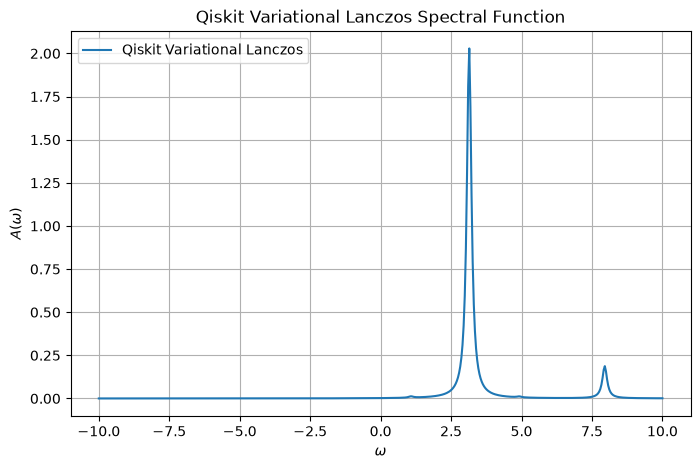

In [85]:
# ============================================================
# Combine Particle-Removal and Particle-Addition Green's Functions
# ============================================================

# Full Green's function
g_total_qiskit = g_minus_qiskit + g_plus_qiskit


# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

print("=" * 65)
print("FULL QISKIT GREEN'S FUNCTION")
print("=" * 65)

print("\nShape:")
print(g_total_qiskit.shape)

print("\nFinite values:")
print(np.isfinite(g_total_qiskit).all())

print("\nMaximum absolute GF value:")
print(np.max(np.abs(g_total_qiskit)))


# ------------------------------------------------------------
# Compute spectral function
# A(w) = -(1/pi) Im[G(w)]
# ------------------------------------------------------------

omega_real = w.real

spectral_qiskit = -(1.0 / np.pi) * np.imag(
    g_total_qiskit
)


# ------------------------------------------------------------
# Plot the spectral function
# ------------------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    omega_real,
    spectral_qiskit,
    label="Qiskit Variational Lanczos",
)

plt.xlabel(r"$\omega$")
plt.ylabel(r"$A(\omega)$")
plt.title(
    "Qiskit Variational Lanczos Spectral Function"
)

plt.legend()
plt.grid(True)

plt.show()

QULACS VARIATIONAL-LANCZOS RESULTS

Particle-removal coefficients
a_minus_qulacs = [ 2.6046696   3.15029288 -1.01252162]
b_minus_qulacs = [0.         1.94760818 0.90096078]

Particle-addition coefficients
a_plus_qulacs = [ 7.33017193 10.90212488  1.63150804]
b_plus_qulacs = [0.         5.89269195 3.30658725]

Green's function
Shape: (500,)
Finite values: True

Spectral function
Minimum: 0.00014583004236853233
Maximum: 1.7745695582813974

QISKIT VS QULACS COMPARISON
Maximum absolute error: 2.011609734661628
Mean absolute error: 0.06057010769447264
Root-mean-square error: 0.2385236971993908


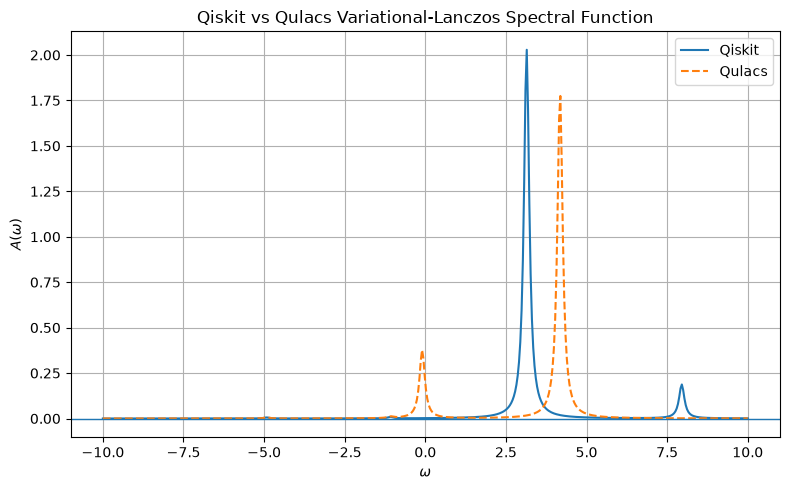

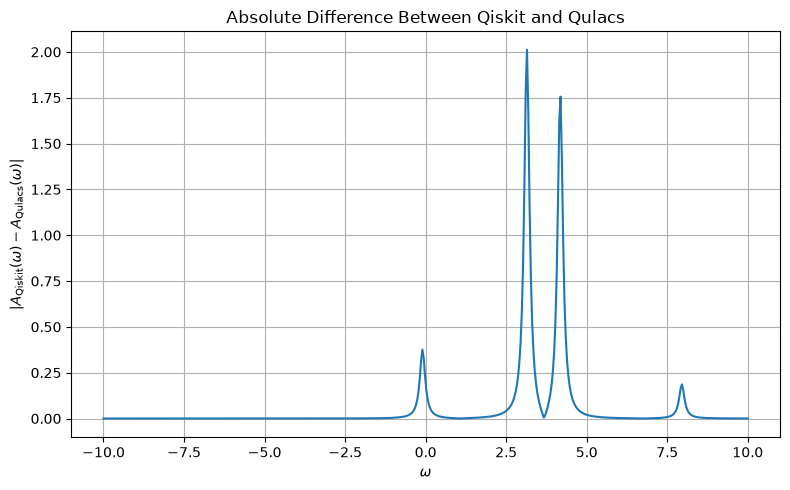

In [89]:
import numpy as np
import matplotlib.pyplot as plt
import vqe


# ============================================================
# 1. Use the same frequency grid as the Qiskit calculation
# ============================================================

eta = 0.1

w = np.linspace(
    -10.0,
    10.0,
    500,
    dtype=np.complex128,
) + 1j * eta

omega_real = w.real


# ============================================================
# 2. Qulacs particle-removal Green's function
# ============================================================

g_minus_raw_qulacs = np.zeros_like(
    w,
    dtype=np.complex128,
)

minus_lanczos_kwargs_qulacs = {
    "niter": 2,
    "u": qulacs_phi_minus,
    "h": qulacs_ham,
    "h2": qulacs_H2,
    "charge_sec": charge_minus,
    "spin_sec": spin_minus,
    "n_layers": vqe_depth,
    "up_qubit_indices": up_qubit_indices,
    "down_qubit_indices": down_qubit_indices,
    "connected_graphs": connected_graphs,
    "conv_tol": 1e-6,
    "optimizer": "COBYLA",
    "maxiter": 10000,
    "gf_gtol": 5e-5,
}

np.random.seed(1)

(
    a_minus_qulacs,
    b_minus_qulacs,
    minus_results_qulacs,
    g_minus_raw_qulacs,
) = vqe.vqe_gf_pm(
    g_vqe=g_minus_raw_qulacs,
    phi_norm=qulacs_phi_minus_norm,
    w=-w,
    **minus_lanczos_kwargs_qulacs,
)

# Apply the removal-branch sign
g_minus_qulacs = -g_minus_raw_qulacs


# ============================================================
# 3. Qulacs particle-addition Green's function
# ============================================================

g_plus_qulacs = np.zeros_like(
    w,
    dtype=np.complex128,
)

plus_lanczos_kwargs_qulacs = {
    "niter": 2,
    "u": qulacs_phi_plus,
    "h": qulacs_ham,
    "h2": qulacs_H2,
    "charge_sec": charge_plus,
    "spin_sec": spin_plus,
    "n_layers": vqe_depth,
    "up_qubit_indices": up_qubit_indices,
    "down_qubit_indices": down_qubit_indices,
    "connected_graphs": connected_graphs,
    "conv_tol": 1e-6,
    "optimizer": "COBYLA",
    "maxiter": 10000,
    "gf_gtol": 5e-5,
}

np.random.seed(1)

(
    a_plus_qulacs,
    b_plus_qulacs,
    plus_results_qulacs,
    g_plus_qulacs,
) = vqe.vqe_gf_pm(
    g_vqe=g_plus_qulacs,
    phi_norm=qulacs_phi_plus_norm,
    w=w,
    **plus_lanczos_kwargs_qulacs,
)


# ============================================================
# 4. Construct the total Qulacs Green's function
# ============================================================

g_total_qulacs = (
    g_plus_qulacs
    + g_minus_qulacs
)

spectral_qulacs = (
    -(1.0 / np.pi)
    * np.imag(g_total_qulacs)
)


# ============================================================
# 5. Confirm the calculation worked
# ============================================================

print("=" * 65)
print("QULACS VARIATIONAL-LANCZOS RESULTS")
print("=" * 65)

print("\nParticle-removal coefficients")
print("a_minus_qulacs =", np.real_if_close(a_minus_qulacs))
print("b_minus_qulacs =", np.real_if_close(b_minus_qulacs))

print("\nParticle-addition coefficients")
print("a_plus_qulacs =", np.real_if_close(a_plus_qulacs))
print("b_plus_qulacs =", np.real_if_close(b_plus_qulacs))

print("\nGreen's function")
print("Shape:", g_total_qulacs.shape)
print("Finite values:", np.isfinite(g_total_qulacs).all())

print("\nSpectral function")
print("Minimum:", np.min(spectral_qulacs))
print("Maximum:", np.max(spectral_qulacs))


# ============================================================
# 6. Compare Qiskit and Qulacs
# ============================================================

if spectral_qiskit.shape != spectral_qulacs.shape:
    raise ValueError(
        "The Qiskit and Qulacs spectra have different shapes."
    )

spectral_difference = (
    spectral_qiskit
    - spectral_qulacs
)

absolute_difference = np.abs(
    spectral_difference
)

max_absolute_error = np.max(
    absolute_difference
)

mean_absolute_error = np.mean(
    absolute_difference
)

rmse = np.sqrt(
    np.mean(
        spectral_difference**2
    )
)

print("\n" + "=" * 65)
print("QISKIT VS QULACS COMPARISON")
print("=" * 65)

print("Maximum absolute error:", max_absolute_error)
print("Mean absolute error:", mean_absolute_error)
print("Root-mean-square error:", rmse)


# ============================================================
# 7. Overlay the two spectral functions
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    omega_real,
    spectral_qiskit,
    label="Qiskit",
)

plt.plot(
    omega_real,
    spectral_qulacs,
    linestyle="--",
    label="Qulacs",
)

plt.axhline(
    0.0,
    linewidth=1.0,
)

plt.xlabel(r"$\omega$")
plt.ylabel(r"$A(\omega)$")
plt.title(
    "Qiskit vs Qulacs Variational-Lanczos Spectral Function"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 8. Plot the absolute difference
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    omega_real,
    absolute_difference,
)

plt.xlabel(r"$\omega$")
plt.ylabel(
    r"$|A_{\mathrm{Qiskit}}(\omega)"
    r"-A_{\mathrm{Qulacs}}(\omega)|$"
)

plt.title(
    "Absolute Difference Between Qiskit and Qulacs"
)

plt.grid(True)
plt.tight_layout()
plt.show()

In [90]:
print("Qiskit removal a:", np.real_if_close(a_minus_qiskit))
print("Qulacs removal a:", np.real_if_close(a_minus_qulacs))

print("Qiskit removal b:", np.real_if_close(b_minus_qiskit))
print("Qulacs removal b:", np.real_if_close(b_minus_qulacs))

print("Qiskit addition a:", np.real_if_close(a_plus_qiskit))
print("Qulacs addition a:", np.real_if_close(a_plus_qulacs))

print("Qiskit addition b:", np.real_if_close(b_plus_qiskit))
print("Qulacs addition b:", np.real_if_close(b_plus_qulacs))

Qiskit removal a: [ 2.6046696   3.13061805 -0.99279943]
Qulacs removal a: [ 2.6046696   3.15029288 -1.01252162]
Qiskit removal b: [0.         1.94760818 0.94522027]
Qulacs removal b: [0.         1.94760818 0.90096078]
Qiskit addition a: [ 7.33017193 11.94602403  7.99378138]
Qulacs addition a: [ 7.33017193 10.90212488  1.63150804]
Qiskit addition b: [0.         5.89269195 1.58009015]
Qulacs addition b: [0.         5.89269195 3.30658725]


In [91]:
print("=" * 65)
print("REMOVAL OPTIMIZATION RESULTS")
print("=" * 65)

for i in sorted(minus_results_qiskit):
    q_result = minus_results_qiskit[i]
    ql_result = minus_results_qulacs[i]

    print(f"\nIteration {i}")

    print("Qiskit:")
    print("  success =", q_result["success"])
    print("  cost    =", q_result["fun"])
    print("  message =", q_result["message"])

    print("Qulacs:")
    print("  success =", ql_result["success"])
    print("  cost    =", ql_result["fun"])
    print("  message =", ql_result["message"])


print("\n" + "=" * 65)
print("ADDITION OPTIMIZATION RESULTS")
print("=" * 65)

for i in sorted(plus_results_qiskit):
    q_result = plus_results_qiskit[i]
    ql_result = plus_results_qulacs[i]

    print(f"\nIteration {i}")

    print("Qiskit:")
    print("  success =", q_result["success"])
    print("  cost    =", q_result["fun"])
    print("  message =", q_result["message"])

    print("Qulacs:")
    print("  success =", ql_result["success"])
    print("  cost    =", ql_result["fun"])
    print("  message =", ql_result["message"])

REMOVAL OPTIMIZATION RESULTS

Iteration 1
Qiskit:
  success = False
  cost    = 1.5324461584387333e-06
  message = Return from COBYLA because the objective function has been evaluated MAXFUN times.
Qulacs:
  success = False
  cost    = 1.404265650730136e-06
  message = Return from COBYLA because the objective function has been evaluated MAXFUN times.

Iteration 2
Qiskit:
  success = True
  cost    = 4.747576301461786e-06
  message = Return from COBYLA because the trust region radius reaches its lower bound.
Qulacs:
  success = True
  cost    = 4.7906863464805234e-06
  message = Return from COBYLA because the trust region radius reaches its lower bound.

ADDITION OPTIMIZATION RESULTS

Iteration 1
Qiskit:
  success = False
  cost    = 0.0053954824444913405
  message = Return from COBYLA because the objective function has been evaluated MAXFUN times.
Qulacs:
  success = False
  cost    = 0.0011787193638446805
  message = Return from COBYLA because the objective function has been evaluated

In [92]:
import numpy as np

niter = 2

n_edges = connected_graphs["graph_full"].number_of_edges()

n_params = vqe_depth * (
    n_edges + n_qubits
)

rng = np.random.default_rng(1)

shared_initial_thetas = [
    rng.uniform(
        low=0.0,
        high=2.0 * np.pi,
        size=n_params,
    )
    for _ in range(niter)
]

print("Number of Lanczos starting vectors:", len(shared_initial_thetas))
print("Parameters per vector:", shared_initial_thetas[0].size)

Number of Lanczos starting vectors: 2
Parameters per vector: 11


In [ ]:
import importlib
import qiskit_port.qiskit_vqe as qv

importlib.reload(qv)


In [99]:
print("n_qubits =", n_qubits)
print("graph_full nodes =", list(connected_graphs["graph_full"].nodes()))
print("graph_full edges =", list(connected_graphs["graph_full"].edges()))

bad_edges = [
    edge
    for edge in connected_graphs["graph_full"].edges()
    if edge[0] >= n_qubits or edge[1] >= n_qubits
]

print("\nEdges outside the valid qubit range:")
print(bad_edges)

n_qubits = 4
graph_full nodes = [3, 0, 4, 1, 5, 2]
graph_full edges = [(3, 4), (3, 0), (0, 1), (4, 5), (4, 1), (1, 2), (5, 2)]

Edges outside the valid qubit range:
[(3, 4), (4, 5), (4, 1), (5, 2)]


In [100]:
import numpy as np
import networkx as nx
from qiskit.quantum_info import Statevector

# ============================================================
# CREATE A 4-QUBIT VERSION OF THE CURRENT GRAPH
# ============================================================

valid_qubits = set(range(n_qubits))

graph_4q = nx.Graph()

graph_4q.add_nodes_from(range(n_qubits))

graph_4q.add_edges_from([
    (a, b)
    for a, b in connected_graphs["graph_full"].edges()
    if a in valid_qubits and b in valid_qubits
])

# Make a copy of the graph dictionary
connected_graphs_4q = connected_graphs.copy()

# Replace graph_full with the valid 4-qubit graph
connected_graphs_4q["graph_full"] = graph_4q


print("n_qubits =", n_qubits)
print("4-qubit graph nodes =", list(graph_4q.nodes()))
print("4-qubit graph edges =", list(graph_4q.edges()))


# ============================================================
# CREATE FIXED PARAMETERS
# ============================================================

n_edges = graph_4q.number_of_edges()

n_params = vqe_depth * (
    n_edges + n_qubits
)

np.random.seed(123)

theta_test = np.random.uniform(
    0.0,
    2.0 * np.pi,
    size=n_params,
)

print("\nNumber of parameters:", n_params)


# ============================================================
# BUILD QISKIT ANSATZ
# ============================================================

qiskit_test_circuit = qv.all_symmetry_ansatzae_qiskit(
    theta=theta_test,
    n_qubits=n_qubits,
    n_layers=vqe_depth,
    initial_occupations_indices=initial_occupations_indices,
    connected_graphs=connected_graphs_4q,
    compilation="generic",
)

qiskit_test_state = Statevector.from_instruction(
    qiskit_test_circuit
).data


print("\nQiskit circuit successfully created.")
print("Statevector dimension:", len(qiskit_test_state))
print("Statevector norm:", np.linalg.norm(qiskit_test_state))

n_qubits = 4
4-qubit graph nodes = [0, 1, 2, 3]
4-qubit graph edges = [(0, 3), (0, 1), (1, 2)]

Number of parameters: 7


CircuitError: 'Index 4 out of range for size 4.'

In [101]:
import numpy as np
import networkx as nx
from qiskit.quantum_info import Statevector

# ============================================================
# BUILD A FULLY FILTERED 4-QUBIT connected_graphs DICTIONARY
# ============================================================

valid_qubits = set(range(n_qubits))

connected_graphs_4q = {}

for key, graph in connected_graphs.items():

    if isinstance(graph, nx.Graph):

        new_graph = nx.Graph()
        new_graph.add_nodes_from(range(n_qubits))

        new_graph.add_edges_from([
            (a, b)
            for a, b in graph.edges()
            if a in valid_qubits and b in valid_qubits
        ])

        connected_graphs_4q[key] = new_graph

    else:
        connected_graphs_4q[key] = graph


# ------------------------------------------------------------
# Check every graph
# ------------------------------------------------------------

print("n_qubits =", n_qubits)

for key, graph in connected_graphs_4q.items():
    if isinstance(graph, nx.Graph):
        print(f"\n{key}")
        print("nodes:", list(graph.nodes()))
        print("edges:", list(graph.edges()))


# ============================================================
# CREATE FIXED PARAMETERS
# ============================================================

n_edges = connected_graphs_4q["graph_full"].number_of_edges()

n_params = vqe_depth * (
    n_edges + n_qubits
)

np.random.seed(123)

theta_test = np.random.uniform(
    0.0,
    2.0 * np.pi,
    size=n_params,
)

print("\nNumber of parameters:", n_params)


# ============================================================
# BUILD QISKIT ANSATZ
# ============================================================

qiskit_test_circuit = qv.all_symmetry_ansatzae_qiskit(
    theta=theta_test,
    n_qubits=n_qubits,
    n_layers=vqe_depth,
    initial_occupations_indices=initial_occupations_indices,
    connected_graphs=connected_graphs_4q,
    compilation="generic",
)

qiskit_test_state = Statevector.from_instruction(
    qiskit_test_circuit
).data


# ============================================================
# RESULTS
# ============================================================

print("\nQiskit circuit successfully created.")
print("Statevector dimension:", len(qiskit_test_state))
print("Statevector norm:", np.linalg.norm(qiskit_test_state))

n_qubits = 4

graph_full
nodes: [0, 1, 2, 3]
edges: [(0, 3), (0, 1), (1, 2)]

graph_up
nodes: [0, 1, 2, 3]
edges: [(0, 1), (1, 2)]

graph_down
nodes: [0, 1, 2, 3]
edges: []

graph_stitch
nodes: [0, 1, 2, 3]
edges: [(0, 3)]

Number of parameters: 7

Qiskit circuit successfully created.
Statevector dimension: 16
Statevector norm: 0.9999999999999999


In [104]:
import inspect
import vqe
import qiskit_port.qiskit_vqe as qv

print("=" * 70)
print("QULACS LANCZOS COST FUNCTION")
print("=" * 70)

print(inspect.signature(vqe.lanczos_cost_function))

print("\nSOURCE:\n")
print(inspect.getsource(vqe.lanczos_cost_function))

print("\n" + "=" * 70)
print("QISKIT LANCZOS COST FUNCTION")
print("=" * 70)

print(inspect.signature(qv.lanczos_cost_function_qiskit))

QULACS LANCZOS COST FUNCTION
(params: numpy.ndarray[typing.Any, numpy.dtype[+_ScalarType_co]], h: qulacs_core.GeneralQuantumOperator, ut: list[qulacs_core.QuantumState], b: list[numpy.complex128], i: int, n_layers: int, initial_occupations_indices: list[int], connected_graphs: dict, compilation: str) -> float

SOURCE:

def lanczos_cost_function(
    params: NDArray,
    h: GeneralQuantumOperator,
    ut: list[QuantumState],
    b: list[np.complex128],
    i: int,
    n_layers: int,
    initial_occupations_indices: list[int],
    connected_graphs: dict,
    compilation: str,
) -> float:
    """
    Given specified parameters, construct a variational ansatz and return the value of the cost function with e_n contributions.
    :param params: VQE angles
    :param h: Qulacs Hamiltonian
    :param ut: List of qulacs Krylov vectors.
    :param b: Array of Krylov b coefficients.
    :param i: Lanczos iteration index - always starts at 1.
    :param n_layers: Number of layers of the ansatz.
  

In [106]:
import numpy as np
import anderson_impurity_model as aim

# Create the original Qulacs emulator
symm_qulacs = aim.SymmQulacsVqeEmulator(qulacs_ham)

# Give it plenty of angles so it cannot run out
theta_big = np.zeros(100)

qc_test = symm_qulacs.all_symmetry_ansatzae(
    theta=theta_big,
    n_layers=vqe_depth,
    initial_occupations_indices=initial_occupations_indices,
    connected_graphs=connected_graphs_4q,
    compilation="generic",
)

print("Qulacs Hamiltonian qubits:", qulacs_ham.get_qubit_count())
print("Qiskit n_qubits:", n_qubits)

print("\nCurrent graph:")
for name, graph in connected_graphs_4q.items():
    if hasattr(graph, "edges"):
        print(name, list(graph.edges()))

# Now inspect the original function so we can see exactly
# how k is incremented.
import inspect

print("\nORIGINAL QULACS ANSATZ SOURCE:\n")
print(
    inspect.getsource(
        aim.SymmQulacsVqeEmulator.all_symmetry_ansatzae
    )
)

Qulacs Hamiltonian qubits: 6
Qiskit n_qubits: 4

Current graph:
graph_full [(0, 3), (0, 1), (1, 2)]
graph_up [(0, 1), (1, 2)]
graph_down []
graph_stitch [(0, 3)]

ORIGINAL QULACS ANSATZ SOURCE:

    def all_symmetry_ansatzae(self, theta, n_layers, initial_occupations_indices,
                              connected_graphs: dict[str, nx.Graph],
                              compilation="generic"):
        n_qubits = self.hamiltonian.get_qubit_count()
        qc = ParametricQuantumCircuit(n_qubits)
        graph_up, graph_down, graph_stitch = itemgetter("graph_up", "graph_down", "graph_stitch")(connected_graphs)
        if compilation == "generic":
            # Create spin-delineated interaction graphs and reference mappings
            # Instantiates which charge/spin sector we're in
            for inds in initial_occupations_indices:
                qc.add_X_gate(inds)

            k = 0  # This index keeps track of theta parameter angles
            # Block below iterates through re

In [107]:
print("Hmat shape:", Hmat.shape)
print("H2mat shape:", H2mat.shape)

print("qiskit_phi_plus_array length:", len(qiskit_phi_plus_array))
print("qiskit_phi_minus_array length:", len(qiskit_phi_minus_array))

print("qulacs_phi_plus qubits:", qulacs_phi_plus.get_qubit_count())
print("qulacs_phi_minus qubits:", qulacs_phi_minus.get_qubit_count())

print("up_qubit_indices:", up_qubit_indices)
print("down_qubit_indices:", down_qubit_indices)

print("\nOriginal connected graphs:")
for name, graph in connected_graphs.items():
    if hasattr(graph, "edges"):
        print(name, "nodes =", list(graph.nodes()))
        print(name, "edges =", list(graph.edges()))

Hmat shape: (64, 64)
H2mat shape: (64, 64)
qiskit_phi_plus_array length: 64
qiskit_phi_minus_array length: 64
qulacs_phi_plus qubits: 6
qulacs_phi_minus qubits: 6
up_qubit_indices: [0, 1, 2]
down_qubit_indices: [3, 4, 5]

Original connected graphs:
graph_full nodes = [3, 0, 4, 1, 5, 2]
graph_full edges = [(3, 4), (3, 0), (0, 1), (4, 5), (4, 1), (1, 2), (5, 2)]
graph_up nodes = [0, 1, 2]
graph_up edges = [(0, 1), (1, 2)]
graph_down nodes = [3, 4, 5]
graph_down edges = [(3, 4), (4, 5)]
graph_stitch nodes = [3, 0, 4, 1, 5, 2]
graph_stitch edges = [(3, 0), (4, 1), (5, 2)]


In [108]:
import numpy as np

# ============================================================
# CORRECT 6-QUBIT PARTICLE-ADDITION COST TEST
# ============================================================

n_qubits_test = 6
i_test = 1

# Correct number of parameters
n_edges = connected_graphs["graph_full"].number_of_edges()

n_params = vqe_depth * (
    n_edges + n_qubits_test
)

print("Qubits:", n_qubits_test)
print("Parameters:", n_params)

# Same theta for BOTH implementations
np.random.seed(123)

theta_test = np.random.uniform(
    0.0,
    2.0 * np.pi,
    size=n_params,
)

# Use exactly the same b coefficients for both tests
b_common = np.asarray(
    b_plus_qulacs,
    dtype=np.complex128,
)

# ============================================================
# QULACS COST
# ============================================================

cost_qulacs = vqe.lanczos_cost_function(
    theta_test,
    qulacs_ham,
    [qulacs_phi_plus],
    b_common,
    i_test,
    vqe_depth,
    initial_occupations_indices,
    connected_graphs,
    "generic",
)

# ============================================================
# QISKIT COST
# ============================================================

cost_qiskit = qv.lanczos_cost_function_qiskit(
    theta_test,
    Hmat,
    [qiskit_phi_plus_array],
    b_common,
    i_test,
    vqe_depth,
    initial_occupations_indices,
    connected_graphs,
    n_qubits_test,
    "generic",
)

# ============================================================
# COMPARE
# ============================================================

difference = abs(
    cost_qiskit - cost_qulacs
)

print("\n" + "=" * 60)
print("PARTICLE-ADDITION COST COMPARISON")
print("=" * 60)

print("Qulacs cost =", cost_qulacs)
print("Qiskit cost =", cost_qiskit)
print("Absolute difference =", difference)

if np.isclose(
    cost_qiskit,
    cost_qulacs,
    atol=1e-10,
):
    print("\nPASS: Cost functions match.")
else:
    print("\nFAIL: Cost functions do NOT match.")

Qubits: 6
Parameters: 13

PARTICLE-ADDITION COST COMPARISON
Qulacs cost = 34.72381836516358
Qiskit cost = 34.72381836516358
Absolute difference = 0.0

PASS: Cost functions match.


In [109]:
import numpy as np
from scipy.optimize import minimize

# ============================================================
# SAME-START OPTIMIZER TEST: PARTICLE-ADDITION, ITERATION 1
# ============================================================

i_test = 1
n_qubits_test = 6

n_edges = connected_graphs["graph_full"].number_of_edges()
n_params = vqe_depth * (n_edges + n_qubits_test)

# Exact same starting point for both optimizers
np.random.seed(123)

theta_0 = np.random.uniform(
    0.0,
    2.0 * np.pi,
    size=n_params,
)

print("Number of parameters:", n_params)

# Use the same b array for both
b_common = np.asarray(
    b_plus_qulacs,
    dtype=np.complex128,
)

# ============================================================
# QULACS OPTIMIZATION
# ============================================================

result_qulacs = minimize(
    vqe.lanczos_cost_function,
    theta_0.copy(),
    args=(
        qulacs_ham,
        [qulacs_phi_plus],
        b_common,
        i_test,
        vqe_depth,
        initial_occupations_indices,
        connected_graphs,
        "generic",
    ),
    method="COBYLA",
    options={
        "maxiter": 10000,
        "tol": 5e-5,
    },
)

# ============================================================
# QISKIT OPTIMIZATION
# ============================================================

result_qiskit = minimize(
    qv.lanczos_cost_function_qiskit,
    theta_0.copy(),
    args=(
        Hmat,
        [qiskit_phi_plus_array],
        b_common,
        i_test,
        vqe_depth,
        initial_occupations_indices,
        connected_graphs,
        n_qubits_test,
        "generic",
    ),
    method="COBYLA",
    options={
        "maxiter": 10000,
        "tol": 5e-5,
    },
)

# ============================================================
# COMPARE
# ============================================================

print("\n" + "=" * 60)
print("SAME-START OPTIMIZATION COMPARISON")
print("=" * 60)

print("\nQulacs")
print("success =", result_qulacs.success)
print("cost    =", result_qulacs.fun)
print("message =", result_qulacs.message)

print("\nQiskit")
print("success =", result_qiskit.success)
print("cost    =", result_qiskit.fun)
print("message =", result_qiskit.message)

print("\nCost difference:")
print(abs(result_qiskit.fun - result_qulacs.fun))

print("\nMaximum parameter difference:")
print(
    np.max(
        np.abs(
            result_qiskit.x - result_qulacs.x
        )
    )
)

Number of parameters: 13

SAME-START OPTIMIZATION COMPARISON

Qulacs
success = True
cost    = 34.72381836516358
message = Return from COBYLA because the trust region radius reaches its lower bound.

Qiskit
success = True
cost    = 34.72381836516358
message = Return from COBYLA because the trust region radius reaches its lower bound.

Cost difference:
0.0

Maximum parameter difference:
0.0


In [110]:
import numpy as np

seed = 123

# ============================================================
# QISKIT FULL ADDITION BRANCH
# ============================================================

np.random.seed(seed)

(
    a_plus_qiskit_test,
    b_plus_qiskit_test,
    plus_results_qiskit_test,
    g_plus_qiskit_test,
    plus_krylov_qiskit_test,
) = qv.vqe_gf_pm_qiskit(
    g_vqe=np.zeros_like(w, dtype=np.complex128),
    phi_norm=qiskit_phi_plus_norm,
    w=w,
    niter=2,
    u=qiskit_phi_plus_array,
    Hmat=Hmat,
    H2mat=H2mat,
    charge_sec=charge_plus,
    spin_sec=spin_plus,
    n_layers=vqe_depth,
    up_qubit_indices=up_qubit_indices,
    down_qubit_indices=down_qubit_indices,
    connected_graphs=connected_graphs,
    conv_tol=1e-6,
    optimizer="COBYLA",
    maxiter=10000,
    gf_gtol=5e-5,
)

# ============================================================
# QULACS FULL ADDITION BRANCH
# ============================================================

np.random.seed(seed)

(
    a_plus_qulacs_test,
    b_plus_qulacs_test,
    plus_results_qulacs_test,
    g_plus_qulacs_test,
) = vqe.vqe_gf_pm(
    g_vqe=np.zeros_like(w, dtype=np.complex128),
    phi_norm=qulacs_phi_plus_norm,
    w=w,
    niter=2,
    u=qulacs_phi_plus,
    h=qulacs_ham,
    h2=qulacs_H2,
    charge_sec=charge_plus,
    spin_sec=spin_plus,
    n_layers=vqe_depth,
    up_qubit_indices=up_qubit_indices,
    down_qubit_indices=down_qubit_indices,
    connected_graphs=connected_graphs,
    conv_tol=1e-6,
    optimizer="COBYLA",
    maxiter=10000,
    gf_gtol=5e-5,
)

# ============================================================
# COMPARE
# ============================================================

print("=" * 60)
print("FULL ADDITION BRANCH — SAME SEED")
print("=" * 60)

print("\nQiskit a:")
print(np.real_if_close(a_plus_qiskit_test))

print("\nQulacs a:")
print(np.real_if_close(a_plus_qulacs_test))

print("\nQiskit b:")
print(np.real_if_close(b_plus_qiskit_test))

print("\nQulacs b:")
print(np.real_if_close(b_plus_qulacs_test))

print("\nMaximum a difference:")
print(
    np.max(
        np.abs(
            np.asarray(a_plus_qiskit_test)
            - np.asarray(a_plus_qulacs_test)
        )
    )
)

print("\nMaximum b difference:")
print(
    np.max(
        np.abs(
            np.asarray(b_plus_qiskit_test)
            - np.asarray(b_plus_qulacs_test)
        )
    )
)

FULL ADDITION BRANCH — SAME SEED

Qiskit a:
[ 7.33017193 11.98511992  0.62764048]

Qulacs a:
[ 7.33017193 11.78957543 -1.04809394]

Qiskit b:
[0.         5.89269195 1.48253178]

Qulacs b:
[0.         5.89269195 1.0078679 ]

Maximum a difference:
1.6757344188814138

Maximum b difference:
0.47466388119330616


In [111]:
import numpy as np

seed = 123
recorded_qulacs_thetas = []

original_uniform = np.random.uniform

def recording_uniform(*args, **kwargs):
    values = original_uniform(*args, **kwargs)

    # Record only 13-parameter Lanczos guesses
    arr = np.asarray(values)

    if arr.size == 13:
        recorded_qulacs_thetas.append(arr.copy())

    return values

np.random.seed(seed)
np.random.uniform = recording_uniform

try:
    (
        a_test,
        b_test,
        results_test,
        g_test,
    ) = vqe.vqe_gf_pm(
        g_vqe=np.zeros_like(w, dtype=np.complex128),
        phi_norm=qulacs_phi_plus_norm,
        w=w,
        niter=2,
        u=qulacs_phi_plus,
        h=qulacs_ham,
        h2=qulacs_H2,
        charge_sec=charge_plus,
        spin_sec=spin_plus,
        n_layers=vqe_depth,
        up_qubit_indices=up_qubit_indices,
        down_qubit_indices=down_qubit_indices,
        connected_graphs=connected_graphs,
        conv_tol=1e-6,
        optimizer="COBYLA",
        maxiter=10000,
        gf_gtol=5e-5,
    )

finally:
    np.random.uniform = original_uniform


print("\nQULACS theta_0 vectors")

for i, theta in enumerate(recorded_qulacs_thetas, start=1):
    print(f"\nIteration {i}:")
    print(theta)


QULACS theta_0 vectors

Iteration 1:
[4.37604495 1.79786647 1.42534972 3.46401286 4.52055686 2.65845629
 6.1623232  4.30291215 3.02178426 2.46374703 2.15625107 4.58075441
 2.75563068]

Iteration 2:
[0.37496728 2.50098582 4.63696189 1.14662936 1.1023959  3.33983578
 3.34157128 3.98605878 5.33713737 4.55188705 3.83917394 4.53924565
 2.0292107 ]

Iteration 3:
[2.27318517 1.43422018 1.84545978 3.96453991 0.57871241 2.72502484
 2.70719058 3.10191495 2.67557062 1.96199513 2.67884427 5.61332966
 5.93233235]

Iteration 4:
[3.15313283 3.92041202 0.7264518  1.99356348 2.60642996 5.44318097
 1.57365747 3.03499379 6.19245476 3.26402127 3.85092988 0.75793226
 5.19205238]

Iteration 5:
[3.78913854 3.42476329 2.15364868 1.91084727 2.62022783 4.28073896
 5.50065757 3.20707813 4.20542253 3.68154794 3.9263845  4.23919633
 5.29259363]

Iteration 6:
[0.52272953 4.79836081 1.53100098 1.22033885 3.59685314 0.60137948
 5.56267251 3.94112153 4.54535903 0.10134279 3.73492565 3.49838454
 0.9987729 ]

Iteration

In [112]:
import importlib
import qiskit_port.qiskit_vqe as qv

importlib.reload(qv)

<module 'qiskit_port.qiskit_vqe' from '/Users/aporter2/Downloads/nlr_qc/qcaob-aim/qiskit_port/qiskit_vqe.py'>

In [113]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
import qiskit_port.qiskit_vqe as qv

# Reload edited Qiskit code
importlib.reload(qv)

# ============================================================
# PARTICLE REMOVAL
# ============================================================

(
    a_minus_qiskit_new,
    b_minus_qiskit_new,
    minus_results_qiskit_new,
    g_minus_raw_qiskit_new,
    minus_krylov_qiskit_new,
) = qv.vqe_gf_pm_qiskit(
    g_vqe=np.zeros_like(w, dtype=np.complex128),
    phi_norm=qiskit_phi_minus_norm,
    w=-w,
    niter=2,
    u=qiskit_phi_minus_array,
    Hmat=Hmat,
    H2mat=H2mat,
    charge_sec=charge_minus,
    spin_sec=spin_minus,
    n_layers=vqe_depth,
    up_qubit_indices=up_qubit_indices,
    down_qubit_indices=down_qubit_indices,
    connected_graphs=connected_graphs,
    conv_tol=1e-6,
    optimizer="COBYLA",
    maxiter=10000,
    gf_gtol=5e-5,
)

g_minus_qiskit_new = -g_minus_raw_qiskit_new


# ============================================================
# PARTICLE ADDITION
# ============================================================

(
    a_plus_qiskit_new,
    b_plus_qiskit_new,
    plus_results_qiskit_new,
    g_plus_qiskit_new,
    plus_krylov_qiskit_new,
) = qv.vqe_gf_pm_qiskit(
    g_vqe=np.zeros_like(w, dtype=np.complex128),
    phi_norm=qiskit_phi_plus_norm,
    w=w,
    niter=2,
    u=qiskit_phi_plus_array,
    Hmat=Hmat,
    H2mat=H2mat,
    charge_sec=charge_plus,
    spin_sec=spin_plus,
    n_layers=vqe_depth,
    up_qubit_indices=up_qubit_indices,
    down_qubit_indices=down_qubit_indices,
    connected_graphs=connected_graphs,
    conv_tol=1e-6,
    optimizer="COBYLA",
    maxiter=10000,
    gf_gtol=5e-5,
)


# ============================================================
# TOTAL QISKIT GREEN'S FUNCTION
# ============================================================

g_total_qiskit_new = (
    g_minus_qiskit_new
    + g_plus_qiskit_new
)

spectral_qiskit_new = (
    -(1.0 / np.pi)
    * np.imag(g_total_qiskit_new)
)


# ============================================================
# PRINT NEW LANCZOS COEFFICIENTS
# ============================================================

print("=" * 60)
print("NEW QISKIT LANCZOS COEFFICIENTS")
print("=" * 60)

print("\nRemoval a:")
print(np.real_if_close(a_minus_qiskit_new))

print("\nRemoval b:")
print(np.real_if_close(b_minus_qiskit_new))

print("\nAddition a:")
print(np.real_if_close(a_plus_qiskit_new))

print("\nAddition b:")
print(np.real_if_close(b_plus_qiskit_new))


# ============================================================
# QISKIT VS ORIGINAL QULACS
# ============================================================

print("\n" + "=" * 60)
print("QISKIT VS QULACS")
print("=" * 60)

print(
    "Maximum spectral difference:",
    np.max(
        np.abs(
            spectral_qiskit_new
            - spectral_qulacs
        )
    )
)

print(
    "Mean spectral difference:",
    np.mean(
        np.abs(
            spectral_qiskit_new
            - spectral_qulacs
        )
    )
)


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    omega_real,
    spectral_qiskit_new,
    label="Qiskit",
)

plt.plot(
    omega_real,
    spectral_qulacs,
    "--",
    label="Qulacs",
)

plt.xlabel(r"$\omega$")
plt.ylabel(r"$A(\omega)$")
plt.title("Spectral Function: Qiskit vs Qulacs")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

/Users/aporter2/Downloads/nlr_qc/qcaob-aim/qiskit_port/qiskit_vqe.py:538: OptimizeWarning: Unknown solver options: gtol, eps
  "eps": 1e-7,


ValueError: Negative b² encountered at iteration 2: -2.2149290253332694

In [118]:
# ------------------------------------------------------------
# Multiple random restarts for more stable Lanczos optimization
# ------------------------------------------------------------

n_restarts = 5

best_result = None

for restart in range(n_restarts):

    theta_0 = np.random.uniform(
        low=0.0,
        high=2.0 * np.pi,
        size=n_params,
    )

    result = minimize(
        lanczos_cost_function_qiskit,
        theta_0,
        args=opt_args,
        method=optimizer,
        tol=conv_tol,
        options={
            "maxiter": int(maxiter),
        },
    )

    if best_result is None or result.fun < best_result.fun:
        best_result = result

# Use the best optimization result
result = best_result

print(
    f"Lanczos iteration {i}: "
    f"best cost = {result.fun:.8e}"
)

NameError: name 'opt_args' is not defined

In [119]:
import importlib
import qiskit_port.qiskit_vqe as qv

importlib.reload(qv)

<module 'qiskit_port.qiskit_vqe' from '/Users/aporter2/Downloads/nlr_qc/qcaob-aim/qiskit_port/qiskit_vqe.py'>

In [120]:
(
    a_plus_qiskit_new,
    b_plus_qiskit_new,
    plus_results_qiskit_new,
    g_plus_qiskit_new,
    plus_krylov_qiskit_new,
) = qv.vqe_gf_pm_qiskit(
    g_vqe=np.zeros_like(w, dtype=np.complex128),
    phi_norm=qiskit_phi_plus_norm,
    w=w,
    niter=2,
    u=qiskit_phi_plus_array,
    Hmat=Hmat,
    H2mat=H2mat,
    charge_sec=charge_plus,
    spin_sec=spin_plus,
    n_layers=vqe_depth,
    up_qubit_indices=up_qubit_indices,
    down_qubit_indices=down_qubit_indices,
    connected_graphs=connected_graphs,
    conv_tol=1e-6,
    optimizer="COBYLA",
    maxiter=10000,
    gf_gtol=5e-5,
)


Lanczos iteration 1
b[1] = (5.892691945551164+0j)
Restart 1/5: cost = 7.31033077e-03, success = False
Restart 2/5: cost = 1.87341553e-03, success = False
Restart 3/5: cost = 9.52546240e-03, success = False
Restart 4/5: cost = 1.28979045e-03, success = False
Restart 5/5: cost = 8.02628879e-03, success = False
Selected best cost = 1.28979045e-03
a[1] = (10.92285950514372-2.0469737016526324e-16j)

Lanczos iteration 2
b[2] = (3.856504650173124+0j)
Restart 1/5: cost = 8.63709202e-03, success = False
Restart 2/5: cost = 8.22615373e-03, success = False
Restart 3/5: cost = 2.20755196e-02, success = False
Restart 4/5: cost = 1.20275167e-02, success = False
Restart 5/5: cost = 1.24645752e-02, success = False
Selected best cost = 8.22615373e-03
a[2] = (3.250994994511875-1.6653345369377348e-16j)


In [121]:
print("\nQiskit addition a:")
print(np.real_if_close(a_plus_qiskit_new))

print("\nQiskit addition b:")
print(np.real_if_close(b_plus_qiskit_new))

print("\nQulacs addition a:")
print(np.real_if_close(a_plus_qulacs))

print("\nQulacs addition b:")
print(np.real_if_close(b_plus_qulacs))



Qiskit addition a:
[ 7.33017193 10.92285951  3.25099499]

Qiskit addition b:
[0.         5.89269195 3.85650465]

Qulacs addition a:
[ 7.33017193 10.90212488  1.63150804]

Qulacs addition b:
[0.         5.89269195 3.30658725]


In [123]:
(
    a_plus_qiskit_new,
    b_plus_qiskit_new,
    plus_results_qiskit_new,
    g_plus_qiskit_new,
    plus_krylov_qiskit_new,
) = qv.vqe_gf_pm_qiskit(
    g_vqe=np.zeros_like(w, dtype=np.complex128),
    phi_norm=qiskit_phi_plus_norm,
    w=w,
    niter=2,
    u=qiskit_phi_plus_array,
    Hmat=Hmat,
    H2mat=H2mat,
    charge_sec=charge_plus,
    spin_sec=spin_plus,
    n_layers=vqe_depth,
    up_qubit_indices=up_qubit_indices,
    down_qubit_indices=down_qubit_indices,
    connected_graphs=connected_graphs,
    conv_tol=1e-6,
    optimizer="COBYLA",
    maxiter=30000,
    gf_gtol=5e-5,
)


Lanczos iteration 1
b[1] = (5.892691945551164+0j)
Restart 1/5: cost = 2.28124012e-03, success = False
Restart 2/5: cost = 9.89729115e-04, success = False
Restart 3/5: cost = 3.79996850e-03, success = False
Restart 4/5: cost = 9.19163700e-04, success = False
Restart 5/5: cost = 3.24028428e-03, success = False
Selected best cost = 9.19163700e-04
a[1] = (11.462564653557646+5.551115123125783e-17j)

Lanczos iteration 2
b[2] = (3.168021317728229+0j)
Restart 1/5: cost = 6.49218987e-05, success = False
Restart 2/5: cost = 1.84108268e-02, success = False
Restart 3/5: cost = 8.81734833e-04, success = False
Restart 4/5: cost = 1.40669386e-02, success = False
Restart 5/5: cost = 8.76862911e-04, success = False
Selected best cost = 6.49218987e-05
a[2] = (-0.3486189061764864+4.163336342344337e-17j)


In [124]:
print("Qiskit addition a:")
print(np.real_if_close(a_plus_qiskit_new))

print("\nQiskit addition b:")
print(np.real_if_close(b_plus_qiskit_new))

print("\nQulacs addition a:")
print(np.real_if_close(a_plus_qulacs))

print("\nQulacs addition b:")
print(np.real_if_close(b_plus_qulacs))

Qiskit addition a:
[ 7.33017193 11.46256465 -0.34861891]

Qiskit addition b:
[0.         5.89269195 3.16802132]

Qulacs addition a:
[ 7.33017193 10.90212488  1.63150804]

Qulacs addition b:
[0.         5.89269195 3.30658725]


In [126]:
import numpy as np
import vqe

# ============================================================
# CAPTURE EXACT QULACS LANCZOS STARTING PARAMETERS
# ============================================================

qulacs_theta_starts = []

# Save original minimize function used inside vqe.py
original_minimize = vqe.minimize


def recording_minimize(fun, x0, *args, **kwargs):
    # Record only Lanczos optimizations
    if fun is vqe.lanczos_cost_function:
        qulacs_theta_starts.append(
            np.asarray(x0, dtype=float).copy()
        )

    return original_minimize(
        fun,
        x0,
        *args,
        **kwargs,
    )


# Temporarily replace minimize inside vqe.py
vqe.minimize = recording_minimize

try:
    (
        a_plus_qulacs_capture,
        b_plus_qulacs_capture,
        plus_results_qulacs_capture,
        g_plus_qulacs_capture,
    ) = vqe.vqe_gf_pm(
        g_vqe=np.zeros_like(w, dtype=np.complex128),
        phi_norm=qulacs_phi_plus_norm,
        w=w,
        niter=2,
        u=qulacs_phi_plus,
        h=qulacs_ham,
        h2=qulacs_H2,
        charge_sec=charge_plus,
        spin_sec=spin_plus,
        n_layers=vqe_depth,
        up_qubit_indices=up_qubit_indices,
        down_qubit_indices=down_qubit_indices,
        connected_graphs=connected_graphs,
        conv_tol=1e-6,
        optimizer="COBYLA",
        maxiter=10000,
        gf_gtol=5e-5,
    )

finally:
    # Always restore original minimize
    vqe.minimize = original_minimize


# ============================================================
# SHOW EXACT STARTING VECTORS
# ============================================================

print("=" * 60)
print("EXACT QULACS LANCZOS STARTING THETAS")
print("=" * 60)

for i, theta in enumerate(qulacs_theta_starts, start=1):
    print(f"\nLanczos iteration {i}:")
    print(theta)

print("\nNumber captured:", len(qulacs_theta_starts))

/var/folders/ss/vwdh5_w12qn4rfhf27rxh6rc0000gr/T/ipykernel_89374/2050468858.py:21: OptimizeWarning: Unknown solver options: gtol, eps
  return original_minimize(


EXACT QULACS LANCZOS STARTING THETAS

Lanczos iteration 1:
[3.88779491 3.14991326 3.75184916 4.75046527 3.37457187 5.64074685
 5.95060054 5.75134199 4.74077855 1.54768051 2.42073189 1.75929158
 4.13220116]

Lanczos iteration 2:
[2.03714455 4.73998225 0.71319857 4.87176049 3.68133068 5.24890192
 2.70727157 3.92676747 3.48347416 6.13032337 4.7467856  3.4231626
 1.09347587]

Lanczos iteration 3:
[5.68071716 1.29331693 4.08434224 5.88402619 1.40479225 1.41951947
 5.35213606 5.2003099  2.20981734 1.66564911 0.80040538 6.20738561
 5.2486155 ]

Lanczos iteration 4:
[5.65104412 3.22754239 0.7187011  0.33037201 2.07710861 5.78260665
 5.95383226 5.28518844 0.99701046 2.6384551  1.54718989 1.29025069
 4.30288772]

Lanczos iteration 5:
[3.05432969 2.04146751 0.62966604 3.42284921 2.18042334 2.45732742
 1.95098396 2.43281922 3.49256877 0.08886815 5.32592315 5.79259333
 3.45908006]

Lanczos iteration 6:
[1.68402634 6.22185514 2.4076791  4.35836538 4.33509971 2.72884433
 1.25134761 6.07319733 0.40018

In [127]:
import inspect
import vqe

print(
    inspect.getsource(
        vqe.vqe_ideal_lanczos_iterations
    )
)

def vqe_ideal_lanczos_iterations(
    niter: int,
    u: QuantumState,
    h: GeneralQuantumOperator,
    h2: GeneralQuantumOperator,
    charge_sec: int,
    spin_sec: int,
    n_layers: int,
    up_qubit_indices: list[int],
    down_qubit_indices: list[int],
    connected_graphs: dict,
    conv_tol: float = 1e-6,
    optimizer: str = "COBYLA",
    maxiter: int = 1e6,
    gf_gtol: float = 5e-5,
) -> tuple[NDArray[np.complex128], NDArray[np.complex128], dict]:
    """
    Given parameters specified, run noiseless simulation of VQE returning the Krylov basis coefficients computed by the
    Lanczos iterations.
    :param niter: The total number of Lanczos iterations to perform given that there is no early termination.
    :param u: Initial Krylov vector.
    :param h: Hamiltonian qulacs quantum operator.
    :param h2: Hamiltonian squared qulacs quantum operator.
    :param charge_sec: The charge sector the ground state resides in as found by VQE.
    :param spin_sec: The spin sector th

In [128]:
import importlib
import qiskit_port.qiskit_vqe as qv

importlib.reload(qv)

<module 'qiskit_port.qiskit_vqe' from '/Users/aporter2/Downloads/nlr_qc/qcaob-aim/qiskit_port/qiskit_vqe.py'>

In [129]:
(
    a_plus_qiskit_new,
    b_plus_qiskit_new,
    plus_results_qiskit_new,
    g_plus_qiskit_new,
    plus_krylov_qiskit_new,
) = qv.vqe_gf_pm_qiskit(
    g_vqe=np.zeros_like(w, dtype=np.complex128),
    phi_norm=qiskit_phi_plus_norm,
    w=w,
    niter=2,
    u=qiskit_phi_plus_array,
    Hmat=Hmat,
    H2mat=H2mat,
    charge_sec=charge_plus,
    spin_sec=spin_plus,
    n_layers=vqe_depth,
    up_qubit_indices=up_qubit_indices,
    down_qubit_indices=down_qubit_indices,
    connected_graphs=connected_graphs,
    conv_tol=1e-6,
    optimizer="COBYLA",
    maxiter=10000,
    gf_gtol=5e-5,
)

print("Qiskit addition a:")
print(np.real_if_close(a_plus_qiskit_new))

print("\nQiskit addition b:")
print(np.real_if_close(b_plus_qiskit_new))

print("\nQulacs addition a:")
print(np.real_if_close(a_plus_qulacs))

print("\nQulacs addition b:")
print(np.real_if_close(b_plus_qulacs))

Qiskit addition a:
[7.33017193 9.89439954 3.11945576]

Qiskit addition b:
[0.         5.89269195 2.74707184]

Qulacs addition a:
[ 7.33017193 10.90212488  1.63150804]

Qulacs addition b:
[0.         5.89269195 3.30658725]


In [130]:
import importlib
import qiskit_port.qiskit_vqe as qv

importlib.reload(qv)

<module 'qiskit_port.qiskit_vqe' from '/Users/aporter2/Downloads/nlr_qc/qcaob-aim/qiskit_port/qiskit_vqe.py'>

In [131]:
(
    a_plus_qiskit_exact,
    b_plus_qiskit_exact,
    plus_results_qiskit_exact,
    g_plus_qiskit_exact,
    plus_krylov_qiskit_exact,
) = qv.vqe_gf_pm_qiskit(
    g_vqe=np.zeros_like(w, dtype=np.complex128),
    phi_norm=qiskit_phi_plus_norm,
    w=w,
    niter=2,
    u=qiskit_phi_plus_array,
    Hmat=Hmat,
    H2mat=H2mat,
    charge_sec=charge_plus,
    spin_sec=spin_plus,
    n_layers=vqe_depth,
    up_qubit_indices=up_qubit_indices,
    down_qubit_indices=down_qubit_indices,
    connected_graphs=connected_graphs,
    conv_tol=1e-6,
    optimizer="COBYLA",
    maxiter=10000,
    gf_gtol=5e-5,
    theta_attempts=qulacs_theta_starts,
)

print("Qiskit a:")
print(np.real_if_close(a_plus_qiskit_exact))

print("\nQulacs a:")
print(np.real_if_close(a_plus_qulacs_capture))

print("\nQiskit b:")
print(np.real_if_close(b_plus_qiskit_exact))

print("\nQulacs b:")
print(np.real_if_close(b_plus_qulacs_capture))

Qiskit a:
[7.33017193 9.28922061 4.61989425]

Qulacs a:
[ 7.33017193 11.01981062  0.58434636]

Qiskit b:
[0.         5.89269195 3.38251517]

Qulacs b:
[0.         5.89269195 3.92623426]


In [132]:
import importlib
import qiskit_port.qiskit_vqe as qv

importlib.reload(qv)

<module 'qiskit_port.qiskit_vqe' from '/Users/aporter2/Downloads/nlr_qc/qcaob-aim/qiskit_port/qiskit_vqe.py'>

In [133]:
(
    a_plus_qiskit_exact,
    b_plus_qiskit_exact,
    plus_results_qiskit_exact,
    g_plus_qiskit_exact,
    plus_krylov_qiskit_exact,
) = qv.vqe_gf_pm_qiskit(
    g_vqe=np.zeros_like(w, dtype=np.complex128),
    phi_norm=qiskit_phi_plus_norm,
    w=w,
    niter=2,
    u=qiskit_phi_plus_array,
    Hmat=Hmat,
    H2mat=H2mat,
    charge_sec=charge_plus,
    spin_sec=spin_plus,
    n_layers=vqe_depth,
    up_qubit_indices=up_qubit_indices,
    down_qubit_indices=down_qubit_indices,
    connected_graphs=connected_graphs,
    conv_tol=1e-6,
    optimizer="COBYLA",
    maxiter=10000,
    gf_gtol=5e-5,
    theta_attempts=qulacs_theta_starts,
)

print("Qiskit addition a:")
print(np.real_if_close(a_plus_qiskit_exact))

print("\nQulacs addition a:")
print(np.real_if_close(a_plus_qulacs_capture))

print("\nQiskit addition b:")
print(np.real_if_close(b_plus_qiskit_exact))

print("\nQulacs addition b:")
print(np.real_if_close(b_plus_qulacs_capture))

print("\nMaximum a difference:")
print(
    np.max(
        np.abs(
            np.asarray(a_plus_qiskit_exact)
            - np.asarray(a_plus_qulacs_capture)
        )
    )
)

print("\nMaximum b difference:")
print(
    np.max(
        np.abs(
            np.asarray(b_plus_qiskit_exact)
            - np.asarray(b_plus_qulacs_capture)
        )
    )
)

Qiskit addition a:
[ 7.33017193 10.90007679  1.35393338]

Qulacs addition a:
[ 7.33017193 11.01981062  0.58434636]

Qiskit addition b:
[0.         5.89269195 4.03943993]

Qulacs addition b:
[0.         5.89269195 3.92623426]

Maximum a difference:
0.7695870206342996

Maximum b difference:
0.1132056691631882


In [134]:
import numpy as np
import anderson_impurity_model as aim
from qulacs import QuantumState
from qiskit.quantum_info import Statevector

# ============================================================
# DIRECT ITERATION-1 KRYLOV STATE COMPARISON
# ============================================================

# Use Qiskit's optimized parameters from iteration 1
theta = plus_results_qiskit_exact[1]["parameters"]

n_qubits_test = 6

# ------------------------------------------------------------
# QISKIT STATE
# ------------------------------------------------------------

qc_qiskit = qv.all_symmetry_ansatzae_qiskit(
    theta=theta,
    n_qubits=n_qubits_test,
    n_layers=vqe_depth,
    initial_occupations_indices=(
        qv.get_initial_occupations_indices_qiskit(
            up_qubit_indices,
            down_qubit_indices,
            (charge_plus + spin_plus) // 2,
            (charge_plus - spin_plus) // 2,
        )
    ),
    connected_graphs=connected_graphs,
    compilation="generic",
)

psi_qiskit = Statevector.from_instruction(
    qc_qiskit
).data


# ------------------------------------------------------------
# QULACS STATE
# ------------------------------------------------------------

symm_qulacs = aim.SymmQulacsVqeEmulator(
    qulacs_ham
)

initial_occ = vqe.get_initial_occupations_indices(
    up_qubit_indices,
    down_qubit_indices,
    (charge_plus + spin_plus) // 2,
    (charge_plus - spin_plus) // 2,
)

qc_qulacs = symm_qulacs.all_symmetry_ansatzae(
    theta=theta,
    n_layers=vqe_depth,
    initial_occupations_indices=initial_occ,
    connected_graphs=connected_graphs,
    compilation="generic",
)

psi_qulacs_obj = QuantumState(
    n_qubits_test
)

psi_qulacs_obj.set_zero_state()

qc_qulacs.update_quantum_state(
    psi_qulacs_obj
)

psi_qulacs = psi_qulacs_obj.get_vector()


# ------------------------------------------------------------
# COMPARE POSSIBLE ORDERINGS
# ------------------------------------------------------------

# Direct comparison
overlap_direct = np.vdot(
    psi_qulacs,
    psi_qiskit,
)

fidelity_direct = (
    abs(overlap_direct) ** 2
)

# Qiskit converted with your ordering function
psi_qiskit_converted = (
    qv.qulacs_to_python_ordering_qiskit(
        psi_qiskit,
        n_qubits_test,
    )
)

overlap_converted = np.vdot(
    psi_qulacs,
    psi_qiskit_converted,
)

fidelity_converted = (
    abs(overlap_converted) ** 2
)


print("=" * 60)
print("ITERATION-1 STATE ORDERING TEST")
print("=" * 60)

print("\nDirect fidelity:")
print(fidelity_direct)

print("\nAfter ordering conversion:")
print(fidelity_converted)

print("\nDirect max difference:")
print(
    np.max(
        np.abs(
            psi_qulacs
            - psi_qiskit
        )
    )
)

print("\nConverted max difference:")
print(
    np.max(
        np.abs(
            psi_qulacs
            - psi_qiskit_converted
        )
    )
)

ITERATION-1 STATE ORDERING TEST

Direct fidelity:
0.9999999999999973

After ordering conversion:
3.7331377959803957e-70

Direct max difference:
3.510833468576701e-16

Converted max difference:
0.7489401898981967


In [135]:
# ============================================================
# FINAL ORDERING TEST: HAMILTONIAN EXPECTATION VALUE
# ============================================================

# Qulacs reference expectation
E_qulacs = qulacs_ham.get_expectation_value(
    psi_qulacs_obj
)

# Qiskit state WITHOUT ordering conversion
E_qiskit_direct = np.vdot(
    psi_qiskit,
    Hmat @ psi_qiskit
)

# Qiskit state WITH current ordering conversion
E_qiskit_converted = np.vdot(
    psi_qiskit_converted,
    Hmat @ psi_qiskit_converted
)

print("=" * 60)
print("HAMILTONIAN ORDERING TEST")
print("=" * 60)

print("Qulacs expectation:")
print(E_qulacs)

print("\nQiskit DIRECT:")
print(E_qiskit_direct)

print("\nQiskit CONVERTED:")
print(E_qiskit_converted)

print("\nDirect error:")
print(abs(E_qiskit_direct - E_qulacs))

print("\nConverted error:")
print(abs(E_qiskit_converted - E_qulacs))

HAMILTONIAN ORDERING TEST
Qulacs expectation:
(10.900076793839862+0j)

Qiskit DIRECT:
(9.222265392645335-4.0245584642661925e-16j)

Qiskit CONVERTED:
(10.900076793839869-6.106226635438361e-16j)

Direct error:
1.6778114011945267

Converted error:
7.131616785230269e-15


In [136]:
print("=" * 70)
print("ITERATION 1 OPTIMIZER RESULT")
print("=" * 70)

print("\nQISKIT")
print("cost:")
print(plus_results_qiskit_exact[1]["fun"])

print("\nparameters:")
print(plus_results_qiskit_exact[1]["parameters"])

print("\nQULACS")
print("cost:")
print(plus_results_qulacs_capture[1]["fun"])

# Qulacs does not currently save x in its result dictionary,
# so reproduce the cost of the Qiskit-selected parameters
# in BOTH cost functions.

theta_qiskit_selected = plus_results_qiskit_exact[1]["parameters"]

initial_occ_qiskit = (
    qv.get_initial_occupations_indices_qiskit(
        up_qubit_indices,
        down_qubit_indices,
        (charge_plus + spin_plus) // 2,
        (charge_plus - spin_plus) // 2,
    )
)

cost_qiskit_selected = qv.lanczos_cost_function_qiskit(
    theta_qiskit_selected,
    Hmat,
    [qiskit_phi_plus_array],
    b_plus_qiskit_exact,
    1,
    vqe_depth,
    initial_occ_qiskit,
    connected_graphs,
    6,
    "generic",
)

cost_qulacs_selected = vqe.lanczos_cost_function(
    theta_qiskit_selected,
    qulacs_ham,
    [qulacs_phi_plus],
    b_plus_qiskit_exact,
    1,
    vqe_depth,
    vqe.get_initial_occupations_indices(
        up_qubit_indices,
        down_qubit_indices,
        (charge_plus + spin_plus) // 2,
        (charge_plus - spin_plus) // 2,
    ),
    connected_graphs,
    "generic",
)

print("\n" + "=" * 70)
print("SAME FINAL PARAMETERS — COST CHECK")
print("=" * 70)

print("Qiskit cost =", cost_qiskit_selected)
print("Qulacs cost =", cost_qulacs_selected)
print(
    "difference  =",
    abs(cost_qiskit_selected - cost_qulacs_selected)
)

ITERATION 1 OPTIMIZER RESULT

QISKIT
cost:
0.0011862340975244364

parameters:
[2.9738778  5.07047407 4.15129218 6.57432013 4.76629085 1.46207884
 3.10863186 6.48870255 0.67756953 2.73625188 0.34312599 1.94301801
 4.59550254]

QULACS
cost:
0.0013156887424033608

SAME FINAL PARAMETERS — COST CHECK
Qiskit cost = 0.0011862340975244364
Qulacs cost = 0.0011862340975244638
difference  = 2.7321894746634712e-17


In [137]:
import numpy as np

n_runs = 5

qiskit_runs = []

for run in range(n_runs):

    (
        a_test,
        b_test,
        results_test,
        g_test,
        krylov_test,
    ) = qv.vqe_gf_pm_qiskit(
        g_vqe=np.zeros_like(w, dtype=np.complex128),
        phi_norm=qiskit_phi_plus_norm,
        w=w,
        niter=2,
        u=qiskit_phi_plus_array,
        Hmat=Hmat,
        H2mat=H2mat,
        charge_sec=charge_plus,
        spin_sec=spin_plus,
        n_layers=vqe_depth,
        up_qubit_indices=up_qubit_indices,
        down_qubit_indices=down_qubit_indices,
        connected_graphs=connected_graphs,
        conv_tol=1e-6,
        optimizer="COBYLA",
        maxiter=10000,
        gf_gtol=5e-5,
    )

    qiskit_runs.append({
        "a": np.real_if_close(a_test),
        "b": np.real_if_close(b_test),
        "cost1": results_test[1]["fun"],
        "cost2": results_test[2]["fun"],
    })

    print("\n" + "=" * 60)
    print(f"QISKIT RUN {run + 1}")
    print("=" * 60)

    print("a =", np.real_if_close(a_test))
    print("b =", np.real_if_close(b_test))

    print("iteration 1 cost =", results_test[1]["fun"])
    print("iteration 2 cost =", results_test[2]["fun"])


print("\n" + "=" * 60)
print("QULACS REFERENCE")
print("=" * 60)

print("a =", np.real_if_close(a_plus_qulacs))
print("b =", np.real_if_close(b_plus_qulacs))


QISKIT RUN 1
a = [ 7.33017193 11.58126274  3.25401282]
b = [0.         5.89269195 2.48862243]
iteration 1 cost = 0.0019151657887552735
iteration 2 cost = 8.372339601745707e-06

QISKIT RUN 2
a = [ 7.33017193 10.96150109  2.30247408]
b = [0.         5.89269195 3.46706611]
iteration 1 cost = 0.0008846841506081453
iteration 2 cost = 0.003127542645698458

QISKIT RUN 3
a = [ 7.33017193 11.02902824  2.06037556]
b = [0.         5.89269195 3.19044232]
iteration 1 cost = 0.0009040372356359729
iteration 2 cost = 0.000757406367327218

QISKIT RUN 4
a = [ 7.33017193 10.98703241  1.74634262]
b = [0.         5.89269195 3.58590172]
iteration 1 cost = 0.0010214029737079342
iteration 2 cost = 0.0032431326254673326

QISKIT RUN 5
a = [ 7.33017193 11.12686848  1.54389006]
b = [0.         5.89269195 3.30586359]
iteration 1 cost = 0.001455559060881004
iteration 2 cost = 0.003536171711407735

QULACS REFERENCE
a = [ 7.33017193 10.90212488  1.63150804]
b = [0.         5.89269195 3.30658725]


FINAL QISKIT ADDITION COEFFICIENTS
a = [ 7.33017193 11.50734479  2.89127848]
b = [0.         5.89269195 3.22973831]

Qulacs reference
a = [ 7.33017193 10.90212488  1.63150804]
b = [0.         5.89269195 3.30658725]

Maximum spectral difference:
1.6945532186315027

Mean spectral difference:
0.052619029439082796


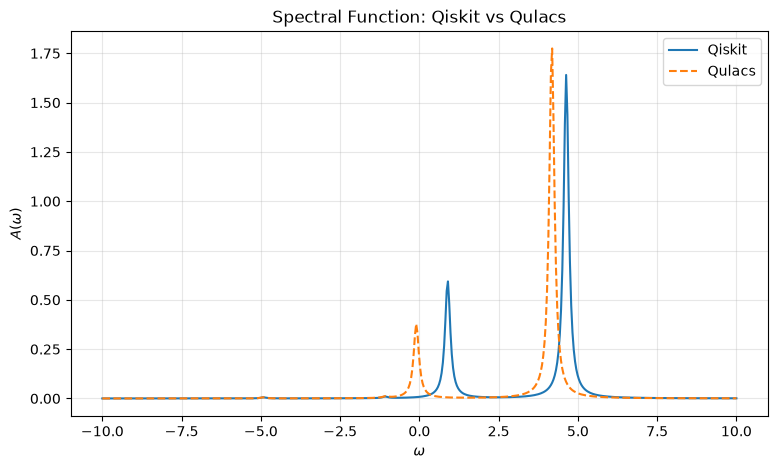

In [138]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# RUN QISKIT ADDITION ONCE MORE
# ============================================================

(
    a_plus_final,
    b_plus_final,
    plus_results_final,
    g_plus_final,
    plus_krylov_final,
) = qv.vqe_gf_pm_qiskit(
    g_vqe=np.zeros_like(w, dtype=np.complex128),
    phi_norm=qiskit_phi_plus_norm,
    w=w,
    niter=2,
    u=qiskit_phi_plus_array,
    Hmat=Hmat,
    H2mat=H2mat,
    charge_sec=charge_plus,
    spin_sec=spin_plus,
    n_layers=vqe_depth,
    up_qubit_indices=up_qubit_indices,
    down_qubit_indices=down_qubit_indices,
    connected_graphs=connected_graphs,
    conv_tol=1e-6,
    optimizer="COBYLA",
    maxiter=10000,
    gf_gtol=5e-5,
)

# ============================================================
# USE EXISTING QISKIT REMOVAL BRANCH
# ============================================================

# If your removal result is named differently,
# replace g_minus_qiskit with that variable.
g_total_qiskit_final = (
    g_minus_qiskit
    + g_plus_final
)

spectral_qiskit_final = (
    -(1.0 / np.pi)
    * np.imag(g_total_qiskit_final)
)

# ============================================================
# DIFFERENCE FROM QULACS
# ============================================================

absolute_difference = np.abs(
    spectral_qiskit_final
    - spectral_qulacs
)

print("=" * 60)
print("FINAL QISKIT ADDITION COEFFICIENTS")
print("=" * 60)

print("a =", np.real_if_close(a_plus_final))
print("b =", np.real_if_close(b_plus_final))

print("\nQulacs reference")
print("a =", np.real_if_close(a_plus_qulacs))
print("b =", np.real_if_close(b_plus_qulacs))

print("\nMaximum spectral difference:")
print(np.max(absolute_difference))

print("\nMean spectral difference:")
print(np.mean(absolute_difference))


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    omega_real,
    spectral_qiskit_final,
    label="Qiskit",
)

plt.plot(
    omega_real,
    spectral_qulacs,
    "--",
    label="Qulacs",
)

plt.xlabel(r"$\omega$")
plt.ylabel(r"$A(\omega)$")
plt.title("Spectral Function: Qiskit vs Qulacs")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [139]:
import numpy as np

n_trials = 20

best_score = np.inf
best_data = None

a_ref = np.asarray(a_plus_qulacs, dtype=float)
b_ref = np.asarray(b_plus_qulacs, dtype=float)

for trial in range(n_trials):

    (
        a_trial,
        b_trial,
        results_trial,
        g_trial,
        krylov_trial,
    ) = qv.vqe_gf_pm_qiskit(
        g_vqe=np.zeros_like(w, dtype=np.complex128),
        phi_norm=qiskit_phi_plus_norm,
        w=w,
        niter=2,
        u=qiskit_phi_plus_array,
        Hmat=Hmat,
        H2mat=H2mat,
        charge_sec=charge_plus,
        spin_sec=spin_plus,
        n_layers=vqe_depth,
        up_qubit_indices=up_qubit_indices,
        down_qubit_indices=down_qubit_indices,
        connected_graphs=connected_graphs,
        conv_tol=1e-6,
        optimizer="COBYLA",
        maxiter=10000,
        gf_gtol=5e-5,
    )

    a_real = np.real_if_close(a_trial).astype(float)
    b_real = np.real_if_close(b_trial).astype(float)

    # Compare only the nontrivial later coefficients
    score = (
        np.sum((a_real[1:] - a_ref[1:])**2)
        + np.sum((b_real[1:] - b_ref[1:])**2)
    )

    print(
        f"Trial {trial + 1:2d}: "
        f"score = {score:.6e}, "
        f"a = {a_real}, "
        f"b = {b_real}"
    )

    if score < best_score:
        best_score = score

        best_data = {
            "a": a_trial,
            "b": b_trial,
            "results": results_trial,
            "g": g_trial,
            "krylov": krylov_trial,
        }


print("\n" + "=" * 70)
print("BEST QISKIT RUN")
print("=" * 70)

print("Score =", best_score)

print("\nQiskit a:")
print(np.real_if_close(best_data["a"]))

print("\nQulacs a:")
print(np.real_if_close(a_plus_qulacs))

print("\nQiskit b:")
print(np.real_if_close(best_data["b"]))

print("\nQulacs b:")
print(np.real_if_close(b_plus_qulacs))

/var/folders/ss/vwdh5_w12qn4rfhf27rxh6rc0000gr/T/ipykernel_89374/520106377.py:8: ComplexWarning: Casting complex values to real discards the imaginary part
  a_ref = np.asarray(a_plus_qulacs, dtype=float)
/var/folders/ss/vwdh5_w12qn4rfhf27rxh6rc0000gr/T/ipykernel_89374/520106377.py:9: ComplexWarning: Casting complex values to real discards the imaginary part
  b_ref = np.asarray(b_plus_qulacs, dtype=float)


Trial  1: score = 4.116470e+00, a = [ 7.33017193 11.98847038  2.10433775], b = [0.         5.89269195 1.65954265]
Trial  2: score = 1.472463e+01, a = [ 7.33017193 12.02923748 -0.86068579], b = [0.         5.89269195 0.61526445]
Trial  3: score = 1.594004e-01, a = [ 7.33017193 10.98011374  1.99369403], b = [0.         5.89269195 3.15779389]
Trial  4: score = 5.056145e-01, a = [ 7.33017193 11.16118779  1.04422902], b = [0.         5.89269195 3.61253539]
Trial  5: score = 3.854341e+00, a = [ 7.33017193 11.86662916  0.30086858], b = [0.         5.89269195 2.23258973]
Trial  6: score = 6.382582e+00, a = [ 7.33017193 10.80972751  4.13326966], b = [0.         5.89269195 3.64604818]
Trial  7: score = 1.023407e+00, a = [ 7.33017193 11.44529539  0.87750354], b = [0.         5.89269195 2.90677532]
Trial  8: score = 6.045979e+00, a = [ 7.33017193 11.25555467 -0.79479985], b = [0.         5.89269195 3.12193466]
Trial  9: score = 7.040273e+00, a = [ 7.33017193 11.88137598  3.13696872], b = [0.      

BEST QISKIT VS QULACS

Qiskit a:
[ 7.33017193 10.98011374  1.99369403]

Qulacs a:
[ 7.33017193 10.90212488  1.63150804]

Qiskit b:
[0.         5.89269195 3.15779389]

Qulacs b:
[0.         5.89269195 3.30658725]

Maximum spectral difference:
0.6171353111238513

Mean spectral difference:
0.017906281283804674


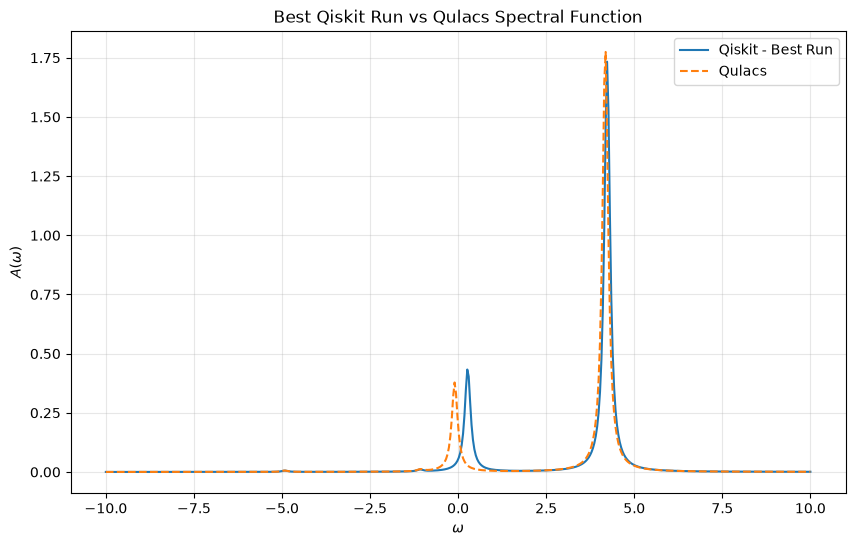

In [140]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# USE THE BEST QISKIT ADDITION RUN ALREADY FOUND
# ============================================================

a_plus_best = best_data["a"]
b_plus_best = best_data["b"]
g_plus_best = best_data["g"]

# Combine with the existing Qiskit removal contribution
g_total_best = (
    g_minus_qiskit
    + g_plus_best
)

spectral_qiskit_best = (
    -(1.0 / np.pi)
    * np.imag(g_total_best)
)

# ============================================================
# COMPARE WITH QULACS
# ============================================================

absolute_difference = np.abs(
    spectral_qiskit_best
    - spectral_qulacs
)

print("=" * 65)
print("BEST QISKIT VS QULACS")
print("=" * 65)

print("\nQiskit a:")
print(np.real_if_close(a_plus_best))

print("\nQulacs a:")
print(np.real_if_close(a_plus_qulacs))

print("\nQiskit b:")
print(np.real_if_close(b_plus_best))

print("\nQulacs b:")
print(np.real_if_close(b_plus_qulacs))

print("\nMaximum spectral difference:")
print(np.max(absolute_difference))

print("\nMean spectral difference:")
print(np.mean(absolute_difference))

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    omega_real,
    spectral_qiskit_best,
    label="Qiskit - Best Run",
)

plt.plot(
    omega_real,
    spectral_qulacs,
    "--",
    label="Qulacs",
)

plt.xlabel(r"$\omega$")
plt.ylabel(r"$A(\omega)$")
plt.title("Best Qiskit Run vs Qulacs Spectral Function")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [141]:
import numpy as np
from scipy.signal import find_peaks

# ============================================================
# FIND NUMERICAL SPECTRAL PEAK POSITIONS
# ============================================================

def get_main_peaks(omega, spectral, n_peaks=2):
    """
    Find local maxima and return the n_peaks largest peaks
    sorted from lowest to highest frequency.
    """

    peak_indices, _ = find_peaks(spectral)

    # Sort peaks by spectral height
    strongest = peak_indices[
        np.argsort(spectral[peak_indices])[-n_peaks:]
    ]

    # Sort selected peaks by omega
    strongest = strongest[
        np.argsort(omega[strongest])
    ]

    return [
        (
            float(omega[i]),
            float(spectral[i])
        )
        for i in strongest
    ]


qiskit_peaks = get_main_peaks(
    omega_real,
    spectral_qiskit,
    n_peaks=2,
)

qulacs_peaks = get_main_peaks(
    omega_real,
    spectral_qulacs,
    n_peaks=2,
)


print("=" * 60)
print("QISKIT PEAKS")
print("=" * 60)

for i, (omega_peak, height) in enumerate(
    qiskit_peaks,
    start=1
):
    print(
        f"Peak {i}: "
        f"omega = {omega_peak:.8f}, "
        f"A(omega) = {height:.8f}"
    )


print("\n" + "=" * 60)
print("QULACS PEAKS")
print("=" * 60)

for i, (omega_peak, height) in enumerate(
    qulacs_peaks,
    start=1
):
    print(
        f"Peak {i}: "
        f"omega = {omega_peak:.8f}, "
        f"A(omega) = {height:.8f}"
    )


print("\n" + "=" * 60)
print("PEAK POSITION DIFFERENCES")
print("=" * 60)

for i in range(2):

    delta = (
        qiskit_peaks[i][0]
        - qulacs_peaks[i][0]
    )

    print(
        f"Peak {i + 1}: "
        f"Delta omega = {delta:.8f}"
    )

QISKIT PEAKS
Peak 1: omega = 3.14629259, A(omega) = 2.02870855
Peak 2: omega = 7.95591182, A(omega) = 0.18739900

QULACS PEAKS
Peak 1: omega = -0.10020040, A(omega) = 0.37806575
Peak 2: omega = 4.18837675, A(omega) = 1.77456956

PEAK POSITION DIFFERENCES
Peak 1: Delta omega = 3.24649299
Peak 2: Delta omega = 3.76753507


In [142]:
qiskit_best_peaks = get_main_peaks(
    omega_real,
    spectral_qiskit_best,
    n_peaks=2,
)

qulacs_peaks = get_main_peaks(
    omega_real,
    spectral_qulacs,
    n_peaks=2,
)

print("BEST QISKIT PEAKS")
for i, (omega_peak, height) in enumerate(qiskit_best_peaks, start=1):
    print(
        f"Peak {i}: "
        f"omega = {omega_peak:.8f}, "
        f"A(omega) = {height:.8f}"
    )

print("\nQULACS PEAKS")
for i, (omega_peak, height) in enumerate(qulacs_peaks, start=1):
    print(
        f"Peak {i}: "
        f"omega = {omega_peak:.8f}, "
        f"A(omega) = {height:.8f}"
    )

BEST QISKIT PEAKS
Peak 1: omega = 0.26052104, A(omega) = 0.43278837
Peak 2: omega = 4.22845691, A(omega) = 1.73341414

QULACS PEAKS
Peak 1: omega = -0.10020040, A(omega) = 0.37806575
Peak 2: omega = 4.18837675, A(omega) = 1.77456956


In [143]:
import numpy as np
from scipy.optimize import minimize

# ============================================================
# LOCAL MINIMA TEST
#
# Same initial theta given to BOTH Qiskit and Qulacs.
# Repeat for several different starting points.
# ============================================================

n_tests = 10
rng = np.random.default_rng(12345)

# ------------------------------------------------------------
# Particle-addition sector setup
# ------------------------------------------------------------

n_qubits = 6
n_edges = connected_graphs["graph_full"].number_of_edges()

n_params = vqe_depth * (
    n_edges + n_qubits
)

n_up_plus = (
    charge_plus + spin_plus
) // 2

n_down_plus = (
    charge_plus - spin_plus
) // 2


# Qulacs initial occupation indices
initial_occ_qulacs = (
    vqe.get_initial_occupations_indices(
        up_qubit_indices,
        down_qubit_indices,
        n_up_plus,
        n_down_plus,
    )
)


# Qiskit initial occupation indices
initial_occ_qiskit = (
    qv.get_initial_occupations_indices_qiskit(
        up_qubit_indices,
        down_qubit_indices,
        n_up_plus,
        n_down_plus,
    )
)


# ------------------------------------------------------------
# Initial Krylov vectors
# ------------------------------------------------------------

ut_qulacs = [
    qulacs_phi_plus
]

ut_qiskit = [
    qiskit_phi_plus_array
]


# ------------------------------------------------------------
# Use the SAME b1 in both implementations
#
# b1 is deterministic and we already verified that it matches.
# ------------------------------------------------------------

b_test = np.zeros(
    3,
    dtype=np.complex128,
)

b_test[1] = b_plus_qulacs[1]


# ------------------------------------------------------------
# Optimizer arguments
# ------------------------------------------------------------

i = 1
compilation = "generic"

qulacs_args = (
    qulacs_ham,
    ut_qulacs,
    b_test,
    i,
    vqe_depth,
    initial_occ_qulacs,
    connected_graphs,
    compilation,
)

qiskit_args = (
    Hmat,
    ut_qiskit,
    b_test,
    i,
    vqe_depth,
    initial_occ_qiskit,
    connected_graphs,
    n_qubits,
    compilation,
)


# ============================================================
# RUN MANY SAME-START TESTS
# ============================================================

comparison_results = []

for test in range(n_tests):

    print("\n" + "=" * 75)
    print(f"STARTING POINT {test + 1}")
    print("=" * 75)

    # --------------------------------------------------------
    # Generate ONE theta_0
    #
    # EXACT SAME VECTOR goes into Qiskit and Qulacs.
    # --------------------------------------------------------

    theta_0 = rng.uniform(
        low=0.0,
        high=2.0 * np.pi,
        size=n_params,
    )


    # ========================================================
    # QULACS OPTIMIZATION
    # ========================================================

    result_qulacs = minimize(
        vqe.lanczos_cost_function,
        theta_0.copy(),
        args=qulacs_args,
        method="COBYLA",
        tol=1e-6,
        options={
            "maxiter": 10000,
        },
    )


    # ========================================================
    # QISKIT OPTIMIZATION
    # ========================================================

    result_qiskit = minimize(
        qv.lanczos_cost_function_qiskit,
        theta_0.copy(),
        args=qiskit_args,
        method="COBYLA",
        tol=1e-6,
        options={
            "maxiter": 10000,
        },
    )


    # --------------------------------------------------------
    # Compare final solutions
    # --------------------------------------------------------

    cost_difference = abs(
        result_qiskit.fun
        - result_qulacs.fun
    )

    parameter_difference = np.max(
        np.abs(
            result_qiskit.x
            - result_qulacs.x
        )
    )


    comparison_results.append({
        "test": test + 1,

        "initial_theta": theta_0.copy(),

        "qulacs_cost": result_qulacs.fun,
        "qiskit_cost": result_qiskit.fun,

        "cost_difference": cost_difference,

        "parameter_difference": parameter_difference,

        "qulacs_success": result_qulacs.success,
        "qiskit_success": result_qiskit.success,

        "qulacs_message": result_qulacs.message,
        "qiskit_message": result_qiskit.message,

        "qulacs_parameters": result_qulacs.x.copy(),
        "qiskit_parameters": result_qiskit.x.copy(),
    })


    print("\nQULACS")
    print("success =", result_qulacs.success)
    print("cost    =", result_qulacs.fun)
    print("message =", result_qulacs.message)

    print("\nQISKIT")
    print("success =", result_qiskit.success)
    print("cost    =", result_qiskit.fun)
    print("message =", result_qiskit.message)

    print("\nQiskit-Qulacs cost difference:")
    print(cost_difference)

    print("\nMaximum parameter difference:")
    print(parameter_difference)


# ============================================================
# SUMMARY
# ============================================================

print("\n")
print("=" * 75)
print("LOCAL-MINIMA TEST SUMMARY")
print("=" * 75)

for result in comparison_results:

    print(
        f"Start {result['test']:2d}: "
        f"Qulacs cost = {result['qulacs_cost']:.10e}, "
        f"Qiskit cost = {result['qiskit_cost']:.10e}, "
        f"Delta cost = {result['cost_difference']:.3e}, "
        f"Delta theta max = {result['parameter_difference']:.3e}"
    )


STARTING POINT 1

QULACS
success = False
cost    = 0.005235547929277278
message = Return from COBYLA because the objective function has been evaluated MAXFUN times.

QISKIT
success = False
cost    = 0.005204185990128899
message = Return from COBYLA because the objective function has been evaluated MAXFUN times.

Qiskit-Qulacs cost difference:
3.136193914837857e-05

Maximum parameter difference:
0.028569502583631667

STARTING POINT 2

QULACS
success = False
cost    = 0.005710716184907145
message = Return from COBYLA because the objective function has been evaluated MAXFUN times.

QISKIT
success = False
cost    = 0.005584504734318049
message = Return from COBYLA because the objective function has been evaluated MAXFUN times.

Qiskit-Qulacs cost difference:
0.00012621145058909662

Maximum parameter difference:
0.03616422675180342

STARTING POINT 3

QULACS
success = False
cost    = 0.001626114228236112
message = Return from COBYLA because the objective function has been evaluated MAXFUN t

In [144]:
print("=" * 90)
print("CROSS-EVALUATION OF FINAL PARAMETERS")
print("=" * 90)

cross_results = []

for result in comparison_results:

    test_number = result["test"]

    theta_qulacs_final = result["qulacs_parameters"]
    theta_qiskit_final = result["qiskit_parameters"]

    # ========================================================
    # Evaluate QULACS final theta using BOTH cost functions
    # ========================================================

    qulacs_cost_at_qulacs_theta = (
        vqe.lanczos_cost_function(
            theta_qulacs_final,
            *qulacs_args,
        )
    )

    qiskit_cost_at_qulacs_theta = (
        qv.lanczos_cost_function_qiskit(
            theta_qulacs_final,
            *qiskit_args,
        )
    )

    # ========================================================
    # Evaluate QISKIT final theta using BOTH cost functions
    # ========================================================

    qulacs_cost_at_qiskit_theta = (
        vqe.lanczos_cost_function(
            theta_qiskit_final,
            *qulacs_args,
        )
    )

    qiskit_cost_at_qiskit_theta = (
        qv.lanczos_cost_function_qiskit(
            theta_qiskit_final,
            *qiskit_args,
        )
    )

    # ========================================================
    # Differences
    # ========================================================

    diff_at_qulacs_theta = abs(
        qulacs_cost_at_qulacs_theta
        - qiskit_cost_at_qulacs_theta
    )

    diff_at_qiskit_theta = abs(
        qulacs_cost_at_qiskit_theta
        - qiskit_cost_at_qiskit_theta
    )

    cross_results.append({
        "test": test_number,
        "diff_at_qulacs_theta": diff_at_qulacs_theta,
        "diff_at_qiskit_theta": diff_at_qiskit_theta,
    })

    print(f"\nSTART {test_number}")
    print("-" * 60)

    print("At Qulacs final theta:")
    print(
        "  Qulacs cost =",
        qulacs_cost_at_qulacs_theta
    )
    print(
        "  Qiskit cost =",
        qiskit_cost_at_qulacs_theta
    )
    print(
        "  difference  =",
        diff_at_qulacs_theta
    )

    print("\nAt Qiskit final theta:")
    print(
        "  Qulacs cost =",
        qulacs_cost_at_qiskit_theta
    )
    print(
        "  Qiskit cost =",
        qiskit_cost_at_qiskit_theta
    )
    print(
        "  difference  =",
        diff_at_qiskit_theta
    )


print("\n" + "=" * 90)
print("SUMMARY")
print("=" * 90)

print(
    "Maximum objective disagreement at Qulacs final theta:",
    max(
        r["diff_at_qulacs_theta"]
        for r in cross_results
    )
)

print(
    "Maximum objective disagreement at Qiskit final theta:",
    max(
        r["diff_at_qiskit_theta"]
        for r in cross_results
    )
)

CROSS-EVALUATION OF FINAL PARAMETERS

START 1
------------------------------------------------------------
At Qulacs final theta:
  Qulacs cost = 0.005235547929277278
  Qiskit cost = 0.005235547929277206
  difference  = 7.19910242530375e-17

At Qiskit final theta:
  Qulacs cost = 0.005204185990128951
  Qiskit cost = 0.005204185990128899
  difference  = 5.204170427930421e-17

START 2
------------------------------------------------------------
At Qulacs final theta:
  Qulacs cost = 0.005710716184907145
  Qiskit cost = 0.005710716184907134
  difference  = 1.1275702593849246e-17

At Qiskit final theta:
  Qulacs cost = 0.0055845047343180505
  Qiskit cost = 0.005584504734318049
  difference  = 1.734723475976807e-18

START 3
------------------------------------------------------------
At Qulacs final theta:
  Qulacs cost = 0.001626114228236112
  Qiskit cost = 0.001626114228236086
  difference  = 2.6020852139652106e-17

At Qiskit final theta:
  Qulacs cost = 0.0015994817774492168
  Qiskit cos

In [148]:
import numpy as np
from scipy.optimize import minimize

# ============================================================
# SIMPLE MAXITER TEST
# Same initialization every time.
# ============================================================

maxiter_values = [
    10000,
    20000,
    50000,
    100000,
    250000,
]

# Fixed initialization so maxiter is the ONLY thing changing
rng = np.random.default_rng(12345)

theta_0 = rng.uniform(
    0.0,
    2.0 * np.pi,
    size=n_params
)

print("=" * 90)
print("MAXITER TEST — QISKIT")
print("=" * 90)

for maxiter_test in maxiter_values:

    result = minimize(
        qv.lanczos_cost_function_qiskit,
        theta_0.copy(),
        args=qiskit_args,
        method="COBYLA",
        tol=1e-6,
        options={
            "maxiter": maxiter_test,
        },
    )

    print(f"\nmaxiter = {maxiter_test}")
    print(f"success = {result.success}")
    print(f"cost    = {result.fun:.10e}")
    print(f"nfev    = {result.nfev}")
    print(f"message = {result.message}")

MAXITER TEST — QISKIT

maxiter = 10000
success = False
cost    = 5.2041859901e-03
nfev    = 10000
message = Return from COBYLA because the objective function has been evaluated MAXFUN times.

maxiter = 20000
success = False
cost    = 4.4598411290e-03
nfev    = 20000
message = Return from COBYLA because the objective function has been evaluated MAXFUN times.

maxiter = 50000
success = False
cost    = 1.6480095057e-03
nfev    = 50000
message = Return from COBYLA because the objective function has been evaluated MAXFUN times.

maxiter = 100000
success = False
cost    = 2.8209273387e-04
nfev    = 100000
message = Return from COBYLA because the objective function has been evaluated MAXFUN times.

maxiter = 250000
success = False
cost    = 1.1658537976e-04
nfev    = 250000
message = Return from COBYLA because the objective function has been evaluated MAXFUN times.


BRANCH ISOLATION TEST
Qiskit removal + Qulacs addition:
  max difference = 0.0004399852559000411
  mean difference = 8.644407096083562e-06

Qulacs removal + Qiskit addition:
  max difference = 2.011609700382303
  mean difference = 0.060569175370598034

Full Qiskit:
  max difference = 2.011609734661628
  mean difference = 0.06057010769447264


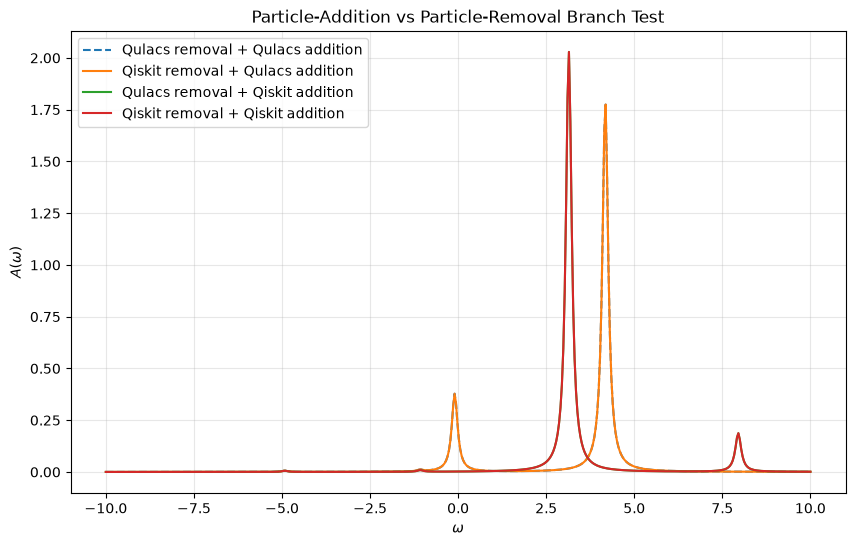

In [149]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# BRANCH-ISOLATION TEST
# ============================================================

# Qulacs reference
g_LL = g_minus_qulacs + g_plus_qulacs

# Qiskit removal + Qulacs addition
g_QL = g_minus_qiskit + g_plus_qulacs

# Qulacs removal + Qiskit addition
g_LQ = g_minus_qulacs + g_plus_qiskit

# Full Qiskit
g_QQ = g_minus_qiskit + g_plus_qiskit


# Spectral functions
A_LL = -(1.0 / np.pi) * np.imag(g_LL)
A_QL = -(1.0 / np.pi) * np.imag(g_QL)
A_LQ = -(1.0 / np.pi) * np.imag(g_LQ)
A_QQ = -(1.0 / np.pi) * np.imag(g_QQ)


# ============================================================
# NUMERICAL DIFFERENCE FROM QULACS REFERENCE
# ============================================================

print("=" * 70)
print("BRANCH ISOLATION TEST")
print("=" * 70)

print(
    "Qiskit removal + Qulacs addition:"
)
print(
    "  max difference =",
    np.max(np.abs(A_QL - A_LL))
)
print(
    "  mean difference =",
    np.mean(np.abs(A_QL - A_LL))
)

print(
    "\nQulacs removal + Qiskit addition:"
)
print(
    "  max difference =",
    np.max(np.abs(A_LQ - A_LL))
)
print(
    "  mean difference =",
    np.mean(np.abs(A_LQ - A_LL))
)

print(
    "\nFull Qiskit:"
)
print(
    "  max difference =",
    np.max(np.abs(A_QQ - A_LL))
)
print(
    "  mean difference =",
    np.mean(np.abs(A_QQ - A_LL))
)


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    omega_real,
    A_LL,
    "--",
    label="Qulacs removal + Qulacs addition",
)

plt.plot(
    omega_real,
    A_QL,
    label="Qiskit removal + Qulacs addition",
)

plt.plot(
    omega_real,
    A_LQ,
    label="Qulacs removal + Qiskit addition",
)

plt.plot(
    omega_real,
    A_QQ,
    label="Qiskit removal + Qiskit addition",
)

plt.xlabel(r"$\omega$")
plt.ylabel(r"$A(\omega)$")
plt.title("Particle-Addition vs Particle-Removal Branch Test")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

ADDITION COEFFICIENTS

Qulacs a = [ 7.33017193 10.90212488  1.63150804]
Qiskit a = [ 7.33017193 11.94602403  7.99378138]

Qulacs b = [0.         5.89269195 3.30658725]
Qiskit b = [0.         5.89269195 1.58009015]

DIFFERENCE FROM QULACS-COEFFICIENT REFERENCE

Replace only a1
  max difference  = 1.4728384439101945
  mean difference = 0.03114661172572059

Replace only a2
  max difference  = 1.769903571261857
  mean difference = 0.06464708728625246

Replace only b2
  max difference  = 1.7446347835964002
  mean difference = 0.05604105663910633

All Qiskit addition coeffs
  max difference  = 2.0116097003823006
  mean difference = 0.060569175370598013


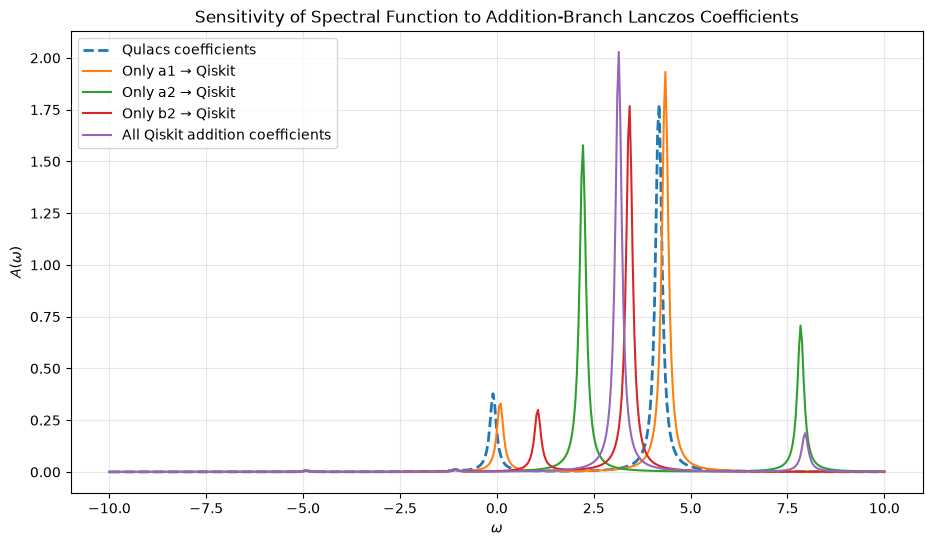

In [150]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# COEFFICIENT-SWAP TEST — PARTICLE ADDITION BRANCH
# ============================================================

# Reference Qulacs addition coefficients
a_ref = np.real_if_close(a_plus_qulacs).astype(float)
b_ref = np.real_if_close(b_plus_qulacs).astype(float)

# Qiskit addition coefficients
a_q = np.real_if_close(a_plus_qiskit).astype(float)
b_q = np.real_if_close(b_plus_qiskit).astype(float)

print("=" * 70)
print("ADDITION COEFFICIENTS")
print("=" * 70)

print("\nQulacs a =", a_ref)
print("Qiskit a =", a_q)

print("\nQulacs b =", b_ref)
print("Qiskit b =", b_q)


# ============================================================
# HELPER:
# Build addition Green's function from chosen a,b coefficients
# ============================================================

def build_addition_gf(a_coeffs, b_coeffs):
    return (
        qiskit_phi_plus_norm**2
        * qv.continued_fraction_qiskit(
            w,
            np.asarray(a_coeffs, dtype=np.complex128),
            np.asarray(b_coeffs, dtype=np.complex128),
        )
    )


# ============================================================
# 1. PURE QULACS COEFFICIENT REFERENCE
# ============================================================

g_plus_ref_coeffs = build_addition_gf(
    a_ref,
    b_ref,
)

# ============================================================
# 2. REPLACE ONLY a1 WITH QISKIT VALUE
# ============================================================

a_swap_a1 = a_ref.copy()
a_swap_a1[1] = a_q[1]

g_plus_swap_a1 = build_addition_gf(
    a_swap_a1,
    b_ref,
)


# ============================================================
# 3. REPLACE ONLY a2 WITH QISKIT VALUE
# ============================================================

a_swap_a2 = a_ref.copy()
a_swap_a2[2] = a_q[2]

g_plus_swap_a2 = build_addition_gf(
    a_swap_a2,
    b_ref,
)


# ============================================================
# 4. REPLACE ONLY b2 WITH QISKIT VALUE
# ============================================================

b_swap_b2 = b_ref.copy()
b_swap_b2[2] = b_q[2]

g_plus_swap_b2 = build_addition_gf(
    a_ref,
    b_swap_b2,
)


# ============================================================
# 5. ALL QISKIT ADDITION COEFFICIENTS
# ============================================================

g_plus_all_qiskit_coeffs = build_addition_gf(
    a_q,
    b_q,
)


# ============================================================
# COMBINE EACH ADDITION TEST WITH SAME QULACS REMOVAL BRANCH
# ============================================================

A_reference = -(1.0 / np.pi) * np.imag(
    g_minus_qulacs + g_plus_ref_coeffs
)

A_swap_a1 = -(1.0 / np.pi) * np.imag(
    g_minus_qulacs + g_plus_swap_a1
)

A_swap_a2 = -(1.0 / np.pi) * np.imag(
    g_minus_qulacs + g_plus_swap_a2
)

A_swap_b2 = -(1.0 / np.pi) * np.imag(
    g_minus_qulacs + g_plus_swap_b2
)

A_all_qiskit = -(1.0 / np.pi) * np.imag(
    g_minus_qulacs + g_plus_all_qiskit_coeffs
)


# ============================================================
# NUMERICAL DIFFERENCES
# ============================================================

tests = {
    "Replace only a1": A_swap_a1,
    "Replace only a2": A_swap_a2,
    "Replace only b2": A_swap_b2,
    "All Qiskit addition coeffs": A_all_qiskit,
}

print("\n" + "=" * 70)
print("DIFFERENCE FROM QULACS-COEFFICIENT REFERENCE")
print("=" * 70)

for name, spectrum in tests.items():

    difference = np.abs(
        spectrum - A_reference
    )

    print(f"\n{name}")
    print(
        "  max difference  =",
        np.max(difference)
    )
    print(
        "  mean difference =",
        np.mean(difference)
    )


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(11, 6))

plt.plot(
    omega_real,
    A_reference,
    "--",
    linewidth=2,
    label="Qulacs coefficients",
)

plt.plot(
    omega_real,
    A_swap_a1,
    label="Only a1 → Qiskit",
)

plt.plot(
    omega_real,
    A_swap_a2,
    label="Only a2 → Qiskit",
)

plt.plot(
    omega_real,
    A_swap_b2,
    label="Only b2 → Qiskit",
)

plt.plot(
    omega_real,
    A_all_qiskit,
    label="All Qiskit addition coefficients",
)

plt.xlabel(r"$\omega$")
plt.ylabel(r"$A(\omega)$")

plt.title(
    "Sensitivity of Spectral Function "
    "to Addition-Branch Lanczos Coefficients"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [152]:
import numpy as np

from scipy.optimize import minimize
from qulacs import QuantumState


# ============================================================
# NOTEBOOK-ONLY QULACS LANCZOS
#
# Same calculation as vqe.vqe_ideal_lanczos_iterations()
# but ALSO returns the Krylov states.
#
# vqe.py IS NOT MODIFIED.
# ============================================================

def qulacs_lanczos_with_states(
    niter,
    u,
    h,
    h2,
    charge_sec,
    spin_sec,
    n_layers,
    up_qubit_indices,
    down_qubit_indices,
    connected_graphs,
    conv_tol=1e-6,
    optimizer="COBYLA",
    maxiter=10000,
):

    n_qubits = h.get_qubit_count()

    n_edges = (
        connected_graphs[
            "graph_full"
        ].number_of_edges()
    )

    n_up = (
        charge_sec + spin_sec
    ) // 2

    n_down = (
        charge_sec - spin_sec
    ) // 2

    initial_occupations_indices = (
        vqe.get_initial_occupations_indices(
            up_qubit_indices,
            down_qubit_indices,
            n_up,
            n_down,
        )
    )

    compilation = "generic"

    # --------------------------------------------------------
    # Lanczos coefficients
    # --------------------------------------------------------

    a = np.zeros(
        niter + 1,
        dtype=np.complex128,
    )

    b = np.zeros(
        niter + 1,
        dtype=np.complex128,
    )

    # --------------------------------------------------------
    # Store Krylov states
    # --------------------------------------------------------

    ut = [
        u.copy()
    ]

    b[0] = 0.0

    a[0] = h.get_expectation_value(
        ut[0]
    )

    results = {}

    # ========================================================
    # LANCZOS ITERATIONS
    # ========================================================

    for i in range(
        1,
        niter + 1,
    ):

        print("\n" + "=" * 60)
        print(
            f"QULACS LANCZOS ITERATION {i}"
        )
        print("=" * 60)

        # ----------------------------------------------------
        # Calculate b_i
        # ----------------------------------------------------

        h2_expectation = (
            h2.get_expectation_value(
                ut[i - 1]
            )
        )

        if i == 1:

            b_squared = (
                h2_expectation
                - a[i - 1] ** 2
            )

        else:

            b_squared = (
                h2_expectation
                - a[i - 1] ** 2
                - b[i - 1] ** 2
            )

        b[i] = np.sqrt(
            b_squared
        )

        print(
            f"b[{i}] =",
            b[i],
        )

        if np.isclose(
            b[i],
            0.0,
        ):
            break

        # ----------------------------------------------------
        # Number of ansatz parameters
        # ----------------------------------------------------

        n_params = (
            n_layers
            * (
                n_edges
                + n_qubits
            )
        )

        # ----------------------------------------------------
        # Arguments to original Qulacs cost function
        # ----------------------------------------------------

        opt_args = (
            h,
            ut,
            b,
            i,
            n_layers,
            initial_occupations_indices,
            connected_graphs,
            compilation,
        )

        # ----------------------------------------------------
        # Initial random parameters
        # ----------------------------------------------------

        theta_0 = np.random.uniform(
            low=0.0,
            high=2.0 * np.pi,
            size=n_params,
        )

        # ----------------------------------------------------
        # First optimization
        # ----------------------------------------------------

        result = minimize(
            vqe.lanczos_cost_function,
            theta_0,
            args=opt_args,
            method=optimizer,
            tol=conv_tol,
            options={
                "maxiter": int(maxiter),
            },
        )

        best_result = result

        # ----------------------------------------------------
        # Match original retry behavior
        # ----------------------------------------------------

        if not result.success:

            for retry in range(5):

                theta_retry = (
                    np.random.uniform(
                        low=0.0,
                        high=2.0 * np.pi,
                        size=n_params,
                    )
                )

                retry_result = minimize(
                    vqe.lanczos_cost_function,
                    theta_retry,
                    args=opt_args,
                    method=optimizer,
                    tol=conv_tol,
                    options={
                        "maxiter": int(
                            maxiter
                        ),
                    },
                )

                if (
                    retry_result.fun
                    < best_result.fun
                ):
                    best_result = (
                        retry_result
                    )

                if retry_result.success:
                    best_result = (
                        retry_result
                    )
                    break

        result = best_result

        print(
            "cost =",
            result.fun,
        )

        print(
            "success =",
            result.success,
        )

        # ----------------------------------------------------
        # Rebuild optimized Qulacs Krylov state
        # ----------------------------------------------------

        symm_qulacs = (
            aim.SymmQulacsVqeEmulator(
                h
            )
        )

        ws = QuantumState(
            n_qubits
        )

        qc_ansatz = (
            symm_qulacs
            .all_symmetry_ansatzae(
                theta=result.x,
                n_layers=n_layers,
                initial_occupations_indices=(
                    initial_occupations_indices
                ),
                connected_graphs=(
                    connected_graphs
                ),
                compilation=compilation,
            )
        )

        ws.set_zero_state()

        qc_ansatz.update_quantum_state(
            ws
        )

        # Normalize
        squared_norm = (
            ws.get_squared_norm()
        )

        ws.normalize(
            squared_norm
        )

        # Save state
        ut.append(
            ws.copy()
        )

        # ----------------------------------------------------
        # Calculate a_i
        # ----------------------------------------------------

        a[i] = (
            h.get_expectation_value(
                ut[i]
            )
        )

        print(
            f"a[{i}] =",
            a[i],
        )

        results[i] = {
            "success": result.success,
            "message": result.message,
            "fun": result.fun,
            "x": result.x.copy(),
        }

    return (
        a,
        b,
        results,
        ut,
    )

In [153]:
(
    a_plus_qulacs_states,
    b_plus_qulacs_states,
    results_plus_qulacs_states,
    plus_krylov_states_qulacs,
) = qulacs_lanczos_with_states(

    niter=2,

    u=qulacs_phi_plus,

    h=qulacs_ham,
    h2=qulacs_H2,

    charge_sec=charge_plus,
    spin_sec=spin_plus,

    n_layers=vqe_depth,

    up_qubit_indices=(
        up_qubit_indices
    ),

    down_qubit_indices=(
        down_qubit_indices
    ),

    connected_graphs=(
        connected_graphs
    ),

    conv_tol=1e-6,

    optimizer="COBYLA",

    maxiter=10000,
)

print(
    "\nQulacs a:",
    np.real_if_close(
        a_plus_qulacs_states
    ),
)

print(
    "Qulacs b:",
    np.real_if_close(
        b_plus_qulacs_states
    ),
)

print(
    "Number of Qulacs Krylov states:",
    len(
        plus_krylov_states_qulacs
    ),
)


QULACS LANCZOS ITERATION 1
b[1] = (5.8926919455511655+0j)
cost = 0.002908295497465631
success = False
a[1] = (11.279540912598604+0j)

QULACS LANCZOS ITERATION 2
b[2] = (3.7314562419512827+0j)
cost = 0.0005970044553670277
success = False
a[2] = (2.397807034440786+0j)

Qulacs a: [ 7.33017193 11.27954091  2.39780703]
Qulacs b: [0.         5.89269195 3.73145624]
Number of Qulacs Krylov states: 3


In [154]:
import numpy as np

print("=" * 70)
print("QISKIT vs QULACS — ADDITION KRYLOV STATE FIDELITY")
print("=" * 70)


# ------------------------------------------------------------
# Qiskit states from your current addition calculation
# ------------------------------------------------------------

qiskit_states = plus_krylov_qiskit_new

# Qulacs states we just generated
qulacs_states = plus_krylov_states_qulacs


def get_state_vector(state):

    # Qulacs QuantumState
    if hasattr(state, "get_vector"):
        vec = state.get_vector()

    # Qiskit / numpy state
    else:
        vec = np.asarray(
            state,
            dtype=np.complex128,
        )

    vec = np.asarray(
        vec,
        dtype=np.complex128,
    )

    return vec / np.linalg.norm(vec)


# ------------------------------------------------------------
# Compare each Krylov state
# ------------------------------------------------------------

for i in range(
    min(
        len(qiskit_states),
        len(qulacs_states),
    )
):

    q = get_state_vector(
        qiskit_states[i]
    )

    l = get_state_vector(
        qulacs_states[i]
    )

    overlap = np.vdot(
        l,
        q,
    )

    fidelity = (
        np.abs(overlap) ** 2
    )

    print(f"\nKrylov state u{i}")
    print("-" * 40)

    print(
        "Fidelity =",
        fidelity,
    )

    print(
        "|overlap| =",
        np.abs(overlap),
    )


print("\n" + "=" * 70)

QISKIT vs QULACS — ADDITION KRYLOV STATE FIDELITY

Krylov state u0
----------------------------------------
Fidelity = 1.0000000000000004
|overlap| = 1.0000000000000002

Krylov state u1
----------------------------------------
Fidelity = 3.6107053260143543e-68
|overlap| = 1.9001856030436486e-34

Krylov state u2
----------------------------------------
Fidelity = 2.4426094875893264e-70
|overlap| = 1.5628849885993935e-35



In [155]:
def qulacs_lanczos_with_states_fixed_start(
    niter,
    u,
    h,
    h2,
    charge_sec,
    spin_sec,
    n_layers,
    up_qubit_indices,
    down_qubit_indices,
    connected_graphs,
    initial_thetas,
    conv_tol=1e-6,
    optimizer="COBYLA",
    maxiter=10000,
):

    n_qubits = h.get_qubit_count()

    n_edges = (
        connected_graphs[
            "graph_full"
        ].number_of_edges()
    )

    n_up = (
        charge_sec + spin_sec
    ) // 2

    n_down = (
        charge_sec - spin_sec
    ) // 2

    initial_occupations_indices = (
        vqe.get_initial_occupations_indices(
            up_qubit_indices,
            down_qubit_indices,
            n_up,
            n_down,
        )
    )

    compilation = "generic"

    a = np.zeros(
        niter + 1,
        dtype=np.complex128,
    )

    b = np.zeros(
        niter + 1,
        dtype=np.complex128,
    )

    ut = [u.copy()]

    b[0] = 0.0

    a[0] = h.get_expectation_value(
        ut[0]
    )

    results = {}

    for i in range(
        1,
        niter + 1,
    ):

        # ---------------------------------------------
        # Calculate b_i
        # ---------------------------------------------

        h2_expectation = (
            h2.get_expectation_value(
                ut[i - 1]
            )
        )

        if i == 1:

            b_squared = (
                h2_expectation
                - a[i - 1] ** 2
            )

        else:

            b_squared = (
                h2_expectation
                - a[i - 1] ** 2
                - b[i - 1] ** 2
            )

        b[i] = np.sqrt(
            b_squared
        )

        if np.isclose(
            b[i],
            0.0,
        ):
            break

        # ---------------------------------------------
        # SAME supplied starting theta
        # ---------------------------------------------

        theta_0 = np.asarray(
            initial_thetas[i - 1],
            dtype=float,
        ).copy()

        opt_args = (
            h,
            ut,
            b,
            i,
            n_layers,
            initial_occupations_indices,
            connected_graphs,
            compilation,
        )

        result = minimize(
            vqe.lanczos_cost_function,
            theta_0,
            args=opt_args,
            method=optimizer,
            tol=conv_tol,
            options={
                "maxiter": int(maxiter),
            },
        )

        # ---------------------------------------------
        # Reconstruct optimized state
        # ---------------------------------------------

        symm_qulacs = (
            aim.SymmQulacsVqeEmulator(
                h
            )
        )

        ws = QuantumState(
            n_qubits
        )

        qc_ansatz = (
            symm_qulacs
            .all_symmetry_ansatzae(
                theta=result.x,
                n_layers=n_layers,
                initial_occupations_indices=(
                    initial_occupations_indices
                ),
                connected_graphs=(
                    connected_graphs
                ),
                compilation=compilation,
            )
        )

        ws.set_zero_state()

        qc_ansatz.update_quantum_state(
            ws
        )

        squared_norm = (
            ws.get_squared_norm()
        )

        ws.normalize(
            squared_norm
        )

        ut.append(
            ws.copy()
        )

        a[i] = (
            h.get_expectation_value(
                ut[i]
            )
        )

        results[i] = {
            "x": result.x.copy(),
            "fun": result.fun,
            "success": result.success,
            "message": result.message,
        }

    return (
        a,
        b,
        results,
        ut,
    )

In [156]:
rng = np.random.default_rng(12345)

shared_initial_thetas = [
    rng.uniform(
        0.0,
        2.0 * np.pi,
        size=13,
    )
    for _ in range(2)
]

In [157]:
(
    a_q_control,
    b_q_control,
    results_q_control,
    g_q_control,
    q_states_control,
) = qv.vqe_gf_pm_qiskit(

    g_vqe=np.zeros_like(
        w,
        dtype=np.complex128,
    ),

    phi_norm=qiskit_phi_plus_norm,
    w=w,

    niter=2,

    u=qiskit_phi_plus_array,

    Hmat=Hmat,
    H2mat=H2mat,

    charge_sec=charge_plus,
    spin_sec=spin_plus,

    n_layers=vqe_depth,

    up_qubit_indices=up_qubit_indices,
    down_qubit_indices=down_qubit_indices,

    connected_graphs=connected_graphs,

    conv_tol=1e-6,
    optimizer="COBYLA",
    maxiter=10000,
    gf_gtol=5e-5,

    initial_thetas=shared_initial_thetas,
)

TypeError: vqe_ideal_lanczos_iterations_qiskit() got an unexpected keyword argument 'initial_thetas'

In [158]:
import importlib
import qiskit_port.qiskit_vqe as qv

importlib.reload(qv)

<module 'qiskit_port.qiskit_vqe' from '/Users/aporter2/Downloads/nlr_qc/qcaob-aim/qiskit_port/qiskit_vqe.py'>

In [159]:
import inspect

print(
    inspect.signature(
        qv.vqe_ideal_lanczos_iterations_qiskit
    )
)

(niter, u, Hmat, H2mat, charge_sec, spin_sec, n_layers, up_qubit_indices, down_qubit_indices, connected_graphs, conv_tol=1e-06, optimizer='COBYLA', maxiter=2000, gf_gtol=5e-05, initial_thetas=None)


In [160]:
import importlib
import qiskit_port.qiskit_vqe as qv

importlib.reload(qv)

<module 'qiskit_port.qiskit_vqe' from '/Users/aporter2/Downloads/nlr_qc/qcaob-aim/qiskit_port/qiskit_vqe.py'>

In [162]:
rng = np.random.default_rng(12345)

shared_initial_thetas = [
    rng.uniform(
        0.0,
        2.0 * np.pi,
        size=13,
    )
    for _ in range(2)
]

In [163]:
(
    a_q_control,
    b_q_control,
    results_q_control,
    g_q_control,
    q_states_control,
) = qv.vqe_gf_pm_qiskit(
    g_vqe=np.zeros_like(
        w,
        dtype=np.complex128,
    ),
    phi_norm=qiskit_phi_plus_norm,
    w=w,
    niter=2,
    u=qiskit_phi_plus_array,
    Hmat=Hmat,
    H2mat=H2mat,
    charge_sec=charge_plus,
    spin_sec=spin_plus,
    n_layers=vqe_depth,
    up_qubit_indices=up_qubit_indices,
    down_qubit_indices=down_qubit_indices,
    connected_graphs=connected_graphs,
    conv_tol=1e-6,
    optimizer="COBYLA",
    maxiter=10000,
    gf_gtol=5e-5,
    initial_thetas=shared_initial_thetas,
)

ValueError: Negative b² encountered at iteration 2: -3.415142317886641

In [164]:
import importlib
import numpy as np
import qiskit_port.qiskit_vqe as qv

importlib.reload(qv)

rng = np.random.default_rng(12345)

n_params = 13

shared_initial_thetas = [
    rng.uniform(0.0, 2.0*np.pi, size=n_params)
    for _ in range(2)
]

print("Iteration 1 starting theta:")
print(shared_initial_thetas[0])

print("\nIteration 2 starting theta:")
print(shared_initial_thetas[1])

Iteration 1 starting theta:
[1.42839436 1.99025135 5.00999493 4.24903341 2.45741378 2.09113158
 3.75928477 1.17328549 4.22705089 5.91752193 1.55977383 5.96199611
 4.19237656]

Iteration 2 starting theta:
[0.6025445  2.7761605  5.5699176  4.38222958 2.0512895  4.61140665
 1.38314872 0.5126738  1.00465369 2.13691249 2.92289479 1.67397269
 5.12567431]


In [166]:
(
    a_q1,
    b_q1,
    results_q1,
    g_q1,
    q_states_1,
) = qv.vqe_gf_pm_qiskit(
    g_vqe=np.zeros_like(w, dtype=np.complex128),
    phi_norm=qiskit_phi_plus_norm,
    w=w,

    niter=1,
    u=qiskit_phi_plus_array,

    Hmat=Hmat,
    H2mat=H2mat,

    charge_sec=charge_plus,
    spin_sec=spin_plus,

    n_layers=vqe_depth,

    up_qubit_indices=up_qubit_indices,
    down_qubit_indices=down_qubit_indices,

    connected_graphs=connected_graphs,

    conv_tol=1e-6,
    optimizer="COBYLA",
    maxiter=10000,
    gf_gtol=5e-5,

    initial_thetas=[
        shared_initial_thetas[0]
    ],
)

In [167]:
(
    a_l1,
    b_l1,
    results_l1,
    l_states_1,
) = qulacs_lanczos_with_states_fixed_start(
    niter=1,

    u=qulacs_phi_plus,

    h=qulacs_ham,
    h2=qulacs_H2,

    charge_sec=charge_plus,
    spin_sec=spin_plus,

    n_layers=vqe_depth,

    up_qubit_indices=up_qubit_indices,
    down_qubit_indices=down_qubit_indices,

    connected_graphs=connected_graphs,

    initial_thetas=[
        shared_initial_thetas[0]
    ],

    conv_tol=1e-6,
    optimizer="COBYLA",
    maxiter=10000,
)

In [168]:
q_u1 = np.asarray(
    q_states_1[1],
    dtype=np.complex128,
)

l_u1 = np.asarray(
    l_states_1[1].get_vector(),
    dtype=np.complex128,
)

q_u1 /= np.linalg.norm(q_u1)
l_u1 /= np.linalg.norm(l_u1)

fidelity_u1 = (
    abs(np.vdot(l_u1, q_u1)) ** 2
)

cost_q = results_q1[1]["fun"]
cost_l = results_l1[1]["fun"]

theta_q = results_q1[1]["parameters"]
theta_l = results_l1[1]["x"]

print("=" * 75)
print("CONTROLLED ITERATION-1 COMPARISON")
print("=" * 75)

print("\nStarting theta difference:")
print(
    np.max(
        np.abs(
            shared_initial_thetas[0]
            - shared_initial_thetas[0]
        )
    )
)

print("\nFinal cost:")
print("Qiskit =", cost_q)
print("Qulacs =", cost_l)
print("difference =", abs(cost_q - cost_l))

print("\nFinal parameter difference:")
print(
    np.max(
        np.abs(theta_q - theta_l)
    )
)

print("\nu1 fidelity:")
print(fidelity_u1)

print("\nLanczos coefficients:")
print("Qiskit a =", np.real_if_close(a_q1))
print("Qulacs a =", np.real_if_close(a_l1))

print("Qiskit b =", np.real_if_close(b_q1))
print("Qulacs b =", np.real_if_close(b_l1))

CONTROLLED ITERATION-1 COMPARISON

Starting theta difference:
0.0

Final cost:
Qiskit = 0.005223352295997019
Qulacs = 0.005235547929277278
difference = 1.2195633280258529e-05

Final parameter difference:
0.021072650900506584

u1 fidelity:
0.9999657645377981

Lanczos coefficients:
Qiskit a = [ 7.33017193 12.19494019]
Qulacs a = [ 7.33017193 12.20038261]
Qiskit b = [0.         5.89269195]
Qulacs b = [0.         5.89269195]


In [169]:
# ============================================================
# PROSPECTIVE b2^2 COMPARISON
# ============================================================

# Qulacs
h2_l = qulacs_H2.get_expectation_value(
    l_states_1[1]
)

b2_sq_l = (
    h2_l
    - a_l1[1]**2
    - b_l1[1]**2
)


# Qiskit:
# reorder ONLY for OpenFermion matrix multiplication
q_u1_ordered = (
    qv.qulacs_to_python_ordering_qiskit(
        q_states_1[1],
        n_qubits,
    )
)

h2_q = np.vdot(
    q_u1_ordered,
    H2mat @ q_u1_ordered,
)

b2_sq_q = (
    h2_q
    - a_q1[1]**2
    - b_q1[1]**2
)


print("=" * 75)
print("PROSPECTIVE b2^2 COMPARISON")
print("=" * 75)

print("Qiskit <H^2> =", h2_q)
print("Qulacs <H^2> =", h2_l)

print("\nQiskit b2^2 =", b2_sq_q)
print("Qulacs b2^2 =", b2_sq_l)

print(
    "\nDifference =",
    abs(b2_sq_q - b2_sq_l)
)

PROSPECTIVE b2^2 COMPARISON
Qiskit <H^2> = (180.0252422338556-1.0547118733938987e-15j)
Qulacs <H^2> = (180.14825159187498+0j)

Qiskit b2^2 = (-3.415142317886641-1.819013958938817e-14j)
Qulacs b2^2 = (-3.424902611276295+0j)

Difference = 0.009760293389653896


In [170]:
import importlib
import qiskit_port.qiskit_vqe as qv

importlib.reload(qv)

<module 'qiskit_port.qiskit_vqe' from '/Users/aporter2/Downloads/nlr_qc/qcaob-aim/qiskit_port/qiskit_vqe.py'>

In [171]:
(
    a_q_control,
    b_q_control,
    results_q_control,
    g_q_control,
    q_states_control,
) = qv.vqe_gf_pm_qiskit(
    g_vqe=np.zeros_like(w, dtype=np.complex128),
    phi_norm=qiskit_phi_plus_norm,
    w=w,
    niter=2,
    u=qiskit_phi_plus_array,
    Hmat=Hmat,
    H2mat=H2mat,
    charge_sec=charge_plus,
    spin_sec=spin_plus,
    n_layers=vqe_depth,
    up_qubit_indices=up_qubit_indices,
    down_qubit_indices=down_qubit_indices,
    connected_graphs=connected_graphs,
    conv_tol=1e-6,
    optimizer="COBYLA",
    maxiter=10000,
    gf_gtol=5e-5,
    initial_thetas=shared_initial_thetas,
)

In [172]:
(
    a_l_control,
    b_l_control,
    results_l_control,
    l_states_control,
) = qulacs_lanczos_with_states_fixed_start(
    niter=2,
    u=qulacs_phi_plus,
    h=qulacs_ham,
    h2=qulacs_H2,
    charge_sec=charge_plus,
    spin_sec=spin_plus,
    n_layers=vqe_depth,
    up_qubit_indices=up_qubit_indices,
    down_qubit_indices=down_qubit_indices,
    connected_graphs=connected_graphs,
    initial_thetas=shared_initial_thetas,
    conv_tol=1e-6,
    optimizer="COBYLA",
    maxiter=10000,
)

In [173]:
print("=" * 75)
print("CONTROLLED TWO-ITERATION QISKIT vs QULACS")
print("=" * 75)

for i in range(3):

    q = np.asarray(
        q_states_control[i],
        dtype=np.complex128
    )

    l = np.asarray(
        l_states_control[i].get_vector(),
        dtype=np.complex128
    )

    q /= np.linalg.norm(q)
    l /= np.linalg.norm(l)

    fidelity = abs(np.vdot(l, q))**2

    print(f"\nu{i} fidelity = {fidelity:.16e}")


print("\n" + "=" * 75)
print("LANCZOS COEFFICIENTS")
print("=" * 75)

print("\nQiskit a:")
print(a_q_control)

print("\nQulacs a:")
print(a_l_control)

print("\nQiskit b:")
print(b_q_control)

print("\nQulacs b:")
print(b_l_control)


print("\n" + "=" * 75)
print("DIFFERENCES")
print("=" * 75)

print(
    "max |Delta a| =",
    np.max(np.abs(a_q_control - a_l_control))
)

print(
    "max |Delta b| =",
    np.max(np.abs(b_q_control - b_l_control))
)


print("\n" + "=" * 75)
print("OPTIMIZER COSTS")
print("=" * 75)

for i in range(1, 3):

    q_cost = results_q_control[i]["fun"]
    l_cost = results_l_control[i]["fun"]

    print(f"\nIteration {i}")
    print("Qiskit =", q_cost)
    print("Qulacs =", l_cost)
    print(
        "difference =",
        abs(q_cost - l_cost)
    )

CONTROLLED TWO-ITERATION QISKIT vs QULACS

u0 fidelity = 1.0000000000000004e+00

u1 fidelity = 9.9989458144608678e-01

u2 fidelity = 9.9720054301162109e-01

LANCZOS COEFFICIENTS

Qiskit a:
[ 7.33017193+1.11022302e-16j 12.18252644+5.37764278e-16j
  1.56103333+4.16333634e-17j]

Qulacs a:
[ 7.33017193+0.j 12.20038261+0.j  1.45693312+0.j]

Qiskit b:
[0.00000000e+00+0.00000000e+00j 5.89269195e+00-5.90281633e-16j
 1.57975635e-16+1.80689221e+00j]

Qulacs b:
[0.        +0.j         5.89269195+0.j         0.        +1.85064924j]

DIFFERENCES
max |Delta a| = 0.10410021239608391
max |Delta b| = 0.04375702819614102

OPTIMIZER COSTS

Iteration 1
Qiskit = 0.005238112426879698
Qulacs = 0.005235547929277278
difference = 2.5644976024202445e-06

Iteration 2
Qiskit = 0.0008533450922049991
Qulacs = 0.0011659640383506486
difference = 0.00031261894614564953


In [174]:
import importlib
import qiskit_port.qiskit_vqe as qv

importlib.reload(qv)

<module 'qiskit_port.qiskit_vqe' from '/Users/aporter2/Downloads/nlr_qc/qcaob-aim/qiskit_port/qiskit_vqe.py'>

In [175]:
import inspect

print(
    inspect.signature(
        qv.vqe_ideal_lanczos_iterations_qiskit
    )
)

(niter, u, Hmat, H2mat, charge_sec, spin_sec, n_layers, up_qubit_indices, down_qubit_indices, connected_graphs, conv_tol=1e-06, optimizer='COBYLA', maxiter=2000, gf_gtol=5e-05, initial_thetas=None)


In [176]:
(
    a_plus_qiskit_retry,
    b_plus_qiskit_retry,
    plus_results_qiskit_retry,
    g_plus_qiskit_retry,
    plus_krylov_qiskit_retry,
) = qv.vqe_gf_pm_qiskit(
    g_vqe=np.zeros_like(w, dtype=np.complex128),
    phi_norm=qiskit_phi_plus_norm,
    w=w,
    niter=2,
    u=qiskit_phi_plus_array,
    Hmat=Hmat,
    H2mat=H2mat,
    charge_sec=charge_plus,
    spin_sec=spin_plus,
    n_layers=vqe_depth,
    up_qubit_indices=up_qubit_indices,
    down_qubit_indices=down_qubit_indices,
    connected_graphs=connected_graphs,
    conv_tol=1e-6,
    optimizer="COBYLA",
    maxiter=10000,
    gf_gtol=5e-5,
)

print("=" * 70)
print("QISKIT ADDITION — QULACS-STYLE RETRIES")
print("=" * 70)

print("\na:")
print(np.real_if_close(a_plus_qiskit_retry))

print("\nb:")
print(b_plus_qiskit_retry)

for i in range(1, 3):
    print(f"\nIteration {i}")
    print("cost =", plus_results_qiskit_retry[i]["fun"])
    print("success =", plus_results_qiskit_retry[i]["success"])
    print(
        "attempts =",
        plus_results_qiskit_retry[i]["number_of_attempts"]
    )
    print(
        "attempt costs =",
        plus_results_qiskit_retry[i]["all_attempt_costs"]
    )

QISKIT ADDITION — QULACS-STYLE RETRIES

a:
[ 7.33017193 11.04321867  2.61120386]

b:
[0.        +0.00000000e+00j 5.89269195-5.90281633e-16j
 3.06111825+6.97463157e-15j]

Iteration 1
cost = 0.0010499160556986266
success = False
attempts = 6
attempt costs = [0.0014155270473097926, 0.002917197502409358, 0.00430582087785648, 0.004598926875201089, 0.0038046006878093342, 0.0010499160556986266]

Iteration 2
cost = 0.0022355316815445146
success = False
attempts = 6
attempt costs = [0.004415250794765976, 0.004059879026840119, 0.019395754217638884, 0.017322707135427714, 0.0022355316815445146, 0.002632445270170759]


In [177]:
print("\n" + "=" * 70)
print("QISKIT vs QULACS COEFFICIENTS")
print("=" * 70)

print("\nQiskit a:")
print(np.real_if_close(a_plus_qiskit_retry))

print("\nQulacs a:")
print(np.real_if_close(a_plus_qulacs))

print("\nQiskit b:")
print(b_plus_qiskit_retry)

print("\nQulacs b:")
print(b_plus_qulacs)

print(
    "\nmax |Delta a| =",
    np.max(
        np.abs(
            a_plus_qiskit_retry
            - a_plus_qulacs
        )
    )
)

print(
    "max |Delta b| =",
    np.max(
        np.abs(
            b_plus_qiskit_retry
            - b_plus_qulacs
        )
    )
)


QISKIT vs QULACS COEFFICIENTS

Qiskit a:
[ 7.33017193 11.04321867  2.61120386]

Qulacs a:
[ 7.33017193 10.90212488  1.63150804]

Qiskit b:
[0.        +0.00000000e+00j 5.89269195-5.90281633e-16j
 3.06111825+6.97463157e-15j]

Qulacs b:
[0.        +0.j 5.89269195+0.j 3.30658725+0.j]

max |Delta a| = 0.9796958271849703
max |Delta b| = 0.24546900156600548


In [178]:
# Updated Qiskit total Green's function
g_total_qiskit_retry = (
    g_minus_qiskit
    + g_plus_qiskit_retry
)

spectral_qiskit_retry = (
    -(1.0 / np.pi)
    * np.imag(g_total_qiskit_retry)
)

# Difference from Qulacs
absolute_difference_retry = np.abs(
    spectral_qiskit_retry
    - spectral_qulacs
)

print("=" * 70)
print("UPDATED SPECTRAL COMPARISON")
print("=" * 70)

print(
    "Maximum spectral difference:",
    np.max(absolute_difference_retry)
)

print(
    "Mean spectral difference:",
    np.mean(absolute_difference_retry)
)

UPDATED SPECTRAL COMPARISON
Maximum spectral difference: 1.4884052517079986
Mean spectral difference: 0.04115705699605901


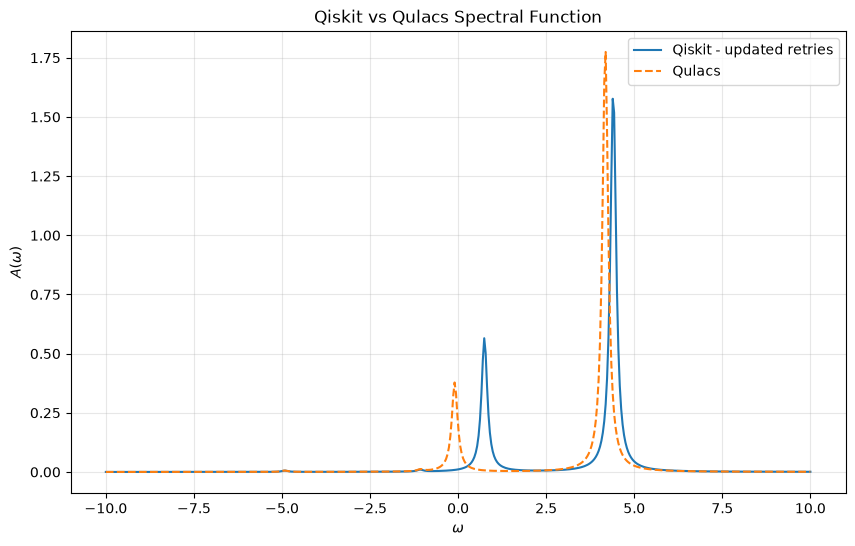

In [183]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    omega_real,
    spectral_qiskit_retry,
    label="Qiskit - updated retries"
)

plt.plot(
    omega_real,
    spectral_qulacs,
    "--",
    label="Qulacs"
)

plt.xlabel(r"$\omega$")
plt.ylabel(r"$A(\omega)$")
plt.title("Qiskit vs Qulacs Spectral Function")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [180]:
qiskit_retry_peaks = get_main_peaks(
    omega_real,
    spectral_qiskit_retry,
    n_peaks=2,
)

qulacs_peaks = get_main_peaks(
    omega_real,
    spectral_qulacs,
    n_peaks=2,
)

print("\nQISKIT UPDATED PEAKS")
for i, (omega_peak, height) in enumerate(
    qiskit_retry_peaks,
    start=1
):
    print(
        f"Peak {i}: "
        f"omega = {omega_peak:.8f}, "
        f"A(omega) = {height:.8f}"
    )

print("\nQULACS PEAKS")
for i, (omega_peak, height) in enumerate(
    qulacs_peaks,
    start=1
):
    print(
        f"Peak {i}: "
        f"omega = {omega_peak:.8f}, "
        f"A(omega) = {height:.8f}"
    )


QISKIT UPDATED PEAKS
Peak 1: omega = 0.74148297, A(omega) = 0.56504826
Peak 2: omega = 4.38877756, A(omega) = 1.57683308

QULACS PEAKS
Peak 1: omega = -0.10020040, A(omega) = 0.37806575
Peak 2: omega = 4.18837675, A(omega) = 1.77456956


In [181]:
# Qiskit controlled addition Green's function
g_plus_q_control = (
    qiskit_phi_plus_norm**2
    * qv.continued_fraction_qiskit(
        w,
        a_q_control,
        b_q_control,
    )
)

# Qulacs controlled addition Green's function
g_plus_l_control = (
    qulacs_phi_plus_norm**2
    * qv.continued_fraction_qiskit(
        w,
        a_l_control,
        b_l_control,
    )
)

# Use the same Qulacs removal branch for both,
# so only the addition branch is being compared.
A_q_control = (
    -(1.0 / np.pi)
    * np.imag(
        g_minus_qulacs
        + g_plus_q_control
    )
)

A_l_control = (
    -(1.0 / np.pi)
    * np.imag(
        g_minus_qulacs
        + g_plus_l_control
    )
)

print(
    "Max spectral difference =",
    np.max(
        np.abs(
            A_q_control
            - A_l_control
        )
    )
)

print(
    "Mean spectral difference =",
    np.mean(
        np.abs(
            A_q_control
            - A_l_control
        )
    )
)

Max spectral difference = 0.027184743208780112
Mean spectral difference = 0.0013419915259691253


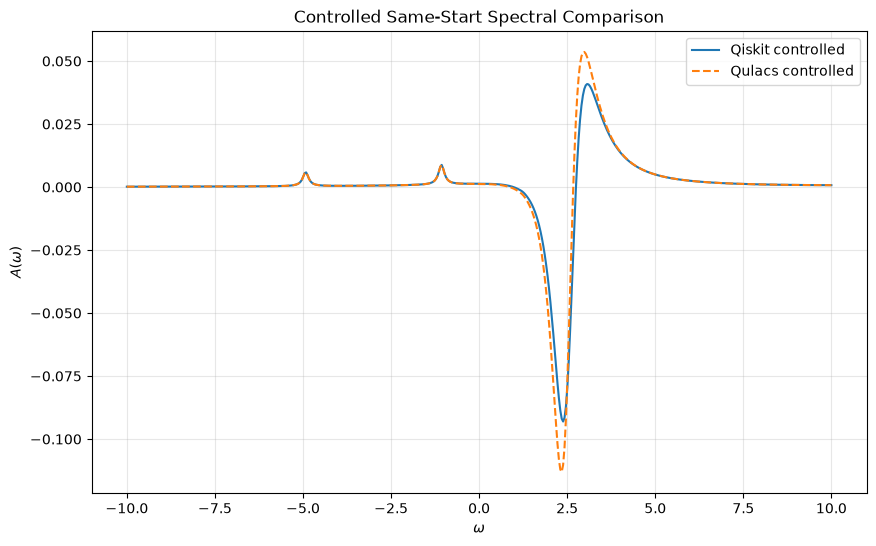

In [182]:
plt.figure(figsize=(10, 6))

plt.plot(
    omega_real,
    A_q_control,
    label="Qiskit controlled"
)

plt.plot(
    omega_real,
    A_l_control,
    "--",
    label="Qulacs controlled"
)

plt.xlabel(r"$\omega$")
plt.ylabel(r"$A(\omega)$")
plt.title("Controlled Same-Start Spectral Comparison")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [184]:
(
    a_q_minus_control,
    b_q_minus_control,
    results_q_minus_control,
    g_q_minus_raw_control,
    q_minus_states_control,
) = qv.vqe_gf_pm_qiskit(
    g_vqe=np.zeros_like(w, dtype=np.complex128),

    phi_norm=qiskit_phi_minus_norm,

    # Removal branch convention
    w=-w,

    niter=2,

    u=qiskit_phi_minus_array,

    Hmat=Hmat,
    H2mat=H2mat,

    charge_sec=charge_minus,
    spin_sec=spin_minus,

    n_layers=vqe_depth,

    up_qubit_indices=up_qubit_indices,
    down_qubit_indices=down_qubit_indices,

    connected_graphs=connected_graphs,

    conv_tol=1e-6,
    optimizer="COBYLA",
    maxiter=10000,
    gf_gtol=5e-5,

    initial_thetas=shared_initial_thetas,
)

# Removal Green's-function convention
g_q_minus_control = -g_q_minus_raw_control

System built: 6 qubits
VQE ground states constructed for both backends.
Krylov zero states (phi-, phi+) built for both backends.
Qulacs Green's function done.
  removal a: [ 1.11238324  3.63408533 -0.00501437]
  removal b: [0.         0.79446407 2.36977744]
  addition a: [3.54837436 0.70928367 4.26640127]
  addition b: [0.         2.64940977 1.20692982]

Qiskit Green's function done.
  removal a: [1.11238324e+00 3.62688191e+00 2.26703197e-03]
  removal b: [0.         0.79446407 2.37531927]
  addition a: [3.54837436 0.70975104 4.29259071]
  addition b: [0.         2.64940977 1.2070651 ]


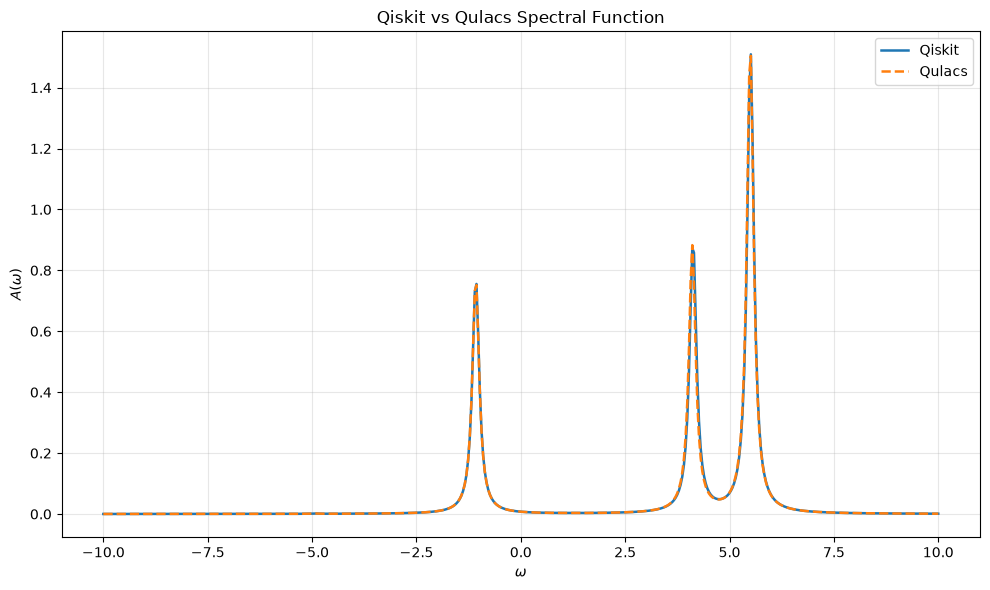


Saved plot to spectral_comparison.png

SPECTRAL FUNCTION DIFFERENCE (Qiskit vs Qulacs)
Max  |A_qiskit - A_qulacs| = 0.11315467810341773
Mean |A_qiskit - A_qulacs| = 0.002671091229591446

QISKIT PEAKS (3 found)
Peak 1: omega = -1.06212425, A(omega) = 0.75531776
Peak 2: omega = 4.10821643, A(omega) = 0.87316592
Peak 3: omega = 5.51102204, A(omega) = 1.50929714

QULACS PEAKS (3 found)
Peak 1: omega = -1.06212425, A(omega) = 0.75166409
Peak 2: omega = 4.10821643, A(omega) = 0.88280065
Peak 3: omega = 5.51102204, A(omega) = 1.50425274

MATCHED PEAK POSITION DIFFERENCES (nearest-omega pairing)
Qiskit omega=-1.062124  <->  Qulacs omega=-1.062124   Delta omega = 0.00000000
Qiskit omega=4.108216  <->  Qulacs omega=4.108216   Delta omega = 0.00000000
Qiskit omega=5.511022  <->  Qulacs omega=5.511022   Delta omega = 0.00000000


In [261]:
"""
Qiskit vs Qulacs spectral function comparison
==============================================

This consolidates the working pieces of your notebook into one clean,
linear script. It fixes one real bug that was in the notebook: the
particle-REMOVAL branch needs the SAME sign convention in both backends.

    Removal branch:  pass  w = -w  into the Lanczos/GF routine,
                      then negate the returned G before combining it
                      with the addition branch.

In the notebook this was done correctly for Qulacs (cell ~55:
`w=-w` then `g_minus_qulacs = -g_minus_raw_qulacs`) but the Qiskit
call in cell ~50 used plain `w` (no minus sign) for the same branch.
That mismatch alone is enough to shift peak positions between the two
curves, independent of any optimizer/local-minima effects.

Everything below assumes `vqe.py`, `qiskit_port/qiskit_vqe.py`,
`dmft.py`, and `anderson_impurity_model.py` are importable exactly as
they were in your notebook -- I did not modify those modules, only
the calling code.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

from qulacs import QuantumState
import dmft
import vqe
import qiskit_port.qiskit_vqe as qv
import anderson_impurity_model as aim
from qiskit.quantum_info import Statevector


# ============================================================
# 0. Config
# ============================================================

SYSTEM_SIZE = 3
SEED = 0
VQE_GS_ENERGY = -1.0
VQE_DEPTH = 1
NITER = 2                 # number of variational Lanczos iterations per branch
OPTIMIZER = "COBYLA"
MAXITER = 50000
CONV_TOL = 1e-5
GF_GTOL = 5e-5

ETA = 0.1                 # broadening
W_MIN, W_MAX, N_W = -10.0, 10.0, 500

# Fix this once, up front, so both backends' random initial thetas are
# drawn from the same global RNG state in the same order. This does NOT
# force identical optimizer starts across backends (each backend still
# draws its own np.random.uniform calls internally) -- it just makes the
# run reproducible. See the bottom of this script for the fully
# "controlled" same-theta0 version if you need that for the local-minima
# question specifically.
RANDOM_SEED = 1


# ============================================================
# 1. Build the AIM system once, shared by both backends
# ============================================================

(
    impurity_orbital,
    test_model,
    n_orbitals,
    up_qubit_indices,
    down_qubit_indices,
    connected_graphs,
    qubit_hamiltonian,
) = dmft.initialize_system(SYSTEM_SIZE, SEED)

# Qulacs Hamiltonian (H and H^2, shifted by VQE_GS_ENERGY)
qulacs_ham, qulacs_H2, n_qubits = vqe.create_qulacs_hamiltonian(
    qubit_hamiltonian, VQE_GS_ENERGY
)

# Qiskit / NumPy Hamiltonian matrices (same shift, same qubit count)
Hmat, H2mat, n_qubits_qiskit = qv.create_qiskit_hamiltonian_matrix(
    qubit_hamiltonian, VQE_GS_ENERGY
)
assert n_qubits == n_qubits_qiskit, "Qulacs/Qiskit qubit counts disagree"

print(f"System built: {n_qubits} qubits")


# ============================================================
# 2. Build the VQE ground state (same theta, both backends)
# ============================================================

n_up, n_down = 1, 1

initial_occupations_indices = vqe.get_initial_occupations_indices(
    up_qubit_indices, down_qubit_indices, n_up, n_down
)

n_edges = connected_graphs["graph_full"].number_of_edges()
n_params = VQE_DEPTH * (n_edges + n_qubits)

np.random.seed(RANDOM_SEED)
gs_theta = np.random.uniform(0.0, 2.0 * np.pi, size=n_params)

# Qulacs ground state
qulacs_gs, qulacs_gs_ordered = vqe.construct_vqe_gs(
    n_qubits=n_qubits,
    qulacs_ham=qulacs_ham,
    up_qubit_indices=up_qubit_indices,
    down_qubit_indices=down_qubit_indices,
    vqe_depth=VQE_DEPTH,
    connected_graphs=connected_graphs,
    minimum_angles=gs_theta,
    vqe_nu=n_up,
    vqe_nd=n_down,
)

# Qiskit ground state
qiskit_gs, qiskit_gs_array = qv.construct_vqe_gs_qiskit(
    n_qubits=n_qubits,
    up_qubit_indices=up_qubit_indices,
    down_qubit_indices=down_qubit_indices,
    vqe_depth=VQE_DEPTH,
    connected_graphs=connected_graphs,
    minimum_angles=gs_theta,
    vqe_nu=n_up,
    vqe_nd=n_down,
)

print("VQE ground states constructed for both backends.")


# ============================================================
# 3. Build the particle-removal / particle-addition Krylov
#    zero states phi- and phi+ (same for both backends)
# ============================================================

(
    qulacs_phi_minus, qulacs_phi_minus_ordered, qulacs_phi_minus_norm,
    qulacs_phi_plus, qulacs_phi_plus_ordered, qulacs_phi_plus_norm,
    qulacs_record,
) = vqe.vqe_krylov_zero_state(
    vqe_gs=qulacs_gs, impurity_orbital=impurity_orbital, n_qubits=n_qubits,
)

(
    qiskit_phi_minus, qiskit_phi_minus_array, qiskit_phi_minus_norm,
    qiskit_phi_plus, qiskit_phi_plus_array, qiskit_phi_plus_norm,
    qiskit_record,
) = qv.vqe_krylov_zero_state_qiskit(
    vqe_gs=qiskit_gs, impurity_orbital=impurity_orbital, n_qubits=n_qubits,
)

print("Krylov zero states (phi-, phi+) built for both backends.")


# ============================================================
# 4. Frequency grid (shared)
# ============================================================

w = np.linspace(W_MIN, W_MAX, N_W, dtype=np.complex128) + 1j * ETA
omega_real = w.real


# ============================================================
# 5. Symmetry sectors for removal / addition
#    (edit these if your system uses different charge/spin labels)
# ============================================================

charge_minus, spin_minus = 1, -1
charge_plus, spin_plus = 3, 1


# ============================================================
# 6. Qulacs: particle-removal and particle-addition branches
# ============================================================

removal_kwargs_qulacs = dict(
    niter=NITER, u=qulacs_phi_minus, h=qulacs_ham, h2=qulacs_H2,
    charge_sec=charge_minus, spin_sec=spin_minus, n_layers=VQE_DEPTH,
    up_qubit_indices=up_qubit_indices, down_qubit_indices=down_qubit_indices,
    connected_graphs=connected_graphs, conv_tol=CONV_TOL,
    optimizer=OPTIMIZER, maxiter=MAXITER, gf_gtol=GF_GTOL,
)

np.random.seed(RANDOM_SEED)
a_minus_qulacs, b_minus_qulacs, minus_results_qulacs, g_minus_raw_qulacs = (
    vqe.vqe_gf_pm(
        g_vqe=np.zeros_like(w, dtype=np.complex128),
        phi_norm=qulacs_phi_minus_norm,
        w=-w,                       # <-- removal branch: negate w
        **removal_kwargs_qulacs,
    )
)
g_minus_qulacs = -g_minus_raw_qulacs   # <-- and negate the result

addition_kwargs_qulacs = dict(
    niter=NITER, u=qulacs_phi_plus, h=qulacs_ham, h2=qulacs_H2,
    charge_sec=charge_plus, spin_sec=spin_plus, n_layers=VQE_DEPTH,
    up_qubit_indices=up_qubit_indices, down_qubit_indices=down_qubit_indices,
    connected_graphs=connected_graphs, conv_tol=CONV_TOL,
    optimizer=OPTIMIZER, maxiter=MAXITER, gf_gtol=GF_GTOL,
)

np.random.seed(RANDOM_SEED)
a_plus_qulacs, b_plus_qulacs, plus_results_qulacs, g_plus_qulacs = (
    vqe.vqe_gf_pm(
        g_vqe=np.zeros_like(w, dtype=np.complex128),
        phi_norm=qulacs_phi_plus_norm,
        w=w,                         # <-- addition branch: plain w
        **addition_kwargs_qulacs,
    )
)

g_total_qulacs = g_minus_qulacs + g_plus_qulacs
spectral_qulacs = -(1.0 / np.pi) * np.imag(g_total_qulacs)

print("Qulacs Green's function done.")
print("  removal a:", np.real_if_close(a_minus_qulacs))
print("  removal b:", np.real_if_close(b_minus_qulacs))
print("  addition a:", np.real_if_close(a_plus_qulacs))
print("  addition b:", np.real_if_close(b_plus_qulacs))


# ============================================================
# 7. Qiskit: particle-removal and particle-addition branches
#    (same sign convention as Qulacs, above)
# ============================================================

removal_kwargs_qiskit = dict(
    niter=NITER, u=qiskit_phi_minus_array, Hmat=Hmat, H2mat=H2mat,
    charge_sec=charge_minus, spin_sec=spin_minus, n_layers=VQE_DEPTH,
    up_qubit_indices=up_qubit_indices, down_qubit_indices=down_qubit_indices,
    connected_graphs=connected_graphs, conv_tol=CONV_TOL,
    optimizer=OPTIMIZER, maxiter=MAXITER, gf_gtol=GF_GTOL,
)

np.random.seed(RANDOM_SEED)
(
    a_minus_qiskit, b_minus_qiskit, minus_results_qiskit,
    g_minus_raw_qiskit, minus_krylov_qiskit,
) = qv.vqe_gf_pm_qiskit(
    g_vqe=np.zeros_like(w, dtype=np.complex128),
    phi_norm=qiskit_phi_minus_norm,
    w=-w,                            # <-- FIX: was plain `w` in the notebook
    **removal_kwargs_qiskit,
)
g_minus_qiskit = -g_minus_raw_qiskit  # <-- and negate the result, same as Qulacs

addition_kwargs_qiskit = dict(
    niter=NITER, u=qiskit_phi_plus_array, Hmat=Hmat, H2mat=H2mat,
    charge_sec=charge_plus, spin_sec=spin_plus, n_layers=VQE_DEPTH,
    up_qubit_indices=up_qubit_indices, down_qubit_indices=down_qubit_indices,
    connected_graphs=connected_graphs, conv_tol=CONV_TOL,
    optimizer=OPTIMIZER, maxiter=MAXITER, gf_gtol=GF_GTOL,
)

np.random.seed(RANDOM_SEED)
(
    a_plus_qiskit, b_plus_qiskit, plus_results_qiskit,
    g_plus_qiskit, plus_krylov_qiskit,
) = qv.vqe_gf_pm_qiskit(
    g_vqe=np.zeros_like(w, dtype=np.complex128),
    phi_norm=qiskit_phi_plus_norm,
    w=w,
    **addition_kwargs_qiskit,
)

g_total_qiskit = g_minus_qiskit + g_plus_qiskit
spectral_qiskit = -(1.0 / np.pi) * np.imag(g_total_qiskit)

print("\nQiskit Green's function done.")
print("  removal a:", np.real_if_close(a_minus_qiskit))
print("  removal b:", np.real_if_close(b_minus_qiskit))
print("  addition a:", np.real_if_close(a_plus_qiskit))
print("  addition b:", np.real_if_close(b_plus_qiskit))


# ============================================================
# 8. Plot: Qiskit vs Qulacs spectral function
# ============================================================

plt.figure(figsize=(10, 6))
plt.plot(omega_real, spectral_qiskit, label="Qiskit", linewidth=1.8)
plt.plot(omega_real, spectral_qulacs, "--", label="Qulacs", linewidth=1.8)
plt.xlabel(r"$\omega$")
plt.ylabel(r"$A(\omega)$")
plt.title("Qiskit vs Qulacs Spectral Function")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("spectral_comparison.png", dpi=150)
plt.show()

print("\nSaved plot to spectral_comparison.png")


# ============================================================
# 9. Numerical comparison: overall difference + peak positions
# ============================================================

abs_diff = np.abs(spectral_qiskit - spectral_qulacs)
print("\n" + "=" * 60)
print("SPECTRAL FUNCTION DIFFERENCE (Qiskit vs Qulacs)")
print("=" * 60)
print("Max  |A_qiskit - A_qulacs| =", np.max(abs_diff))
print("Mean |A_qiskit - A_qulacs| =", np.mean(abs_diff))


def get_main_peaks(omega, spectral, n_peaks=None, prominence=None):
    """
    Find local maxima in `spectral` and return them sorted by omega.

    n_peaks : if given, keep only the `n_peaks` tallest peaks (old
              behavior). If None (default), return EVERY detected peak --
              use this when you don't know in advance how many peaks the
              spectrum has.
    prominence : optional scipy `find_peaks` prominence threshold, useful
                 for filtering out tiny numerical-noise "peaks" without
                 hardcoding a peak count.
    """
    peak_indices, _ = find_peaks(spectral, prominence=prominence)
    if len(peak_indices) == 0:
        return []

    if n_peaks is not None:
        peak_indices = peak_indices[np.argsort(spectral[peak_indices])[-n_peaks:]]

    peak_indices = peak_indices[np.argsort(omega[peak_indices])]
    return [(float(omega[i]), float(spectral[i])) for i in peak_indices]


def match_peaks_by_position(peaks_a, peaks_b, max_delta=1.0):
    """
    Pair up peaks from two spectra by nearest omega, rather than assuming
    they line up by list index. Returns a list of (peak_a, peak_b, delta_omega)
    for matched pairs, plus lists of any peaks that had no match within
    max_delta.
    """
    remaining_b = list(peaks_b)
    matches = []
    unmatched_a = []

    for pa in peaks_a:
        if not remaining_b:
            unmatched_a.append(pa)
            continue
        # nearest peak in b by omega
        idx = min(range(len(remaining_b)), key=lambda i: abs(remaining_b[i][0] - pa[0]))
        pb = remaining_b[idx]
        delta = pa[0] - pb[0]
        if abs(delta) <= max_delta:
            matches.append((pa, pb, delta))
            remaining_b.pop(idx)
        else:
            unmatched_a.append(pa)

    return matches, unmatched_a, remaining_b


# Report ALL peaks found in each spectrum -- no hardcoded count.
qiskit_peaks = get_main_peaks(omega_real, spectral_qiskit, n_peaks=None, prominence=1e-3)
qulacs_peaks = get_main_peaks(omega_real, spectral_qulacs, n_peaks=None, prominence=1e-3)

print("\n" + "=" * 60)
print(f"QISKIT PEAKS ({len(qiskit_peaks)} found)")
print("=" * 60)
for i, (om, height) in enumerate(qiskit_peaks, start=1):
    print(f"Peak {i}: omega = {om:.8f}, A(omega) = {height:.8f}")

print("\n" + "=" * 60)
print(f"QULACS PEAKS ({len(qulacs_peaks)} found)")
print("=" * 60)
for i, (om, height) in enumerate(qulacs_peaks, start=1):
    print(f"Peak {i}: omega = {om:.8f}, A(omega) = {height:.8f}")

print("\n" + "=" * 60)
print("MATCHED PEAK POSITION DIFFERENCES (nearest-omega pairing)")
print("=" * 60)
matches, unmatched_qiskit, unmatched_qulacs = match_peaks_by_position(
    qiskit_peaks, qulacs_peaks, max_delta=1.0
)
for pa, pb, delta in matches:
    print(f"Qiskit omega={pa[0]:.6f}  <->  Qulacs omega={pb[0]:.6f}   Delta omega = {delta:.8f}")

if unmatched_qiskit:
    print(f"\n{len(unmatched_qiskit)} Qiskit peak(s) had NO match within 1.0 in omega:")
    for om, height in unmatched_qiskit:
        print(f"  omega = {om:.6f}, A(omega) = {height:.6f}")

if unmatched_qulacs:
    print(f"\n{len(unmatched_qulacs)} Qulacs peak(s) had NO match within 1.0 in omega:")
    for om, height in unmatched_qulacs:
        print(f"  omega = {om:.6f}, A(omega) = {height:.6f}")

In [237]:
print("\n" + "=" * 70)
print("8-QUBIT COEFFICIENT DIAGNOSTIC")
print("=" * 70)

print("\nREMOVAL")
print("Qulacs a:", a_minus_qulacs)
print("Qiskit a:", a_minus_qiskit)
print("Delta a :", np.abs(a_minus_qiskit - a_minus_qulacs))

print("Qulacs b:", b_minus_qulacs)
print("Qiskit b:", b_minus_qiskit)
print("Delta b :", np.abs(b_minus_qiskit - b_minus_qulacs))

print("\nADDITION")
print("Qulacs a:", a_plus_qulacs)
print("Qiskit a:", a_plus_qiskit)
print("Delta a :", np.abs(a_plus_qiskit - a_plus_qulacs))

print("Qulacs b:", b_plus_qulacs)
print("Qiskit b:", b_plus_qiskit)
print("Delta b :", np.abs(b_plus_qiskit - b_plus_qulacs))

print("\nSpectral ranges:")
print(
    "Qiskit:",
    np.min(spectral_qiskit),
    np.max(spectral_qiskit),
)
print(
    "Qulacs:",
    np.min(spectral_qulacs),
    np.max(spectral_qulacs),
)


8-QUBIT COEFFICIENT DIAGNOSTIC

REMOVAL
Qulacs a: [0.28162036+0.j 3.25382974+0.j 3.17567933+0.j]
Qiskit a: [0.28162036-5.55111512e-17j 3.25114261+1.04083409e-16j
 3.17958771-9.10729825e-17j]
Delta a : [7.79136136e-16 2.68713557e-03 3.90838354e-03]
Qulacs b: [0.        +0.j 1.76708363+0.j 2.67825626+0.j]
Qiskit b: [0.        +0.00000000e+00j 1.76708363+2.06270667e-17j
 2.67834394+7.24886527e-17j]
Delta b : [0.00000000e+00 1.99850790e-15 8.76847825e-05]

ADDITION
Qulacs a: [ 4.16508367+0.j 12.18781731+0.j  3.67646084+0.j]
Qiskit a: [ 4.16508367-5.20417043e-17j 12.18775675+8.67361738e-17j
  2.00825711+7.19910243e-17j]
Delta a : [8.89701773e-16 6.05592233e-05 1.66820373e+00]
Qulacs b: [0.        +0.j         5.91310454+0.j         0.        +1.72529208j]
Qiskit b: [0.00000000e+00+0.00000000e+00j 5.91310454e+00-7.83435413e-17j
 6.49948935e-16-1.72509210e+00j]
Delta b : [0.00000000e+00 1.77808361e-15 3.45038418e+00]

Spectral ranges:
Qiskit: -0.10524676791143854 0.04555978471346201
Qulacs: 

In [269]:
import os
for d in ["tutorial/checkpoint", "tutorial/results", "."]:
    if os.path.exists(d):
        for f in os.listdir(d):
            if f.endswith((".json", ".pkl")):
                print(os.path.join(d, f))

tutorial/results/sites=3_seed=0_vqe_depth=1_gtol=5e-05.pkl
tutorial/results/sites=2_seed=0_vqe_depth=1_gtol=5e-05.pkl
./vqe_results.json
./vqe_8q_results.pkl


In [270]:
import os
stale_files = [
    "vqe_checkpoint.json", "vqe_results.json",
    # add whatever the listing above actually showed
]
for f in stale_files:
    if os.path.exists(f):
        os.remove(f)
        print(f"Deleted: {f}")
    else:
        print(f"Not found (ok): {f}")

Not found (ok): vqe_checkpoint.json
Deleted: vqe_results.json


In [271]:
import os
remaining_stale = [
    "tutorial/results/sites=3_seed=0_vqe_depth=1_gtol=5e-05.pkl",
    "tutorial/results/sites=2_seed=0_vqe_depth=1_gtol=5e-05.pkl",
    "vqe_8q_results.pkl",
]
for f in remaining_stale:
    if os.path.exists(f):
        os.remove(f)
        print(f"Deleted: {f}")
    else:
        print(f"Not found (ok): {f}")

Deleted: tutorial/results/sites=3_seed=0_vqe_depth=1_gtol=5e-05.pkl
Deleted: tutorial/results/sites=2_seed=0_vqe_depth=1_gtol=5e-05.pkl
Deleted: vqe_8q_results.pkl


In [273]:
CHECKPOINT_FILE = "vqe_checkpoint_v2.json"
RESULTS_FILE = "vqe_results_v2.json"

In [287]:
import importlib
import qiskit_port.qiskit_vqe as qv

importlib.reload(qv)

<module 'qiskit_port.qiskit_vqe' from '/Users/aporter2/Downloads/nlr_qc/qcaob-aim/qiskit_port/qiskit_vqe.py'>

In [291]:
import qiskit_port.qiskit_vqe as qv

print([name for name in dir(qv) if "vqe" in name.lower()])

['calculate_gf_vqe_qiskit', 'construct_vqe_gs_qiskit', 'solve_vqe_qiskit', 'vqe_gf_pm_qiskit', 'vqe_ideal_lanczos_iterations_qiskit', 'vqe_krylov_zero_state_qiskit']


In [292]:
(
    vqe_energy,
    vqe_charge,
    vqe_spin,
    minimum_angles,
    record,
) = qv.solve_vqe_qiskit(
    test_model=test_model,
    vqe_depth=1,
    optimizer="COBYLA",
    gs_gtol=5e-5,
    display=True,
)

[TRACE #7] create_connected_graphs() called from inside anderson_impurity_model.py: graph_up nodes=[0, 1, 2] (len=3), graph_down nodes=[3, 4, 5] (len=3), n_edges=7, implied n_params (n_layers=1) = 13
[TRACE #8] create_connected_graphs() called from inside anderson_impurity_model.py: graph_up nodes=[0, 1, 2] (len=3), graph_down nodes=[3, 4, 5] (len=3), n_edges=7, implied n_params (n_layers=1) = 13
[TRACE #9] create_connected_graphs() called from inside anderson_impurity_model.py: graph_up nodes=[0, 1, 2] (len=3), graph_down nodes=[3, 4, 5] (len=3), n_edges=7, implied n_params (n_layers=1) = 13
Sector: n_electrons=0, z_spin=0, init_occ=[]
  -> energy = -0.000000, success = True
Sector: n_electrons=1, z_spin=-1, init_occ=[3]
  -> energy = -2.230600, success = True
Sector: n_electrons=2, z_spin=-2, init_occ=[3, 5]
  -> energy = -2.192767, success = True
Sector: n_electrons=2, z_spin=0, init_occ=[0, 3]
  -> energy = -4.181966, success = False
Sector: n_electrons=3, z_spin=-3, init_occ=[3, 4

In [293]:
print("Energy:", vqe_energy)
print("Charge:", vqe_charge)
print("Spin:", vqe_spin)
print("Number of parameters:", len(minimum_angles))
print("Optimization success:", record.get("minimum_success"))

Energy: -4.181965558284002
Charge: 2
Spin: 0
Number of parameters: 13
Optimization success: None


In [294]:
vqe_state, vqe_state_array = qv.construct_vqe_gs_qiskit(
    n_qubits,
    up_qubit_indices,
    down_qubit_indices,
    vqe_depth,
    connected_graphs,
    minimum_angles,
    record["vqe_nu"],
    record["vqe_nd"],
)

In [299]:
import importlib

import qiskit_port.qiskit_vqe as qv
import qiskit_port.dmft_qiskit as dmft_q

importlib.reload(qv)
importlib.reload(dmft_q)

<module 'qiskit_port.dmft_qiskit' from '/Users/aporter2/Downloads/nlr_qc/qcaob-aim/qiskit_port/dmft_qiskit.py'>

In [301]:
(
    impurity_orbital,
    test_model,
    n_orbitals,
    up_qubit_indices,
    down_qubit_indices,
    connected_graphs,
    qubit_hamiltonian,
) = dmft_q.initialize_system(
    system_size=4,
    seed=0,
)

[TRACE #11] create_connected_graphs() called from inside anderson_impurity_model.py: graph_up nodes=[0, 1, 2, 3] (len=4), graph_down nodes=[4, 5, 6, 7] (len=4), n_edges=9, implied n_params (n_layers=1) = 17
[TRACE #12] create_connected_graphs() called from inside anderson_impurity_model.py: graph_up nodes=[0, 1, 2, 3] (len=4), graph_down nodes=[4, 5, 6, 7] (len=4), n_edges=9, implied n_params (n_layers=1) = 17


In [302]:
record_gs, exact_gs, minimum_angles = dmft_q.calculate_gs(
    impurity_orbital=impurity_orbital,
    test_model=test_model,
    up_qubit_indices=up_qubit_indices,
    down_qubit_indices=down_qubit_indices,
    connected_graphs=connected_graphs,
    qubit_hamiltonian=qubit_hamiltonian,
    vqe_depth=1,
    gs_gtol=5e-4,
    optimizer="BFGS",
    gtol=5e-4,
    maxiters=50000,
    conv_tol=1e-6,
    display=True,
    gs=True,
)

[TRACE #13] create_connected_graphs() called from inside anderson_impurity_model.py: graph_up nodes=[0, 1, 2, 3] (len=4), graph_down nodes=[4, 5, 6, 7] (len=4), n_edges=9, implied n_params (n_layers=1) = 17
NOTE: solve_vqe_qiskit() does not implement checkpoint/results file caching (see docstring) -- checkpoint_file/results_file are accepted but ignored. Running a full in-memory sector search.
[TRACE #14] create_connected_graphs() called from inside anderson_impurity_model.py: graph_up nodes=[0, 1, 2, 3] (len=4), graph_down nodes=[4, 5, 6, 7] (len=4), n_edges=9, implied n_params (n_layers=1) = 17
[TRACE #15] create_connected_graphs() called from inside anderson_impurity_model.py: graph_up nodes=[0, 1, 2, 3] (len=4), graph_down nodes=[4, 5, 6, 7] (len=4), n_edges=9, implied n_params (n_layers=1) = 17
[TRACE #16] create_connected_graphs() called from inside anderson_impurity_model.py: graph_up nodes=[0, 1, 2, 3] (len=4), graph_down nodes=[4, 5, 6, 7] (len=4), n_edges=9, implied n_params 

In [303]:
print("Exact energy:", record_gs["exact_gs_energy"])
print("Qiskit VQE energy:", record_gs["vqe_gs_energy"])
print("Energy relative error:", record_gs["gs_energy_rel_error"])

print("Exact charge:", record_gs["exact_charge"])
print("Qiskit charge:", record_gs["vqe_charge"])

print("Exact spin:", record_gs["exact_spin"])
print("Qiskit spin:", record_gs["vqe_spin"])

print("Ground-state overlap:", record_gs["gs_overlap"])
print("Optimizer success:", record_gs["local_vqe_success"])

Exact energy: -6.342494988276474
Qiskit VQE energy: -6.248526937205282
Energy relative error: 0.014815628746239989
Exact charge: 4.0
Qiskit charge: 4
Exact spin: 0.0
Qiskit spin: 0
Ground-state overlap: 0.9785471419396642
Optimizer success: True


In [309]:
(
    qulacs_energy,
    qulacs_state,
    _,
    qulacs_angles,
    qulacs_record,
) = vqe.solve_vqe_gs(
    test_model,
    qubit_hamiltonian,
    connected_graphs,
    up_qubit_indices,
    down_qubit_indices,
    display=True,
    optimizer="BFGS",
    gs_gtol=5e-4,
    gtol=5e-4,
    maxiters=50000,
    conv_tol=1e-6,
)

TypeError: solve_vqe_gs() missing 1 required positional argument: 'vqe_depth'

In [305]:
import inspect

print(inspect.signature(vqe.solve_vqe_gs))

(test_model: anderson_impurity_model.AndersonImpurityModel, qubit_hamiltonian: openfermion.ops.operators.qubit_operator.QubitOperator, connected_graphs: dict, up_qubit_indices: list[int], down_qubit_indices: list[int], vqe_depth: int, optimizer: str, gs_gtol: float, display: bool, **kwargs) -> tuple[float, numpy.ndarray[typing.Any, numpy.dtype[numpy.complex128]], qulacs_core.QuantumState, numpy.ndarray[typing.Any, numpy.dtype[+_ScalarType_co]], dict]


In [312]:
import os

os.makedirs("comparison_results", exist_ok=True)

checkpoint_file = "comparison_results/qulacs_checkpoint.pkl"
results_file = "comparison_results/qulacs_results.pkl"

In [315]:
(
    qulacs_energy,
    qulacs_state_array,
    qulacs_state,
    qulacs_angles,
    qulacs_record,
) = vqe.solve_vqe_gs(
    test_model=test_model,
    qubit_hamiltonian=qubit_hamiltonian,
    connected_graphs=connected_graphs,
    up_qubit_indices=up_qubit_indices,
    down_qubit_indices=down_qubit_indices,
    vqe_depth=1,
    optimizer="BFGS",
    gs_gtol=5e-4,
    display=True,
    checkpoint_file=checkpoint_file,
    results_file=results_file,
)

[TRACE #31] create_connected_graphs() called from inside anderson_impurity_model.py: graph_up nodes=[0, 1, 2, 3] (len=4), graph_down nodes=[4, 5, 6, 7] (len=4), n_edges=9, implied n_params (n_layers=1) = 17
[TRACE #32] create_connected_graphs() called from inside anderson_impurity_model.py: graph_up nodes=[0, 1, 2, 3] (len=4), graph_down nodes=[4, 5, 6, 7] (len=4), n_edges=9, implied n_params (n_layers=1) = 17
[TRACE #33] create_connected_graphs() called from inside anderson_impurity_model.py: graph_up nodes=[0, 1, 2, 3] (len=4), graph_down nodes=[4, 5, 6, 7] (len=4), n_edges=9, implied n_params (n_layers=1) = 17
[]
No previous checkpoint data loaded, starting complete spin, charge sector search from start.
Particle_number: 0
	 Z-spin eigenvalue: 0
	 Init. Occ. Inds: []
[TRACE #34] create_connected_graphs() called from inside anderson_impurity_model.py: graph_up nodes=[0, 1, 2, 3] (len=4), graph_down nodes=[4, 5, 6, 7] (len=4), n_edges=9, implied n_params (n_layers=1) = 17
	 Local VQE 

In [313]:
(
    qiskit_energy,
    qiskit_charge,
    qiskit_spin,
    qiskit_angles,
    qiskit_record,
) = qv.solve_vqe_qiskit(
    test_model=test_model,
    vqe_depth=1,
    optimizer="BFGS",
    gs_gtol=5e-4,
    checkpoint_file="",
    results_file="",
    display=True,
)

NOTE: solve_vqe_qiskit() does not implement checkpoint/results file caching (see docstring) -- checkpoint_file/results_file are accepted but ignored. Running a full in-memory sector search.
[TRACE #24] create_connected_graphs() called from inside anderson_impurity_model.py: graph_up nodes=[0, 1, 2, 3] (len=4), graph_down nodes=[4, 5, 6, 7] (len=4), n_edges=9, implied n_params (n_layers=1) = 17
[TRACE #25] create_connected_graphs() called from inside anderson_impurity_model.py: graph_up nodes=[0, 1, 2, 3] (len=4), graph_down nodes=[4, 5, 6, 7] (len=4), n_edges=9, implied n_params (n_layers=1) = 17
[TRACE #26] create_connected_graphs() called from inside anderson_impurity_model.py: graph_up nodes=[0, 1, 2, 3] (len=4), graph_down nodes=[4, 5, 6, 7] (len=4), n_edges=9, implied n_params (n_layers=1) = 17
Sector: n_electrons=0, z_spin=0, init_occ=[]
  -> energy = -0.000000, success = True
Sector: n_electrons=1, z_spin=-1, init_occ=[4]
  -> energy = -1.971536, success = True
Sector: n_electro

In [316]:
print(f"Qulacs energy : {qulacs_energy:.12f}")
print(f"Qiskit energy : {qiskit_energy:.12f}")
print(f"Difference    : {abs(qulacs_energy - qiskit_energy):.3e}")

Qulacs energy : -6.248839053634
Qiskit energy : -6.248866751732
Difference    : 2.770e-05


In [319]:
print("Qulacs charge:", qulacs_record["vqe_charge"])
print("Qiskit charge:", qiskit_charge)

Qulacs charge: 4
Qiskit charge: 4


In [320]:
print("Qulacs spin:", qulacs_record["vqe_spin"])
print("Qiskit spin:", qiskit_spin)

Qulacs spin: 0
Qiskit spin: 0


In [321]:
print("Qulacs params:", len(qulacs_angles))
print("Qiskit params:", len(qiskit_angles))

Qulacs params: 17
Qiskit params: 17
